In [1]:
import os
import time
import pickle
import random
import numpy as np
import pandas as pd 
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.metrics import MeanIoU, Precision, Recall, AUC

from tqdm import tqdm
from keras import backend
from skimage import measure
from tqdm.notebook import tqdm
from matplotlib.lines import Line2D
from keras_unet_collection import losses
from keras_unet_collection import models
from keras_unet_collection.layer_utils import *
from keras_unet_collection._model_unet_2d import UNET_left, UNET_right
from keras_unet_collection.transformer_layers import patch_extract, patch_embedding

# Prepare Dataset

Multiclass batch shapes:
  X: (8, 128, 128, 3)  Y: (8, 128, 128, 3)


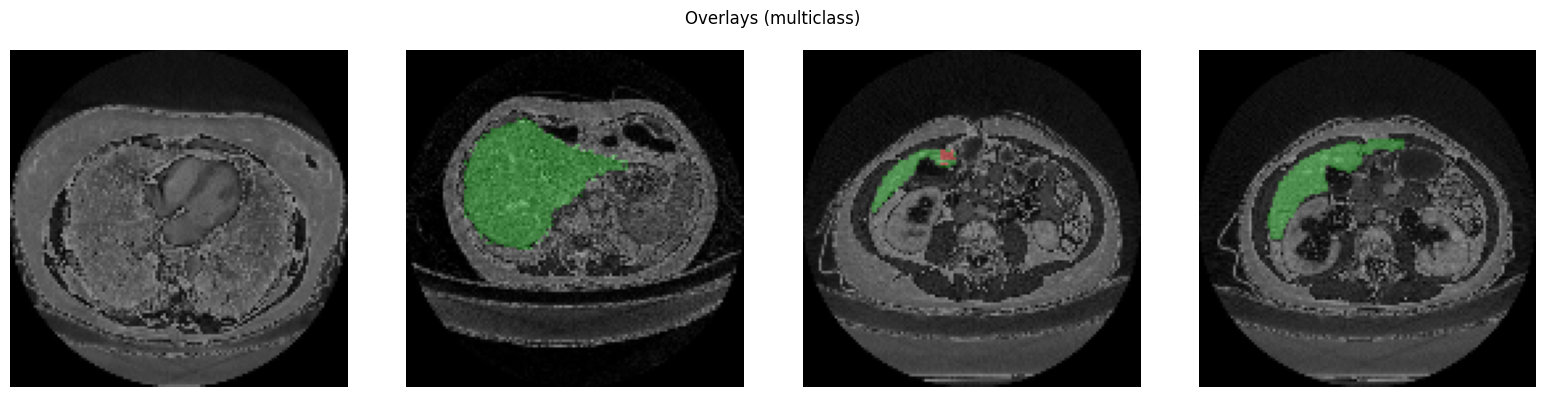

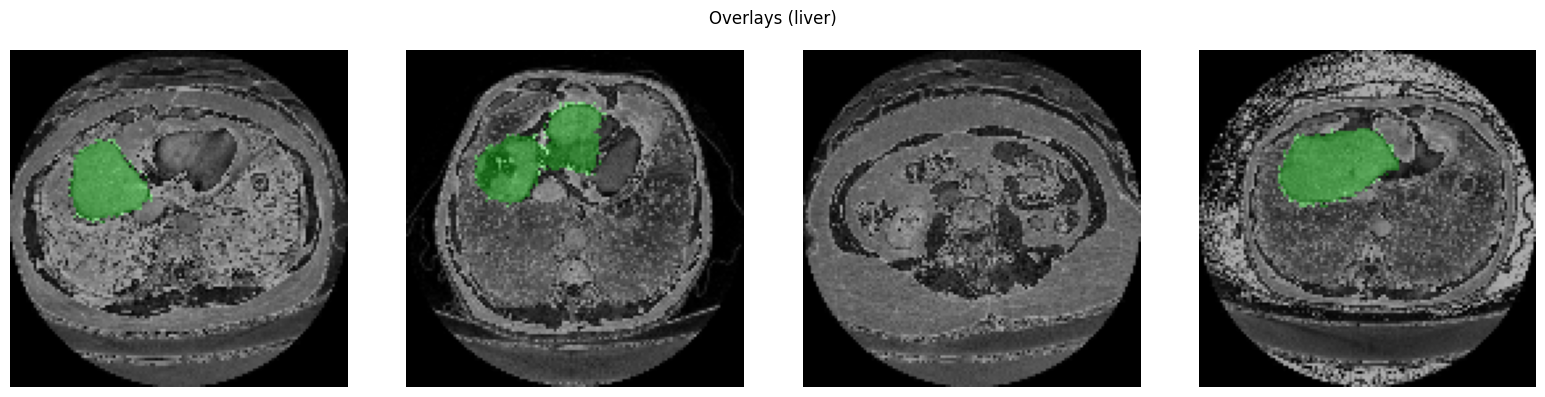

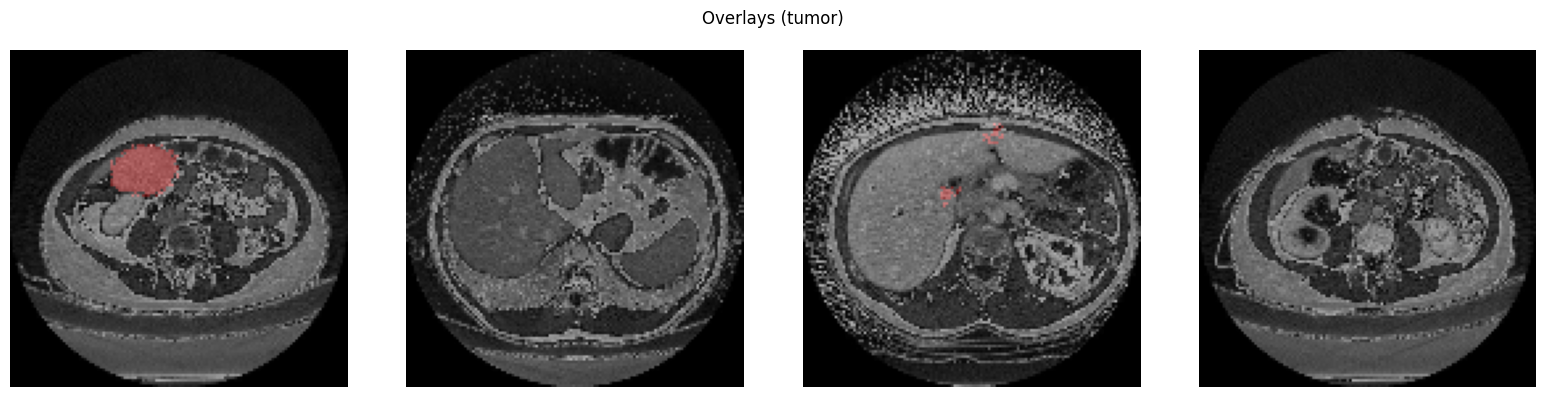

In [2]:
# =========================
# TF pipeline + SAFE plots
# =========================
import os
from pathlib import Path
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Configuration
# -------------------------
DATASET_ROOT = Path("prepared_liver_dataset")   # <- change if needed
IMAGE_SIZE   = (128, 128)                         # resize target (H, W)
BATCH_SIZE   = 8
IMAGE_CHANNELS = 1                                 # 1 for CT/MRI; set 3 if RGB
AUTO = tf.data.AUTOTUNE
MODEL_INPUT_CHANNELS = 3  # your model expects 3 channels per the error

# Augmentations
AUG_FLIP   = False
AUG_ROTATE = False
AUG_BC     = False   # brightness/contrast

# -------------------------
# I/O helpers
# -------------------------
def _decode_image(path, channels=1):
    b = tf.io.read_file(path)
    img = tf.image.decode_png(b, channels=channels)  # uint8 in [0,255]
    img = tf.cast(img, tf.float32) / 255.0           # x/255.0

    # Adapt to model’s expected channels without changing masks
    if MODEL_INPUT_CHANNELS == 3 and channels == 1:
        img = tf.repeat(img, repeats=3, axis=-1)     # (H,W,1) -> (H,W,3)
    elif MODEL_INPUT_CHANNELS == 1 and channels == 3:
        img = tf.image.rgb_to_grayscale(img)         # (H,W,3) -> (H,W,1)
    # else: already aligned
    return img


def _decode_mask(path):
    """Decode PNG mask; keep integer values until post-processing."""
    b = tf.io.read_file(path)
    m = tf.image.decode_png(b, channels=1)  # uint8
    return m

def _swap_dir(img_path, src_dir, dst_dir):
    """
    Replace .../(src_dir)/... with .../(dst_dir)/... handling both / and \\
    Works inside tf graph.
    """
    pattern = r"([\\/])" + src_dir + r"([\\/])"
    repl    = r"\1" + dst_dir + r"\2"
    return tf.strings.regex_replace(img_path, pattern, repl)

def _resize_image_mask(img, mask, image_size):
    img  = tf.image.resize(img, image_size, method=tf.image.ResizeMethod.BILINEAR)
    mask = tf.image.resize(mask, image_size, method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    return img, mask

# -------------------------
# Augmentations
# -------------------------
def _augment(img, mask):
    if AUG_FLIP:
        if tf.random.uniform(()) < 0.5:
            img  = tf.image.flip_left_right(img)
            mask = tf.image.flip_left_right(mask)
        if tf.random.uniform(()) < 0.5:
            img  = tf.image.flip_up_down(img)
            mask = tf.image.flip_up_down(mask)
    if AUG_ROTATE:
        k = tf.random.uniform((), 0, 4, dtype=tf.int32)  # 0,1,2,3
        img  = tf.image.rot90(img, k)
        mask = tf.image.rot90(mask, k)
    if AUG_BC:
        img = tf.image.random_brightness(img, max_delta=0.05)
        img = tf.image.random_contrast(img, 0.95, 1.05)
    return img, mask

# -------------------------
# File lists
# -------------------------
def _paths_list(split):
    img_dir = DATASET_ROOT / split / "images"
    files = sorted([str(p) for p in img_dir.glob("*.png")])
    if not files:
        raise FileNotFoundError(f"No images found in: {img_dir}")
    return files

# -------------------------
# Map functions per task
#   'liver'      -> binary mask (H,W,1) {0,1}
#   'tumor'      -> binary mask (H,W,1) {0,1}
#   'multiclass' -> one-hot (H,W,3) {0,1} for {bg,liver,tumor}
# -------------------------
def _map_sample(img_path, task):
    img = _decode_image(img_path, channels=IMAGE_CHANNELS)

    if task == "liver":
        mpath = _swap_dir(img_path, "images", "liver_masks")
        m = _decode_mask(mpath)
        m = tf.cast(m > 0, tf.float32)            # {0,1}
        m = tf.expand_dims(m[..., 0], -1)         # (H,W,1)

    elif task == "tumor":
        mpath = _swap_dir(img_path, "images", "tumor_masks")
        m = _decode_mask(mpath)
        m = tf.cast(m > 0, tf.float32)
        m = tf.expand_dims(m[..., 0], -1)

    elif task == "multiclass":
        mpath = _swap_dir(img_path, "images", "multi_class_masks")
        m = _decode_mask(mpath)                    # uint8 values in {0,1,2}
        m = tf.cast(m[..., 0], tf.int32)          # (H,W)
        m = tf.one_hot(m, depth=3, dtype=tf.float32)  # (H,W,3)
    else:
        raise ValueError("task must be 'liver', 'tumor', or 'multiclass'.")
    return img, m

def _maybe_drop_empty_tumor(img, mask, keep_bg_ratio=0.3):
    """Keep all positives; keep only a fraction of negatives (for tumor imbalance)."""
    has_tumor = tf.reduce_any(mask > 0.5)
    r = tf.random.uniform(())
    return tf.logical_or(has_tumor, r < keep_bg_ratio)

# -------------------------
# Public builder
# -------------------------
def build_dataset(split="train",
                  task="multiclass",
                  image_size=IMAGE_SIZE,
                  batch_size=BATCH_SIZE,
                  augment=True,
                  shuffle=True,
                  drop_empty_tumor=False,
                  keep_bg_ratio=0.3):
    files = _paths_list(split)
    n = len(files)

    ds = tf.data.Dataset.from_tensor_slices(files)
    if shuffle:
        ds = ds.shuffle(n, reshuffle_each_iteration=True)

    ds = ds.map(lambda p: _map_sample(p, task), num_parallel_calls=AUTO)
    ds = ds.map(lambda img, m: _resize_image_mask(img, m, image_size), num_parallel_calls=AUTO)

    if augment and split == "train":
        ds = ds.map(_augment, num_parallel_calls=AUTO)

    if task == "tumor" and drop_empty_tumor and split == "train":
        ds = ds.filter(lambda img, m: _maybe_drop_empty_tumor(img, m, keep_bg_ratio))

    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(AUTO)
    return ds, n

# =========================
# SAFE visualization (fix)
# =========================
def _to_rgb_single(x):
    """x: (H,W), (H,W,1) or (H,W,3) -> (H,W,3) in [0,1]."""
    x = np.asarray(x)
    if x.ndim == 2:
        x = np.stack([x, x, x], axis=-1)
    elif x.ndim == 3 and x.shape[-1] == 1:
        x = np.repeat(x, 3, axis=-1)
    return np.clip(x, 0.0, 1.0)

def _overlay_single(img, mask, task):
    img = _to_rgb_single(img)
    if task in ("liver", "tumor"):
        m = (mask[..., 0] > 0.5).astype(np.float32)
        color = np.array([1.0, 0.0, 0.0]) if task == "tumor" else np.array([0.0, 1.0, 0.0])
        out = img * 0.7 + color * m[..., None] * 0.3
        return np.clip(out, 0.0, 1.0)
    else:
        cls = np.argmax(mask, axis=-1).astype(np.int32)  # (H,W)
        liver = (cls == 1).astype(np.float32)
        tumor = (cls == 2).astype(np.float32)
        out = img * 0.6
        out += np.array([0.0, 1.0, 0.0]) * liver[..., None] * 0.25
        out += np.array([1.0, 0.0, 0.0]) * tumor[..., None] * 0.35
        return np.clip(out, 0.0, 1.0)

def _ensure_single_sample(imgs, masks, i):
    """
    Accepts imgs/masks with shapes:
      - (B,H,W,C) -> return imgs[i], masks[i]
      - (H,W,C)   -> return as-is
    Always returns one image/mask pair.
    """
    imgs  = np.asarray(imgs)
    masks = np.asarray(masks)
    if imgs.ndim >= 4:
        return imgs[i], masks[i]
    return imgs, masks

def show_batch(ds, task="multiclass", n=4):
    """Draw up to n overlays from the first batch—never passes a 4D array to imshow."""
    for imgs, masks in ds.take(1):
        imgs  = imgs.numpy()
        masks = masks.numpy()
        batch = imgs.shape[0] if imgs.ndim >= 4 else 1
        k = min(n, batch)

        plt.figure(figsize=(4*k, 4))
        for i in range(k):
            img_i, mask_i = _ensure_single_sample(imgs, masks, i)
            over = _overlay_single(img_i, mask_i, task)
            ax = plt.subplot(1, k, i+1)
            ax.imshow(over)
            ax.axis("off")
        plt.suptitle(f"Overlays ({task})")
        plt.tight_layout()
        plt.show()
        break

def show_one(ds, task="multiclass"):
    """Show exactly one overlay from the dataset."""
    for imgs, masks in ds.take(1):
        imgs  = imgs.numpy()
        masks = masks.numpy()
        img_i, mask_i = _ensure_single_sample(imgs, masks, 0)
        over = _overlay_single(img_i, mask_i, task)
        plt.figure(figsize=(4, 4))
        plt.imshow(over)
        plt.axis("off")
        plt.title(f"Overlay ({task})")
        plt.show()
        break

# =========================
# Example usage
# =========================
if __name__ == "__main__":
    # Multiclass (0 bg, 1 liver, 2 tumor)
    mc_train, _ = build_dataset("train", "multiclass", IMAGE_SIZE, BATCH_SIZE, augment=False)
    mc_test,  _ = build_dataset("test",  "multiclass", IMAGE_SIZE, BATCH_SIZE, augment=False, shuffle=False)
    print("Multiclass batch shapes:")
    for x, y in mc_train.take(1):
        print("  X:", x.shape, " Y:", y.shape)  # (B,H,W,C) and (B,H,W,3)
    show_batch(mc_train, task="multiclass", n=4)

    # Liver-only binary
    liver_train, _ = build_dataset("train", "liver", IMAGE_SIZE, BATCH_SIZE, augment=False)
    liver_test,  _ = build_dataset("test",  "liver", IMAGE_SIZE, BATCH_SIZE, augment=False, shuffle=False)
    show_batch(liver_train, task="liver", n=4)
    
    # Tumor-only binary (optionally drop empty backgrounds)
    tumor_train, _ = build_dataset("train", "tumor", IMAGE_SIZE, BATCH_SIZE,
                                   augment=False, drop_empty_tumor=False, keep_bg_ratio=0.4)
    tumor_test,  _ = build_dataset("test",  "tumor", IMAGE_SIZE, BATCH_SIZE, augment=False, shuffle=False)
    show_batch(tumor_train, task="tumor", n=4)

# Parameter Tuning

In [3]:
# Set image size and num classes
image_size = 128
num_classes= 1
model_version = 'FULL'
model_name = f"TraPH_experimental-UNet-{model_version}"

# Set Hyperparameters
learning_rate = 0.0001
optimizer = RMSprop(learning_rate=learning_rate)
loss = 'binary_crossentropy'
epochs = 25
batch_size = 32

# Evaluation Metrics

In [4]:
import tensorflow as tf

EPS = tf.keras.backend.epsilon()

# ------------- Helpers -------------
def _flatten_per_sample(x):
    x = tf.reshape(x, [tf.shape(x)[0], -1])   # (B, H*W[*(C=1)])
    return x

def _binarize(y, thr=0.5):
    return tf.cast(y > thr, tf.float32)

def _argmax_one_hot(y):
    cls = tf.argmax(y, axis=-1)              # (B,H,W)
    return tf.one_hot(cls, depth=tf.shape(y)[-1], dtype=tf.float32)  # (B,H,W,C)

def _select_class(y, c):
    # keep a channel dimension -> (B,H,W,1)
    return y[..., c:c+1]

def _mean_safe(x):
    return tf.reduce_mean(x)

# ------------- Binary metrics (sigmoid output, mask shape (B,H,W,1)) -------------
def dice_binary(y_true, y_pred, smooth=1.0, thr=0.5):
    y_t = _binarize(y_true, 0.5)
    y_p = _binarize(y_pred, thr)
    y_t = _flatten_per_sample(y_t)
    y_p = _flatten_per_sample(y_p)
    inter = tf.reduce_sum(y_t * y_p, axis=1)
    sums  = tf.reduce_sum(y_t, axis=1) + tf.reduce_sum(y_p, axis=1)
    dice  = (2.0 * inter + smooth) / (sums + smooth)
    return _mean_safe(dice)

def iou_binary(y_true, y_pred, smooth=1.0, thr=0.5):
    y_t = _binarize(y_true, 0.5)
    y_p = _binarize(y_pred, thr)
    y_t = _flatten_per_sample(y_t)
    y_p = _flatten_per_sample(y_p)
    inter = tf.reduce_sum(y_t * y_p, axis=1)
    union = tf.reduce_sum(y_t, axis=1) + tf.reduce_sum(y_p, axis=1) - inter
    iou   = (inter + smooth) / (union + smooth)
    return _mean_safe(iou)

def voe_binary(y_true, y_pred, smooth=1.0, thr=0.5):
    return 1.0 - iou_binary(y_true, y_pred, smooth, thr)

def precision_binary(y_true, y_pred, thr=0.5):
    y_t = _binarize(y_true, 0.5)
    y_p = _binarize(y_pred, thr)
    y_t = _flatten_per_sample(y_t)
    y_p = _flatten_per_sample(y_p)
    tp = tf.reduce_sum(y_t * y_p, axis=1)
    pp = tf.reduce_sum(y_p, axis=1)
    prec = (tp + EPS) / (pp + EPS)
    return _mean_safe(prec)

def recall_binary(y_true, y_pred, thr=0.5):
    y_t = _binarize(y_true, 0.5)
    y_p = _binarize(y_pred, thr)
    y_t = _flatten_per_sample(y_t)
    y_p = _flatten_per_sample(y_p)
    tp = tf.reduce_sum(y_t * y_p, axis=1)
    ap = tf.reduce_sum(y_t, axis=1)
    rec = (tp + EPS) / (ap + EPS)
    return _mean_safe(rec)

def specificity_binary(y_true, y_pred, thr=0.5):
    y_t = _binarize(y_true, 0.5)
    y_p = _binarize(y_pred, thr)
    y_t = _flatten_per_sample(y_t)
    y_p = _flatten_per_sample(y_p)
    tn = tf.reduce_sum((1.0 - y_t) * (1.0 - y_p), axis=1)
    fp = tf.reduce_sum((1.0 - y_t) * y_p, axis=1)
    spec = (tn + EPS) / (tn + fp + EPS)
    return _mean_safe(spec)

def f1_binary(y_true, y_pred, thr=0.5):
    p = precision_binary(y_true, y_pred, thr)
    r = recall_binary(y_true, y_pred, thr)
    return 2.0 * (p * r) / (p + r + EPS)

def ravd_binary(y_true, y_pred, thr=0.5):
    # |V_pred - V_true| / max(V_true, 1)  (uses true volume as denominator; if V_true=0, handles safely)
    y_t = _binarize(y_true, 0.5)
    y_p = _binarize(y_pred, thr)
    y_t = _flatten_per_sample(y_t)
    y_p = _flatten_per_sample(y_p)
    v_t = tf.reduce_sum(y_t, axis=1)
    v_p = tf.reduce_sum(y_p, axis=1)
    # If v_t==0, set denominator to 1 to avoid blow-up and report 0 if v_p==0 else 1
    denom = tf.where(v_t > 0.0, v_t, tf.ones_like(v_t))
    val = tf.abs(v_p - v_t) / (denom + EPS)
    # explicit override when both empty -> 0
    val = tf.where(tf.logical_and(v_t == 0.0, v_p == 0.0), tf.zeros_like(val), val)
    return _mean_safe(val)

# Tversky index (useful for imbalanced lesions)
def tversky_binary(y_true, y_pred, alpha=0.7, beta=0.3, thr=0.5, smooth=1.0):
    y_t = _binarize(y_true, 0.5)
    y_p = _binarize(y_pred, thr)
    y_t = _flatten_per_sample(y_t)
    y_p = _flatten_per_sample(y_p)
    tp = tf.reduce_sum(y_t * y_p, axis=1)
    fp = tf.reduce_sum((1.0 - y_t) * y_p, axis=1)
    fn = tf.reduce_sum(y_t * (1.0 - y_p), axis=1)
    tv = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    return _mean_safe(tv)

# ------------- Multiclass metrics (softmax output, one-hot mask (B,H,W,C), C=3 with bg=0,liver=1,tumor=2) -------------
def _per_class_binary_metric_from_multiclass(metric_fn_bin, class_index, thr=0.5):
    def fn(y_true, y_pred):
        # Convert to one-hot hard predictions then select class channel
        y_pred_hard = _argmax_one_hot(y_pred)
        y_t = _select_class(y_true, class_index)
        y_p = _select_class(y_pred_hard, class_index)
        # Reuse binary implementation
        return metric_fn_bin(y_t, y_p, thr=0.5)  # already hard one-hot
    return fn

def dice_macro_mc(y_true, y_pred, smooth=1.0):
    # hard predictions; average across fg classes (exclude background)
    y_pred_hard = _argmax_one_hot(y_pred)
    dices = []
    for c in [1, 2]:  # liver, tumor
        y_t = _select_class(y_true, c)
        y_p = _select_class(y_pred_hard, c)
        dices.append(dice_binary(y_t, y_p, smooth=smooth, thr=0.5))
    return tf.add_n(dices) / 2.0

def iou_macro_mc(y_true, y_pred, smooth=1.0):
    y_pred_hard = _argmax_one_hot(y_pred)
    ious = []
    for c in [1, 2]:
        y_t = _select_class(y_true, c)
        y_p = _select_class(y_pred_hard, c)
        ious.append(iou_binary(y_t, y_p, smooth=smooth, thr=0.5))
    return tf.add_n(ious) / 2.0

# Convenience per-class metrics for common reporting
dice_liver   = _per_class_binary_metric_from_multiclass(dice_binary, 1)
dice_tumor   = _per_class_binary_metric_from_multiclass(dice_binary, 2)
iou_liver    = _per_class_binary_metric_from_multiclass(iou_binary,  1)
iou_tumor    = _per_class_binary_metric_from_multiclass(iou_binary,  2)
ravd_liver   = _per_class_binary_metric_from_multiclass(ravd_binary, 1)
ravd_tumor   = _per_class_binary_metric_from_multiclass(ravd_binary, 2)
precision_liver = _per_class_binary_metric_from_multiclass(precision_binary, 1)
precision_tumor = _per_class_binary_metric_from_multiclass(precision_binary, 2)
recall_liver    = _per_class_binary_metric_from_multiclass(recall_binary,    1)
recall_tumor    = _per_class_binary_metric_from_multiclass(recall_binary,    2)
specificity_liver = _per_class_binary_metric_from_multiclass(specificity_binary, 1)
specificity_tumor = _per_class_binary_metric_from_multiclass(specificity_binary, 2)

# Model Builder

In [5]:
# ============================================================
# PRIMAL-UNeXt (TensorFlow / Keras) — paper-named + start/end tags
#
# Major component naming matches the paper:
#   Stem, E1–E4, VP, TOK, SCRoPE1/2, VA, B1, B2, BU, BC, D1–D3, H-*
#
# Start/End name tags for review:
#   - First layer of major components:   *_start
#   - Last layer of major components:    *_end
#   - Encoder/decoder stage boundary:    first DW7 gets *_start, last Add gets *_end
#
# Notes:
#   - Dropout removed (paper-safe / reproducibility-safe).
#   - Uses SwiGLU-style FFN in SCRoPE and LGM/bridge to match the original 1.19M-param reference.
#   - AASPP branches apply BN before adaptive mixing AND AdaLNIN inside each branch (matches manuscript text + Table 1).
#   - ResAdd scalar gate is initialized so the gate starts near zero (near-identity at init, per manuscript).
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras import layers as L
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    DepthwiseConv2D,
    Conv2DTranspose,
    GlobalAveragePooling2D,
    Dense,
    Add,
    Activation,
    BatchNormalization,
    LayerNormalization,
    MaxPooling2D,
    Concatenate,
)

# ---------------------------------------------------------------------
# Keras serialization helper
# ---------------------------------------------------------------------
def _register(name=None):
    def deco(cls):
        try:
            return tf.keras.utils.register_keras_serializable(
                package="primal_unext", name=name or cls.__name__
            )(cls)
        except Exception:
            return cls
    return deco


# ---------------------------------------------------------------------
# Small helper for consistent layer-name tags
# ---------------------------------------------------------------------
def _tag(base: str, suffix: str) -> str:
    return f"{base}_{suffix}"


# ---------------------------------------------------------------------
# SAGE components: GRN-S, AdaLNIN, ResAdd (LayerScale + GateScale)
# ---------------------------------------------------------------------
@_register()
class GRNS(L.Layer):
    """GRN-S: per-channel spatial standardization (zero-mean, unit-variance over H,W)."""
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = float(epsilon)

    def call(self, x):
        m, v = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        return (x - m) / tf.sqrt(v + self.epsilon)

    def get_config(self):
        return {"epsilon": self.epsilon, **super().get_config()}


@_register()
class AdaLNIN(L.Layer):
    """
    Adaptive LayerNorm–InstanceNorm blend (paper Eq. form).
    Gate mixes IN and LN, followed by shared affine.
    """
    def __init__(self, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = float(epsilon)

    def build(self, input_shape):
        C = int(input_shape[-1])

        # Shared affine
        self.gamma = self.add_weight(
            name="gamma", shape=(C,), initializer="ones", trainable=True
        )
        self.beta = self.add_weight(
            name="beta", shape=(C,), initializer="zeros", trainable=True
        )

        # Gate MLP: g = sigmoid(MLP(GAP(x)))
        hidden = max(8, C // 4)
        self.gap = GlobalAveragePooling2D(name=f"{self.name}_gap")
        self.g_fc1 = Dense(hidden, activation="relu", name=f"{self.name}_g_fc1")
        self.g_fc2 = Dense(C, activation="sigmoid", name=f"{self.name}_g_fc2")

        super().build(input_shape)

    def _in(self, x):
        m, v = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        return (x - m) / tf.sqrt(v + self.epsilon)

    def _ln(self, x):
        m, v = tf.nn.moments(x, axes=[-1], keepdims=True)
        return (x - m) / tf.sqrt(v + self.epsilon)

    def call(self, x):
        s = self.gap(x)                      # (B, C)
        g = self.g_fc2(self.g_fc1(s))        # (B, C)
        g = tf.reshape(g, (-1, 1, 1, tf.shape(x)[-1]))
        y = g * self._in(x) + (1.0 - g) * self._ln(x)
        return y * self.gamma + self.beta

    def get_config(self):
        return {"epsilon": self.epsilon, **super().get_config()}


@_register()
class LayerScale(L.Layer):
    def __init__(self, init_value=1e-4, **kwargs):
        super().__init__(**kwargs)
        self.init_value = float(init_value)

    def build(self, input_shape):
        C = int(input_shape[-1])
        self.gamma = self.add_weight(
            name="gamma",
            shape=(C,),
            initializer=tf.keras.initializers.Constant(self.init_value),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x):
        return x * self.gamma

    def get_config(self):
        return {"init_value": self.init_value, **super().get_config()}


@_register()
class GateScale(L.Layer):
    """Scalar residual gate g = sigmoid(logit / temperature)."""
    # Paper alignment: gate should start near zero (near-identity at init),
    # so default init_logit is set negative (sigmoid(-5) ≈ 0.0067).
    def __init__(self, init_logit=-5.0, temperature=1.0, l1=0.0, **kwargs):
        super().__init__(**kwargs)
        self.init_logit = float(init_logit)
        self.temperature = float(temperature)
        self.l1 = float(l1)

    def build(self, input_shape):
        self.logit = self.add_weight(
            name="logit",
            shape=(),
            initializer=tf.keras.initializers.Constant(self.init_logit),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x, training=None):
        g = tf.sigmoid(self.logit / self.temperature)
        if self.l1 > 0:
            self.add_loss(self.l1 * tf.abs(g))
        return x * g

    def get_config(self):
        return {
            "init_logit": self.init_logit,
            "temperature": self.temperature,
            "l1": self.l1,
            **super().get_config(),
        }


@_register()
class ResAdd(L.Layer):
    """
    ResAdd: base + GateScale(LayerScale(branch)).
    (Paper-style bounded residual injection.)
    """
    # Paper alignment: default gate_logit chosen so gate starts near zero.
    def __init__(self, ls_init=1e-4, gate_logit=-5.0, **kwargs):
        super().__init__(**kwargs)
        self.ls_init = float(ls_init)
        self.gate_logit = float(gate_logit)

    def build(self, input_shapes):
        self.ls = LayerScale(self.ls_init, name=f"{self.name}_ls")
        self.gate = GateScale(self.gate_logit, name=f"{self.name}_gate")
        self.add = Add(name=f"{self.name}_add")
        super().build(input_shapes)

    def call(self, inputs):
        base, branch = inputs
        branch = self.ls(branch)
        branch = self.gate(branch)
        return self.add([base, branch])

    def get_config(self):
        return {"ls_init": self.ls_init, "gate_logit": self.gate_logit, **super().get_config()}


# ---------------------------------------------------------------------
# AASPP (adaptive ASPP) — BN before mixing + AdaLNIN inside each branch (paper-aligned)
# ---------------------------------------------------------------------
def AASPP(x, num_filters, rate_scale=1, name="AASPP"):
    # Dilation set {1, 6, 12, 18}
    b1 = Conv2D(
        num_filters, 3, padding="same", use_bias=False, dilation_rate=1 * rate_scale,
        name=_tag(f"{name}_conv_d1", "start")
    )(x)
    b1 = BatchNormalization(name=f"{name}_bn_d1")(b1)
    b1 = AdaLNIN(name=f"{name}_adln_d1")(b1)

    b6 = Conv2D(
        num_filters, 3, padding="same", use_bias=False, dilation_rate=6 * rate_scale,
        name=f"{name}_conv_d6"
    )(x)
    b6 = BatchNormalization(name=f"{name}_bn_d6")(b6)
    b6 = AdaLNIN(name=f"{name}_adln_d6")(b6)

    b12 = Conv2D(
        num_filters, 3, padding="same", use_bias=False, dilation_rate=12 * rate_scale,
        name=f"{name}_conv_d12"
    )(x)
    b12 = BatchNormalization(name=f"{name}_bn_d12")(b12)
    b12 = AdaLNIN(name=f"{name}_adln_d12")(b12)

    b18 = Conv2D(
        num_filters, 3, padding="same", use_bias=False, dilation_rate=18 * rate_scale,
        name=f"{name}_conv_d18"
    )(x)
    b18 = BatchNormalization(name=f"{name}_bn_d18")(b18)
    b18 = AdaLNIN(name=f"{name}_adln_d18")(b18)

    # Adaptive convex mixing across the 4 branches
    y_stack = tf.stack([b1, b6, b12, b18], axis=-1)  # (B,H,W,C,4)
    s = tf.reduce_mean(y_stack, axis=[1, 2, 3])      # (B,4)

    g = Dense(max(4, num_filters // 8), activation="relu", name=f"{name}_mix_fc1")(s)
    w = Dense(4, activation="softmax", name=f"{name}_mix_fc2")(g)
    w = tf.reshape(w, (-1, 1, 1, 1, 4))
    y = tf.reduce_sum(y_stack * w, axis=-1)

    return Conv2D(
        num_filters, 1, padding="same", use_bias=False,
        name=_tag(f"{name}_proj", "end")
    )(y)


# ---------------------------------------------------------------------
# SCRoPE (Scaled-Conditioned RoPE) MHSA
# ---------------------------------------------------------------------
def _rotate_half(x):
    x1 = x[..., ::2]
    x2 = x[..., 1::2]
    return tf.concat([-x2, x1], axis=-1)

def _sincos_1d(L, D):
    half = D // 2
    i = tf.range(half, dtype=tf.float32)
    inv = 1.0 / (10000.0 ** (i / tf.cast(half, tf.float32)))
    pos = tf.cast(tf.range(L), tf.float32)[:, None] * inv[None, :]
    sin = tf.repeat(tf.sin(pos), repeats=2, axis=-1)
    cos = tf.repeat(tf.cos(pos), repeats=2, axis=-1)
    return sin, cos

@_register(name="SCRoPE_MHSA")
class SCRoPE_MHSA(L.Layer):
    """
    SCRoPE MHSA (map tokens):
      - RoPE-2D
      - QK-Norm
      - Talking-Heads (pre/post head mixing)
      - Learnable per-head logit scale (tau) and output head scale
    """
    def __init__(self, num_heads, key_dim, H=None, W=None, out_dim=None, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.h = int(num_heads)

        kd = int(key_dim)
        kd += (4 - kd % 4) % 4
        self.d = kd

        self.H = None if H in (None, 0) else int(H)
        self.W = None if W in (None, 0) else int(W)
        self.out_dim = out_dim
        self.eps = float(eps)

    def build(self, input_shape):
        C = int(input_shape[-1])
        Dall = self.h * self.d

        self.wq = Dense(Dall, use_bias=False, name=f"{self.name}_wq")
        self.wk = Dense(Dall, use_bias=False, name=f"{self.name}_wk")
        self.wv = Dense(Dall, use_bias=False, name=f"{self.name}_wv")
        self.wo = Dense(self.out_dim or C, use_bias=False, name=f"{self.name}_wo")

        self.gq = self.add_weight("gq", shape=(self.h,), initializer="ones", trainable=True)
        self.gk = self.add_weight("gk", shape=(self.h,), initializer="ones", trainable=True)

        eye = np.eye(self.h, dtype="float32")
        self.w_pre = self.add_weight(
            "w_pre", shape=(self.h, self.h),
            initializer=tf.keras.initializers.Constant(eye),
            trainable=True
        )
        self.w_post = self.add_weight(
            "w_post", shape=(self.h, self.h),
            initializer=tf.keras.initializers.Constant(eye),
            trainable=True
        )

        self.tau = self.add_weight(
            "tau", shape=(self.h,),
            initializer=tf.keras.initializers.Constant(1.0 / (self.d ** 0.5)),
            trainable=True
        )
        self.hscale = self.add_weight("hscale", shape=(self.h,), initializer="ones", trainable=True)

        super().build(input_shape)

    def _rope2d(self, q, k, H, W):
        B = tf.shape(q)[0]
        T = tf.shape(q)[2]

        q = tf.reshape(q, [B, self.h, H, W, self.d])
        k = tf.reshape(k, [B, self.h, H, W, self.d])

        dy = self.d // 2
        qy, qx = tf.split(q, [dy, self.d - dy], axis=-1)
        ky, kx = tf.split(k, [dy, self.d - dy], axis=-1)

        def _apply(x, L, along="y"):
            D = tf.shape(x)[-1]
            pad = tf.math.floormod(D, 2)

            x = tf.cond(
                tf.equal(pad, 1),
                lambda: tf.pad(x, [[0, 0], [0, 0], [0, 0], [0, 0], [0, 1]]),
                lambda: x
            )

            De = tf.shape(x)[-1]
            sin, cos = _sincos_1d(L, tf.cast(De, tf.int32))

            if along == "y":
                sin = tf.reshape(sin, [1, 1, L, 1, De])
                cos = tf.reshape(cos, [1, 1, L, 1, De])
            else:
                sin = tf.reshape(sin, [1, 1, 1, L, De])
                cos = tf.reshape(cos, [1, 1, 1, L, De])

            out = x * cos + _rotate_half(x) * sin
            return out[..., :D]

        qy = _apply(qy, H, "y")
        ky = _apply(ky, H, "y")
        qx = _apply(qx, W, "x")
        kx = _apply(kx, W, "x")

        q = tf.concat([qy, qx], axis=-1)
        k = tf.concat([ky, kx], axis=-1)

        q = tf.reshape(q, [B, self.h, T, self.d])
        k = tf.reshape(k, [B, self.h, T, self.d])
        return q, k

    def call(self, x):
        B = tf.shape(x)[0]
        T = tf.shape(x)[1]

        if (self.H is None) or (self.W is None):
            s = tf.cast(tf.sqrt(tf.cast(T, tf.float32)), tf.int32)
            H = s
            W = s
        else:
            H = tf.constant(self.H, tf.int32)
            W = tf.constant(self.W, tf.int32)

        q = self.wq(x)
        k = self.wk(x)
        v = self.wv(x)

        def _rs(t):
            t = tf.reshape(t, [B, -1, self.h, self.d])
            return tf.transpose(t, [0, 2, 1, 3])  # (B,h,T,d)

        q = _rs(q)
        k = _rs(k)
        v = _rs(v)

        q, k = self._rope2d(q, k, H, W)

        def _l2n(t, g):
            t = t / (tf.norm(t, axis=-1, keepdims=True) + self.eps)
            return t * tf.reshape(g, [1, self.h, 1, 1])

        q = _l2n(q, self.gq)
        k = _l2n(k, self.gk)

        logits = tf.einsum("bhid,bhjd->bhij", q, k) * tf.reshape(self.tau, [1, self.h, 1, 1])
        logits = tf.einsum("bhij,hH->bHij", logits, self.w_pre)

        a = tf.nn.softmax(logits, axis=-1)
        a = tf.einsum("bhij,hH->bHij", a, self.w_post)

        y = tf.einsum("bhij,bhjd->bhid", a, v) * tf.reshape(self.hscale, [1, self.h, 1, 1])
        y = tf.reshape(tf.transpose(y, [0, 2, 1, 3]), [B, T, self.h * self.d])
        return self.wo(y)

    def get_config(self):
        return {
            "num_heads": self.h,
            "key_dim": self.d,
            "H": self.H,
            "W": self.W,
            "out_dim": self.out_dim,
            "eps": self.eps,
            **super().get_config(),
        }


# ---------------------------------------------------------------------
# SwiGLU FFN (used in SCRoPE and inside LGM/mapFFN as in original reference)
# ---------------------------------------------------------------------
@_register()
class SwiGLU_FFN(L.Layer):
    def __init__(self, expansion=4.0, **kwargs):
        super().__init__(**kwargs)
        self.expansion = float(expansion)

    def build(self, input_shape):
        ch = int(input_shape[-1])
        hid = int(self.expansion * ch)
        self.fc1 = Dense(hid * 2, use_bias=False, name=f"{self.name}_fc1")
        self.fc2 = Dense(ch, use_bias=False, name=f"{self.name}_fc2")
        super().build(input_shape)

    def call(self, x):
        u, v = tf.split(self.fc1(x), 2, axis=-1)
        x = tf.nn.silu(u) * v
        return self.fc2(x)

    def get_config(self):
        return {"expansion": self.expansion, **super().get_config()}


# ---------------------------------------------------------------------
# LGM (Latent Global Memory) — Perceiver-style, original-reference FFN (SwiGLU)
# ---------------------------------------------------------------------
@_register(name="LGM")
class LGM(L.Layer):
    def __init__(self, num_memory=8, expand=4.0, num_heads=4, ffn_expand=2.0, use_tokens=True, **kwargs):
        super().__init__(**kwargs)
        self.num_memory = int(num_memory)
        self.expand = float(expand)
        self.num_heads = int(num_heads)
        self.ffn_expand = float(ffn_expand)
        self.use_tokens = bool(use_tokens)

    def build(self, input_shape):
        x_shape = input_shape[0] if isinstance(input_shape, (list, tuple)) else input_shape
        C_in = int(x_shape[-1])
        self.C_out = C_in
        self.D = max(8, int(self.expand * C_in))  # latent width

        # Token projection
        self.proj_in = Dense(self.D, use_bias=False, name=f"{self.name}_proj_in")

        # Norms
        self.norm_tok1 = LayerNormalization(name=f"{self.name}_nt1")
        self.norm_tok2 = LayerNormalization(name=f"{self.name}_nt2")
        self.norm_mem1 = LayerNormalization(name=f"{self.name}_nm1")
        self.norm_mem2 = LayerNormalization(name=f"{self.name}_nm2")
        self.ln_ff = LayerNormalization(name=f"{self.name}_ln_ff")

        # Memory slots
        self.mem = self.add_weight(
            name="mem_slots",
            shape=(self.num_memory, self.D),
            initializer="glorot_uniform",
            trainable=True,
        )

        # MHA projections
        key_dim = max(8, self.D // self.num_heads)
        self.q_proj = Dense(self.num_heads * key_dim, use_bias=False, name=f"{self.name}_q")
        self.k_proj = Dense(self.num_heads * key_dim, use_bias=False, name=f"{self.name}_k")
        self.v_proj = Dense(self.num_heads * key_dim, use_bias=False, name=f"{self.name}_v")
        self.o_proj = Dense(self.D, use_bias=False, name=f"{self.name}_o")

        # FFN (SwiGLU)
        self.ffn = SwiGLU_FFN(expansion=self.ffn_expand, name=f"{self.name}_ffn")

        # Residual controls (LayerScale)
        self.ls_r1 = LayerScale(1e-4, name=f"{self.name}_ls_r1")
        self.ls_w1 = LayerScale(1e-4, name=f"{self.name}_ls_w1")
        self.ls_ff = LayerScale(1e-4, name=f"{self.name}_ls_ff")

        # Token-conditioned cue (kept as original: includes bias)
        self.cue_proj = Dense(self.D, use_bias=True, name=f"{self.name}_cue_proj") if self.use_tokens else None

        # Map projection out
        self.proj_out = Conv2D(self.C_out, 1, use_bias=False, name=f"{self.name}_proj_out")

        super().build(input_shape)

    def _token_desc(self, tokens):
        return tf.reduce_mean(tokens, axis=1)

    def _mha(self, q, k, v, h, d):
        B = tf.shape(q)[0]
        Tq = tf.shape(q)[1]
        Tk = tf.shape(k)[1]

        def _split_q(t):
            t = tf.reshape(t, [B, Tq, h, d])
            return tf.transpose(t, [0, 2, 1, 3])

        def _split_kv(t):
            t = tf.reshape(t, [B, Tk, h, d])
            return tf.transpose(t, [0, 2, 1, 3])

        qh = _split_q(q)
        kh = _split_kv(k)
        vh = _split_kv(v)

        logits = tf.einsum("bhqd,bhkd->bhqk", qh, kh) * (1.0 / tf.sqrt(tf.cast(d, tf.float32)))
        a = tf.nn.softmax(logits, axis=-1)
        y = tf.einsum("bhqk,bhkd->bhqd", a, vh)

        y = tf.reshape(tf.transpose(y, [0, 2, 1, 3]), [B, Tq, h * d])
        return y

    def call(self, inputs):
        if isinstance(inputs, (list, tuple)):
            x = inputs[0]
            tokens = inputs[1] if len(inputs) > 1 else None
        else:
            x = inputs
            tokens = None

        # Support tokens shaped (B,T,C,1) (TOK_out) if provided
        if tokens is not None and tokens.shape.rank == 4:
            tokens = tf.squeeze(tokens, axis=-1)

        B = tf.shape(x)[0]
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]

        t = tf.reshape(x, [B, H * W, C])
        th = self.proj_in(t)  # (B, HW, D)

        mem0 = tf.tile(tf.expand_dims(self.mem, 0), [B, 1, 1])  # (B, M, D)
        if self.use_tokens and (tokens is not None) and (self.cue_proj is not None):
            cue = self.cue_proj(self._token_desc(tokens))[:, None, :]  # (B,1,D)
            mem0 = mem0 + cue

        # Read: mem queries tokens
        m1 = self.norm_mem1(mem0)
        t1 = self.norm_tok1(th)
        q = self.q_proj(m1)
        k = self.k_proj(t1)
        v = self.v_proj(t1)
        d = tf.shape(q)[-1] // self.num_heads
        read = self._mha(q, k, v, self.num_heads, d)
        mem = mem0 + self.ls_r1(read)

        # Write: tokens query mem
        m2 = self.norm_mem2(mem)
        t2 = self.norm_tok2(th)
        q = self.q_proj(t2)
        k = self.k_proj(m2)
        v = self.v_proj(m2)
        d = tf.shape(q)[-1] // self.num_heads
        write = self._mha(q, k, v, self.num_heads, d)

        tok = th + self.ls_w1(write)
        tok = tok + self.ls_ff(self.ffn(self.ln_ff(tok)))

        y = tf.reshape(self.o_proj(tok), [B, H, W, self.D])
        y = self.proj_out(y)
        return y

    def get_config(self):
        return {
            "num_memory": self.num_memory,
            "expand": self.expand,
            "num_heads": self.num_heads,
            "ffn_expand": self.ffn_expand,
            "use_tokens": self.use_tokens,
            **super().get_config(),
        }


# ---------------------------------------------------------------------
# TCSM (Token-Conditioned Channel & Spatial Modulation)
# ---------------------------------------------------------------------
@_register(name="TCSM")
class TCSM(L.Layer):
    def __init__(self, ratio=16, spatial_kernels=(3, 5, 7), dilations=(1, 2, 3), use_tokens=True, **kwargs):
        super().__init__(**kwargs)
        self.ratio = int(ratio)
        self.spatial_kernels = list(spatial_kernels)
        self.dilations = list(dilations)
        self.use_tokens = bool(use_tokens)

    def build(self, input_shape):
        x_shape = input_shape[0] if isinstance(input_shape, (list, tuple)) else input_shape
        C = int(x_shape[-1])

        hid = max(4, C // self.ratio)

        # Channel gate (map stats)
        self.ch_fc1 = Dense(hid, activation="relu", name=f"{self.name}_ch_fc1")
        self.ch_fc2 = Dense(C, activation="linear", name=f"{self.name}_ch_fc2")

        # Token-conditioned channel bias
        if self.use_tokens:
            self.t_fc1 = Dense(hid, activation="relu", name=f"{self.name}_t_fc1")
            self.t_fc2 = Dense(C, activation="linear", name=f"{self.name}_t_fc2")

        # Spatial atrous DW branches
        self.dw_branches = []
        for i, (k, d) in enumerate(zip(self.spatial_kernels, self.dilations)):
            self.dw_branches.append(
                DepthwiseConv2D(
                    k, padding="same", dilation_rate=d, use_bias=False,
                    name=f"{self.name}_dw{i}_k{k}_d{d}"
                )
            )

        sk_h = max(4, C // self.ratio)
        self.sk_fc1 = Dense(sk_h, activation="relu", name=f"{self.name}_sk_fc1")
        self.sk_fc2 = Dense(len(self.dw_branches), activation="softmax", name=f"{self.name}_sk_fc2")

        if self.use_tokens:
            self.ts_fc1 = Dense(sk_h, activation="relu", name=f"{self.name}_ts_fc1")

        self.s_proj = Conv2D(1, 1, padding="same", use_bias=True, name=f"{self.name}_s_proj")

        self.w_c = self.add_weight("w_c", shape=(), initializer=tf.keras.initializers.Constant(1.0), trainable=True)
        self.w_s = self.add_weight("w_s", shape=(), initializer=tf.keras.initializers.Constant(1.0), trainable=True)

        super().build(input_shape)

    def _token_desc(self, tokens):
        return tf.reduce_mean(tokens, axis=1)

    def call(self, inputs):
        if isinstance(inputs, (list, tuple)):
            x = inputs[0]
            tokens = inputs[1] if len(inputs) > 1 else None
        else:
            x = inputs
            tokens = None

        if tokens is not None and tokens.shape.rank == 4:
            tokens = tf.squeeze(tokens, axis=-1)

        C = tf.shape(x)[-1]

        # Channel gate
        gap = tf.reduce_mean(x, axis=[1, 2])
        gmp = tf.reduce_max(x, axis=[1, 2])
        ch_vec = self.ch_fc1(tf.concat([gap, gmp], axis=-1))
        ch_logits = self.ch_fc2(ch_vec)

        if self.use_tokens and (tokens is not None):
            tdesc = self._token_desc(tokens)
            ch_logits = ch_logits + self.t_fc2(self.t_fc1(tdesc))

        ch_gate = tf.nn.sigmoid(ch_logits)
        ch_gate = tf.reshape(ch_gate, (-1, 1, 1, C))

        # Spatial gate (token-conditioned convex mixture of DW atrous branches)
        feats = [dw(x) for dw in self.dw_branches]
        y_stack = tf.stack(feats, axis=-1)                 # (B,H,W,C,K)
        s = tf.reduce_mean(y_stack, axis=[1, 2, 3])        # (B,K)
        ctrl = self.sk_fc1(s)

        if self.use_tokens and (tokens is not None):
            ctrl = ctrl + self.ts_fc1(self._token_desc(tokens))

        w = self.sk_fc2(ctrl)                              # (B,K)
        w = tf.reshape(w, (-1, 1, 1, 1, tf.shape(w)[-1]))
        y = tf.reduce_sum(y_stack * w, axis=-1)            # (B,H,W,C)
        sp_gate = tf.nn.sigmoid(self.s_proj(y))            # (B,H,W,1)

        return self.w_c * (x * ch_gate) + self.w_s * (x * sp_gate)

    def get_config(self):
        return {
            "ratio": self.ratio,
            "spatial_kernels": tuple(self.spatial_kernels),
            "dilations": tuple(self.dilations),
            "use_tokens": self.use_tokens,
            **super().get_config(),
        }


# ---------------------------------------------------------------------
# LKA+ (Large-Kernel Attention with reinforcement)
# ---------------------------------------------------------------------
@_register()
class ConfidenceGate(L.Layer):
    def build(self, input_shape):
        self.h = Conv2D(1, 1, padding="same", use_bias=True, name=f"{self.name}_conf")
        super().build(input_shape)

    def call(self, x):
        return tf.nn.sigmoid(self.h(x))

    def get_config(self):
        return {**super().get_config()}


@_register(name="LKAplus")
class LKAplus(L.Layer):
    def __init__(self, branches=None, reinforce=True, **kwargs):
        super().__init__(**kwargs)
        self.branches_spec = list(branches) if branches is not None else [(3, 5, 1), (5, 7, 3), (7, 9, 5)]
        self.reinforce = bool(reinforce)

    def build(self, input_shape):
        ch = int(input_shape[-1])

        self.dw1_list = []
        self.dw2_list = []
        self.pw_list = []

        for i, (k1, k2, d) in enumerate(self.branches_spec):
            self.dw1_list.append(
                DepthwiseConv2D(k1, padding="same", use_bias=False, name=f"{self.name}_b{i}_dw1")
            )
            self.dw2_list.append(
                DepthwiseConv2D(k2, padding="same", dilation_rate=d, use_bias=False, name=f"{self.name}_b{i}_dw2")
            )
            self.pw_list.append(
                Conv2D(ch, 1, padding="same", use_bias=False, name=f"{self.name}_b{i}_pw")
            )

        self.sk_fc1 = Dense(max(4, ch // 8), activation="relu", name=f"{self.name}_mix_fc1")
        self.sk_fc2 = Dense(len(self.branches_spec), activation="softmax", name=f"{self.name}_mix_fc2")

        if self.reinforce:
            self.edge_dw = DepthwiseConv2D(3, padding="same", use_bias=False, name=f"{self.name}_edge_dw")
            self.edge_proj = Conv2D(1, 1, padding="same", use_bias=True, name=f"{self.name}_edge_proj")
            self.conf_gate = ConfidenceGate(name=f"{self.name}_conf")
            self.r_alpha = self.add_weight(
                "r_alpha", shape=(), initializer=tf.keras.initializers.Constant(1.0), trainable=True
            )

        super().build(input_shape)

    def call(self, x):
        feats = [pw(dw2(dw1(x))) for dw1, dw2, pw in zip(self.dw1_list, self.dw2_list, self.pw_list)]
        y_stack = tf.stack(feats, axis=-1)                # (B,H,W,C,K)

        s = tf.reduce_mean(y_stack, axis=[1, 2, 3])       # (B,K)
        w = self.sk_fc2(self.sk_fc1(s))
        w = tf.reshape(w, (-1, 1, 1, 1, tf.shape(w)[-1]))

        y = tf.reduce_sum(y_stack * w, axis=-1)           # (B,H,W,C)

        if self.reinforce:
            e = tf.math.abs(self.edge_dw(x))
            r = tf.nn.sigmoid(self.edge_proj(e))
            conf = self.conf_gate(x)
            y = y + self.r_alpha * r * (1.0 - conf)

        gate = tf.nn.sigmoid(y)
        return x * gate

    def get_config(self):
        return {"branches": tuple(self.branches_spec), "reinforce": self.reinforce, **super().get_config()}


# ---------------------------------------------------------------------
# ViT positional encoding (SinCos2D)
# ---------------------------------------------------------------------
@_register()
class SinCos2DPosEnc(L.Layer):
    def call(self, x):
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]
        c_static = x.shape[-1] or C
        half = tf.cast(c_static // 2, tf.int32)

        yy = tf.linspace(0.0, 1.0, H)
        xx = tf.linspace(0.0, 1.0, W)
        yy, xx = tf.meshgrid(yy, xx, indexing="ij")

        n = tf.cast(tf.maximum(1, half // 2), tf.int32)
        freqs = tf.exp(tf.linspace(tf.math.log(1.0), tf.math.log(10000.0), n))

        def emb(coord):
            coord = tf.expand_dims(coord, -1) / freqs
            return tf.concat([tf.sin(coord), tf.cos(coord)], axis=-1)

        pe = tf.concat([emb(yy), emb(xx)], axis=-1)
        pad = tf.maximum(0, C - tf.shape(pe)[-1])
        pe = tf.pad(pe, [[0, 0], [0, 0], [0, pad]])
        return x + tf.cast(tf.expand_dims(pe, 0), x.dtype)

    def get_config(self):
        return {**super().get_config()}


# ---------------------------------------------------------------------
# Stable Skip Gate (bounded gain [0.5, 1])
# ---------------------------------------------------------------------
@_register(name="StableSkipGate")
class StableSkipGate(L.Layer):
    """Spatial-only gate with bounded gain in [0.5, 1]."""
    def build(self, input_shapes):
        ch_s = int(input_shapes[0][-1])
        self.theta = Conv2D(ch_s, 1, use_bias=False, name=f"{self.name}_theta")
        self.phi = Conv2D(ch_s, 1, use_bias=False, name=f"{self.name}_phi")
        self.psi = Conv2D(1, 1, use_bias=True, name=f"{self.name}_psi")
        super().build(input_shapes)

    def call(self, inputs):
        skip, dec = inputs
        a = tf.nn.relu(self.theta(skip) + self.phi(dec))
        g_sp = tf.nn.sigmoid(self.psi(a))
        mod = 0.5 + 0.5 * g_sp
        return skip * mod

    def get_config(self):
        return {**super().get_config()}


# ---------------------------------------------------------------------
# Edge refinement head
# ---------------------------------------------------------------------
@_register()
class EdgeHead(L.Layer):
    def build(self, input_shape):
        self.dw = DepthwiseConv2D(3, padding="same", use_bias=False, name=f"{self.name}_dw")
        self.proj = Conv2D(1, 1, padding="same", use_bias=True, name=f"{self.name}_proj")
        super().build(input_shape)

    def call(self, x):
        e = tf.math.abs(self.dw(x))
        return tf.nn.sigmoid(self.proj(e))

    def get_config(self):
        return {**super().get_config()}


@_register()
class EdgeRefine(L.Layer):
    def __init__(self, num_classes=1, alpha_init=0.05, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = int(num_classes)
        self.alpha_init = float(alpha_init)

    def build(self, input_shape):
        self.alpha = self.add_weight(
            "alpha",
            shape=(self.num_classes,),
            initializer=tf.keras.initializers.Constant(self.alpha_init),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        logits, edge, conf = inputs
        delta = edge * (1.0 - conf)
        delta = tf.tile(delta, [1, 1, 1, tf.shape(logits)[-1]])
        return logits + self.alpha * delta

    def get_config(self):
        return {"num_classes": self.num_classes, "alpha_init": self.alpha_init, **super().get_config()}


# ---------------------------------------------------------------------
# PRIMAL-UNeXt Conv block (DW7 + AdaLNIN + GELU + GRN-S + PW; ConvNeXt-ish)
# - Adds *_start and *_end tags for stage boundaries.
# ---------------------------------------------------------------------
def primal_block(x, n_filter, strides=1, expansion_factor=3, name="E1_b0",
                mark_start=False, mark_end=False):
    sc = x

    dw_name = _tag(f"{name}_dw7", "start") if mark_start else f"{name}_dw7"
    add_name = _tag(f"{name}_add", "end") if mark_end else f"{name}_add"

    x = DepthwiseConv2D(7, strides=strides, padding="same", use_bias=False, name=dw_name)(x)
    x = AdaLNIN(name=f"{name}_adln")(x)

    x = Conv2D(
        int(n_filter * expansion_factor), 1, padding="same", use_bias=False,
        name=f"{name}_pw_expand"
    )(x)
    x = Activation("gelu", name=f"{name}_gelu")(x)
    x = GRNS(name=f"{name}_grns")(x)
    x = Conv2D(n_filter, 1, padding="same", use_bias=False, name=f"{name}_pw_proj")(x)

    if (sc.shape[-1] != n_filter) or (strides != 1):
        sc = Conv2D(n_filter, 1, strides=strides, padding="same", use_bias=False, name=f"{name}_sc_proj")(sc)
        sc = AdaLNIN(name=f"{name}_sc_adln")(sc)

    return Add(name=add_name)([x, sc])


def stage_block(x, filters, blocks=2, stride_first=1, name="E1"):
    # Stage boundary tags:
    #   - stage start: first block dw7
    #   - stage end:   last block add
    x = primal_block(
        x, n_filter=filters, strides=stride_first, expansion_factor=3,
        name=f"{name}_b0",
        mark_start=True,
        mark_end=(blocks == 1)
    )
    for i in range(1, blocks):
        x = primal_block(
            x, n_filter=filters, strides=1, expansion_factor=3,
            name=f"{name}_b{i}",
            mark_start=False,
            mark_end=(i == blocks - 1)
        )
    return x


# ---------------------------------------------------------------------
# SCRoPE transformer block (MHSA + SwiGLU FFN; gated residual scaling via ResAdd)
# - Adds *_start tag at ln1 and *_end tag at final ResAdd
# ---------------------------------------------------------------------
def scrope_block(tokens, H, W, num_heads=8, mlp_ratio=4.0, name="SCRoPE1"):
    C = int(tokens.shape[-1])
    key_dim = max(8, C // max(1, num_heads))
    key_dim += (4 - key_dim % 4) % 4

    y = LayerNormalization(name=_tag(f"{name}_ln1", "start"))(tokens)
    attn = SCRoPE_MHSA(
        num_heads=num_heads, key_dim=key_dim, H=H, W=W, out_dim=C, name=f"{name}_mhsa"
    )(y)
    tokens = ResAdd(name=f"{name}_ResAdd_mhsa")([tokens, attn])

    y = LayerNormalization(name=f"{name}_ln2")(tokens)
    ffn = SwiGLU_FFN(expansion=mlp_ratio, name=f"{name}_ffn")(y)
    tokens = ResAdd(name=_tag(f"{name}_ResAdd_ffn", "end"))([tokens, ffn])

    return tokens


# ---------------------------------------------------------------------
# Bridge branch (B1 / B2):
#   preconv + AASPP + LGM + TCSM + LKA+ + mapMHSA + mapFFN
#   (ResAdd after each; branch ends at ResAdd_mapFFN_end)
# ---------------------------------------------------------------------
def bridge_branch(x, tokens, dilation, heads, name="B1", tcsm_ratio=16):
    ch = int(x.shape[-1])

    # preconv (branch START)
    x_pre = Conv2D(
        ch, 3, padding="same", use_bias=False, dilation_rate=dilation,
        name=_tag(f"{name}_preconv_d{dilation}", "start")
    )(x)

    # AASPP
    x_aspp = AASPP(x_pre, ch, rate_scale=1, name=f"{name}_AASPP")

    # LGM + ResAdd
    x_lgm = LGM(
        num_memory=8, expand=4.0, num_heads=4, ffn_expand=2.0,
        use_tokens=True, name=f"{name}_LGM"
    )([x_aspp, tokens])
    x = ResAdd(name=f"{name}_ResAdd_LGM")([x_aspp, x_lgm])

    # TCSM + ResAdd
    x_tcsm = TCSM(ratio=tcsm_ratio, use_tokens=True, name=f"{name}_TCSM")([x, tokens])
    x = ResAdd(name=f"{name}_ResAdd_TCSM")([x, x_tcsm])

    # LKA+ + ResAdd
    x_lka = LKAplus(name=f"{name}_LKAplus")(x)
    x = ResAdd(name=f"{name}_ResAdd_LKAplus")([x, x_lka])

    # mapMHSA + ResAdd
    Hm = int(x.shape[1])
    Wm = int(x.shape[2])

    t = L.Reshape((-1, ch), name=f"{name}_mapMHSA_flatten")(x)
    t = LayerNormalization(name=f"{name}_mapMHSA_ln")(t)

    key_dim = max(8, ch // max(1, heads))
    key_dim += (4 - key_dim % 4) % 4

    attn = SCRoPE_MHSA(
        num_heads=heads, key_dim=key_dim, H=Hm, W=Wm, out_dim=ch, name=f"{name}_mapMHSA_attn"
    )(t)
    attn = L.Reshape((Hm, Wm, ch), name=f"{name}_mapMHSA_unflatten")(attn)
    x = ResAdd(name=f"{name}_ResAdd_mapMHSA")([x, attn])

    # mapFFN + ResAdd (branch END)
    x2 = AdaLNIN(name=f"{name}_mapFFN_adln")(x)
    ffn = SwiGLU_FFN(expansion=2.0, name=f"{name}_mapFFN_ffn")(x2)
    x = ResAdd(name=_tag(f"{name}_ResAdd_mapFFN", "end"))([x2, ffn])

    return x


# ---------------------------------------------------------------------
# Stem / upsampler helpers (with start/end tags)
# ---------------------------------------------------------------------
def stem_block(x, n_filter=16):
    x = Conv2D(n_filter, 3, padding="same", use_bias=False, name=_tag("Stem_c1", "start"))(x)
    x = BatchNormalization(name="Stem_bn")(x)
    x = Activation("relu", name="Stem_relu")(x)
    x = Conv2D(n_filter, 3, padding="same", use_bias=False, name=_tag("Stem_c2", "end"))(x)
    return x

def up2(x, filters, name):
    x = Conv2DTranspose(filters, 2, strides=2, padding="same", use_bias=False, name=_tag(f"{name}_tconv", "start"))(x)
    x = BatchNormalization(name=f"{name}_bn")(x)
    x = Activation("relu", name=_tag(f"{name}_relu", "end"))(x)
    return x


# ---------------------------------------------------------------------
# Full PRIMAL-UNeXt model (paper macro-structure)
# ---------------------------------------------------------------------
def build_primal_unext(
    image_size=128,
    in_channels=3,
    num_classes=1,
    model_name="PRIMAL_UNeXt",
):
    if image_size % 8 != 0:
        raise ValueError("image_size must be divisible by 8 (E2–E4 downsample by total factor 8).")

    inp = Input((image_size, image_size, in_channels), name="image")

    # Stem
    x0 = stem_block(inp, n_filter=16)

    # Encoder (E1–E4)
    e1 = stage_block(x0, 16, blocks=2, stride_first=1, name="E1")  # 128x128x16
    e2 = stage_block(e1, 16, blocks=2, stride_first=2, name="E2")  # 64x64x16
    e3 = stage_block(e2, 24, blocks=2, stride_first=2, name="E3")  # 32x32x24
    e4 = stage_block(e3, 32, blocks=2, stride_first=2, name="E4")  # 16x16x32

    # Bottleneck (VP -> TOK -> SCRoPE×2 -> VA)
    grid = image_size // 8  # 16 if image_size=128

    vp = Conv2D(128, 3, padding="same", use_bias=False, name="VP")(e4)
    vp = LayerNormalization(name="VP_LN")(vp)
    vp = SinCos2DPosEnc(name="VP_PosEnc")(vp)

    tok4 = L.Reshape((grid * grid, 128, 1), name="TOK")(vp)          # (B,256,128,1)
    tok  = L.Reshape((grid * grid, 128), name="TOK_seq")(tok4)       # (B,256,128)

    tok = scrope_block(tok, H=grid, W=grid, num_heads=8, mlp_ratio=4.0, name="SCRoPE1")
    tok = scrope_block(tok, H=grid, W=grid, num_heads=8, mlp_ratio=4.0, name="SCRoPE2")

    tok_out = L.Reshape((grid * grid, 128, 1), name="TOK_out")(tok)  # tokens for conditioning modules
    tok_map = L.Reshape((grid, grid, 128), name="TOK_unflatten")(tok)

    va = Conv2D(32, 1, padding="same", use_bias=False, name="VA")(tok_map)  # 16x16x32

    # Bridge: B1 at 16x16; B2 at 8x8; BU upsample; BC concat
    b1 = bridge_branch(va, tokens=tok_out, dilation=3, heads=3, name="B1", tcsm_ratio=16)

    b2_in = MaxPooling2D(2, 2, name=_tag("B2_pool", "start"))(va)  # 8x8x32
    b2 = bridge_branch(b2_in, tokens=tok_out, dilation=6, heads=6, name="B2", tcsm_ratio=16)

    bu = Conv2DTranspose(32, 2, strides=2, padding="same", use_bias=False, name="BU")(b2)  # 16x16x32
    bc = Concatenate(name="BC")([b1, bu])  # 16x16x64

    # Decoder (D1–D3) with stable skip gates
    d1u = up2(bc, 32, name="D1_Up")                   # 32x32x32
    g1  = StableSkipGate(name="D1_SG_E3")([e3, d1u])  # 32x32x24
    d1  = Concatenate(name="D1_Cat")([d1u, g1])       # 32x32x56
    d1  = stage_block(d1, 32, blocks=1, stride_first=1, name="D1_Ref")  # ends at D1_Ref_b0_add_end

    d2u = up2(d1, 24, name="D2_Up")                   # 64x64x24
    g2  = StableSkipGate(name="D2_SG_E2")([e2, d2u])  # 64x64x16
    d2  = Concatenate(name="D2_Cat")([d2u, g2])       # 64x64x40
    d2  = stage_block(d2, 24, blocks=1, stride_first=1, name="D2_Ref")  # ends at D2_Ref_b0_add_end

    d3u = up2(d2, 16, name="D3_Up")                   # 128x128x16
    g3  = StableSkipGate(name="D3_SG_E1")([e1, d3u])  # 128x128x16
    d3  = Concatenate(name="D3_Cat")([d3u, g3])       # 128x128x32
    d3  = stage_block(d3, 16, blocks=1, stride_first=1, name="D3_Ref")  # ends at D3_Ref_b0_add_end

    # Head: logits + edge + confidence -> bounded logit refinement -> sigmoid
    edge = EdgeHead(name="H_E")(d3)
    conf = ConfidenceGate(name="H_C")(d3)

    logits = Conv2D(num_classes, 1, padding="same", use_bias=True, name=_tag("H_L", "start"))(d3)
    logits = EdgeRefine(num_classes=num_classes, alpha_init=0.05, name="H_R")([logits, edge, conf])
    out = Activation("sigmoid", name=_tag("H_R_sigma", "end"))(logits)

    return Model(inp, out, name=model_name)


# ---------------------------------------------------------------------
# Quick sanity build
# ---------------------------------------------------------------------
if __name__ == "__main__":
    model = build_primal_unext(image_size=128, in_channels=3, num_classes=1, model_name="PRIMAL_UNeXt")
    _ = model(tf.random.uniform([1, 128, 128, 3]), training=False)  # create variables
    model.summary(line_length=160)
    model.save("PRIMAL_UNeXt.keras")

Model: "PRIMAL_UNeXt"
________________________________________________________________________________________________________________________________________________________________
 Layer (type)                                       Output Shape                        Param #            Connected to                                         
 image (InputLayer)                                 [(None, 128, 128, 3)]               0                  []                                                   
                                                                                                                                                                
 Stem_c1_start (Conv2D)                             (None, 128, 128, 16)                432                ['image[0][0]']                                      
                                                                                                                                                                
 Stem_bn (Ba

 E2_b0_grns (GRNS)                                  (None, 64, 64, 48)                  0                  ['E2_b0_gelu[0][0]']                                 
                                                                                                                                                                
 E2_b0_sc_proj (Conv2D)                             (None, 64, 64, 16)                  256                ['E1_b1_add_end[0][0]']                              
                                                                                                                                                                
 E2_b0_pw_proj (Conv2D)                             (None, 64, 64, 16)                  768                ['E2_b0_grns[0][0]']                                 
                                                                                                                                                                
 E2_b0_sc_adln (AdaLNIN)          

 E3_b1_gelu (Activation)                            (None, 32, 32, 72)                  0                  ['E3_b1_pw_expand[0][0]']                            
                                                                                                                                                                
 E3_b1_grns (GRNS)                                  (None, 32, 32, 72)                  0                  ['E3_b1_gelu[0][0]']                                 
                                                                                                                                                                
 E3_b1_pw_proj (Conv2D)                             (None, 32, 32, 24)                  1728               ['E3_b1_grns[0][0]']                                 
                                                                                                                                                                
 E3_b1_add_end (Add)              

 TOK_seq (Reshape)                                  (None, 256, 128)                    0                  ['TOK[0][0]']                                        
                                                                                                                                                                
 SCRoPE1_ln1_start (LayerNormalization)             (None, 256, 128)                    256                ['TOK_seq[0][0]']                                    
                                                                                                                                                                
 SCRoPE1_mhsa (SCRoPE_MHSA)                         (None, 256, 128)                    65696              ['SCRoPE1_ln1_start[0][0]']                          
                                                                                                                                                                
 SCRoPE1_ResAdd_mhsa (ResAdd)     

                                                                                                                                                                
 B1_AASPP_conv_d12 (Conv2D)                         (None, 16, 16, 32)                  9216               ['B1_preconv_d3_start[0][0]']                        
                                                                                                                                                                
 B1_AASPP_conv_d18 (Conv2D)                         (None, 16, 16, 32)                  9216               ['B1_preconv_d3_start[0][0]']                        
                                                                                                                                                                
 B2_AASPP_bn_d1 (BatchNormalization)                (None, 8, 8, 32)                    128                ['B2_AASPP_conv_d1_start[0][0]']                     
                                  

 B2_AASPP_mix_fc1 (Dense)                           (None, 4)                           20                 ['tf.math.reduce_mean_1[0][0]']                      
                                                                                                                                                                
 B1_AASPP_mix_fc1 (Dense)                           (None, 4)                           20                 ['tf.math.reduce_mean[0][0]']                        
                                                                                                                                                                
 B2_AASPP_mix_fc2 (Dense)                           (None, 4)                           20                 ['B2_AASPP_mix_fc1[0][0]']                           
                                                                                                                                                                
 B1_AASPP_mix_fc2 (Dense)         

                                                                                                                                                                
 B2_LKAplus (LKAplus)                               (None, 8, 8, 32)                    11074              ['B2_ResAdd_TCSM[0][0]']                             
                                                                                                                                                                
 B1_LKAplus (LKAplus)                               (None, 16, 16, 32)                  11074              ['B1_ResAdd_TCSM[0][0]']                             
                                                                                                                                                                
 B2_ResAdd_LKAplus (ResAdd)                         (None, 8, 8, 32)                    33                 ['B2_ResAdd_TCSM[0][0]',                             
                                  

                                                                                                                                                                
 D1_Up_tconv_start (Conv2DTranspose)                (None, 32, 32, 32)                  8192               ['BC[0][0]']                                         
                                                                                                                                                                
 D1_Up_bn (BatchNormalization)                      (None, 32, 32, 32)                  128                ['D1_Up_tconv_start[0][0]']                          
                                                                                                                                                                
 D1_Up_relu_end (Activation)                        (None, 32, 32, 32)                  0                  ['D1_Up_bn[0][0]']                                   
                                  

                                                                                                                                                                
 D2_Ref_b0_grns (GRNS)                              (None, 64, 64, 72)                  0                  ['D2_Ref_b0_gelu[0][0]']                             
                                                                                                                                                                
 D2_Ref_b0_sc_proj (Conv2D)                         (None, 64, 64, 24)                  960                ['D2_Cat[0][0]']                                     
                                                                                                                                                                
 D2_Ref_b0_pw_proj (Conv2D)                         (None, 64, 64, 24)                  1728               ['D2_Ref_b0_grns[0][0]']                             
                                  

                                                                                                            'H_C[0][0]']                                        
                                                                                                                                                                
 H_R_sigma_end (Activation)                         (None, 128, 128, 1)                 0                  ['H_R[0][0]']                                        
                                                                                                                                                                
Total params: 1,195,803
Trainable params: 1,195,115
Non-trainable params: 688
________________________________________________________________________________________________________________________________________________________________


In [6]:
# ============================================================
# PRIMAL-UNeXt (TensorFlow / Keras) — paper-named + start/end tags
#
# Major component naming matches the paper:
#   Stem, E1–E4, VP, TOK, SCRoPE1/2, VA, B1, B2, BU, BC, D1–D3, H-*
#
# Start/End name tags for review:
#   - First layer of major components:   *_start
#   - Last layer of major components:    *_end
#   - Encoder/decoder stage boundary:    first DW7 gets *_start, last Add gets *_end
#
# Notes:
#   - Dropout removed (paper-safe / reproducibility-safe).
#   - Uses SwiGLU-style FFN in SCRoPE and LGM/bridge to match the original 1.19M-param reference.
#   - Bridge AASPP branches apply AdaLNIN directly after Conv3x3 (NO BN before AdaLNIN).
#   - ResAdd scalar gate is initialized so the gate starts near zero (near-identity at init, per manuscript).
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras import layers as L
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    DepthwiseConv2D,
    Conv2DTranspose,
    GlobalAveragePooling2D,
    Dense,
    Add,
    Activation,
    BatchNormalization,
    LayerNormalization,
    MaxPooling2D,
    Concatenate,
)

# ---------------------------------------------------------------------
# Keras serialization helper
# ---------------------------------------------------------------------
def _register(name=None):
    def deco(cls):
        try:
            return tf.keras.utils.register_keras_serializable(
                package="primal_unext", name=name or cls.__name__
            )(cls)
        except Exception:
            return cls
    return deco


# ---------------------------------------------------------------------
# Small helper for consistent layer-name tags
# ---------------------------------------------------------------------
def _tag(base: str, suffix: str) -> str:
    return f"{base}_{suffix}"


# ---------------------------------------------------------------------
# SAGE components: GRN-S, AdaLNIN, ResAdd (LayerScale + GateScale)
# ---------------------------------------------------------------------
@_register()
class GRNS(L.Layer):
    """GRN-S: per-channel spatial standardization (zero-mean, unit-variance over H,W)."""
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = float(epsilon)

    def call(self, x):
        m, v = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        return (x - m) / tf.sqrt(v + self.epsilon)

    def get_config(self):
        return {"epsilon": self.epsilon, **super().get_config()}


@_register()
class AdaLNIN(L.Layer):
    """
    Adaptive LayerNorm–InstanceNorm blend (paper Eq. form).
    Gate mixes IN and LN, followed by shared affine.
    """
    def __init__(self, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = float(epsilon)

    def build(self, input_shape):
        C = int(input_shape[-1])

        # Shared affine
        self.gamma = self.add_weight(
            name="gamma", shape=(C,), initializer="ones", trainable=True
        )
        self.beta = self.add_weight(
            name="beta", shape=(C,), initializer="zeros", trainable=True
        )

        # Gate MLP: g = sigmoid(MLP(GAP(x)))
        hidden = max(8, C // 4)
        self.gap = GlobalAveragePooling2D(name=f"{self.name}_gap")
        self.g_fc1 = Dense(hidden, activation="relu", name=f"{self.name}_g_fc1")
        self.g_fc2 = Dense(C, activation="sigmoid", name=f"{self.name}_g_fc2")

        super().build(input_shape)

    def _in(self, x):
        m, v = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        return (x - m) / tf.sqrt(v + self.epsilon)

    def _ln(self, x):
        m, v = tf.nn.moments(x, axes=[-1], keepdims=True)
        return (x - m) / tf.sqrt(v + self.epsilon)

    def call(self, x):
        s = self.gap(x)                      # (B, C)
        g = self.g_fc2(self.g_fc1(s))        # (B, C)
        g = tf.reshape(g, (-1, 1, 1, tf.shape(x)[-1]))
        y = g * self._in(x) + (1.0 - g) * self._ln(x)
        return y * self.gamma + self.beta

    def get_config(self):
        return {"epsilon": self.epsilon, **super().get_config()}


@_register()
class LayerScale(L.Layer):
    def __init__(self, init_value=1e-4, **kwargs):
        super().__init__(**kwargs)
        self.init_value = float(init_value)

    def build(self, input_shape):
        C = int(input_shape[-1])
        self.gamma = self.add_weight(
            name="gamma",
            shape=(C,),
            initializer=tf.keras.initializers.Constant(self.init_value),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x):
        return x * self.gamma

    def get_config(self):
        return {"init_value": self.init_value, **super().get_config()}


@_register()
class GateScale(L.Layer):
    """Scalar residual gate g = sigmoid(logit / temperature)."""
    # Paper alignment: gate should start near zero (near-identity at init),
    # so default init_logit is set negative (sigmoid(-5) ≈ 0.0067).
    def __init__(self, init_logit=-5.0, temperature=1.0, l1=0.0, **kwargs):
        super().__init__(**kwargs)
        self.init_logit = float(init_logit)
        self.temperature = float(temperature)
        self.l1 = float(l1)

    def build(self, input_shape):
        self.logit = self.add_weight(
            name="logit",
            shape=(),
            initializer=tf.keras.initializers.Constant(self.init_logit),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x, training=None):
        g = tf.sigmoid(self.logit / self.temperature)
        if self.l1 > 0:
            self.add_loss(self.l1 * tf.abs(g))
        return x * g

    def get_config(self):
        return {
            "init_logit": self.init_logit,
            "temperature": self.temperature,
            "l1": self.l1,
            **super().get_config(),
        }


@_register()
class ResAdd(L.Layer):
    """
    ResAdd: base + GateScale(LayerScale(branch)).
    (Paper-style bounded residual injection.)
    """
    # Paper alignment: default gate_logit chosen so gate starts near zero.
    def __init__(self, ls_init=1e-4, gate_logit=-5.0, **kwargs):
        super().__init__(**kwargs)
        self.ls_init = float(ls_init)
        self.gate_logit = float(gate_logit)

    def build(self, input_shapes):
        self.ls = LayerScale(self.ls_init, name=f"{self.name}_ls")
        self.gate = GateScale(self.gate_logit, name=f"{self.name}_gate")
        self.add = Add(name=f"{self.name}_add")
        super().build(input_shapes)

    def call(self, inputs):
        base, branch = inputs
        branch = self.ls(branch)
        branch = self.gate(branch)
        return self.add([base, branch])

    def get_config(self):
        return {"ls_init": self.ls_init, "gate_logit": self.gate_logit, **super().get_config()}


# ---------------------------------------------------------------------
# AASPP (adaptive ASPP) — NO BN before AdaLNIN in bridge branches
# ---------------------------------------------------------------------
def AASPP(x, num_filters, rate_scale=1, name="AASPP"):
    # Dilation set {1, 6, 12, 18}
    b1 = Conv2D(
        num_filters, 3, padding="same", use_bias=False, dilation_rate=1 * rate_scale,
        name=_tag(f"{name}_conv_d1", "start")
    )(x)
    b1 = AdaLNIN(name=f"{name}_adln_d1")(b1)

    b6 = Conv2D(
        num_filters, 3, padding="same", use_bias=False, dilation_rate=6 * rate_scale,
        name=f"{name}_conv_d6"
    )(x)
    b6 = AdaLNIN(name=f"{name}_adln_d6")(b6)

    b12 = Conv2D(
        num_filters, 3, padding="same", use_bias=False, dilation_rate=12 * rate_scale,
        name=f"{name}_conv_d12"
    )(x)
    b12 = AdaLNIN(name=f"{name}_adln_d12")(b12)

    b18 = Conv2D(
        num_filters, 3, padding="same", use_bias=False, dilation_rate=18 * rate_scale,
        name=f"{name}_conv_d18"
    )(x)
    b18 = AdaLNIN(name=f"{name}_adln_d18")(b18)

    # Adaptive convex mixing across the 4 branches
    y_stack = tf.stack([b1, b6, b12, b18], axis=-1)  # (B,H,W,C,4)
    s = tf.reduce_mean(y_stack, axis=[1, 2, 3])      # (B,4)

    g = Dense(max(4, num_filters // 8), activation="relu", name=f"{name}_mix_fc1")(s)
    w = Dense(4, activation="softmax", name=f"{name}_mix_fc2")(g)
    w = tf.reshape(w, (-1, 1, 1, 1, 4))
    y = tf.reduce_sum(y_stack * w, axis=-1)

    return Conv2D(
        num_filters, 1, padding="same", use_bias=False,
        name=_tag(f"{name}_proj", "end")
    )(y)


# ---------------------------------------------------------------------
# SCRoPE (Scaled-Conditioned RoPE) MHSA
# ---------------------------------------------------------------------
def _rotate_half(x):
    x1 = x[..., ::2]
    x2 = x[..., 1::2]
    return tf.concat([-x2, x1], axis=-1)

def _sincos_1d(L, D):
    half = D // 2
    i = tf.range(half, dtype=tf.float32)
    inv = 1.0 / (10000.0 ** (i / tf.cast(half, tf.float32)))
    pos = tf.cast(tf.range(L), tf.float32)[:, None] * inv[None, :]
    sin = tf.repeat(tf.sin(pos), repeats=2, axis=-1)
    cos = tf.repeat(tf.cos(pos), repeats=2, axis=-1)
    return sin, cos

@_register(name="SCRoPE_MHSA")
class SCRoPE_MHSA(L.Layer):
    """
    SCRoPE MHSA (map tokens):
      - RoPE-2D
      - QK-Norm
      - Talking-Heads (pre/post head mixing)
      - Learnable per-head logit scale (tau) and output head scale
    """
    def __init__(self, num_heads, key_dim, H=None, W=None, out_dim=None, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.h = int(num_heads)

        kd = int(key_dim)
        kd += (4 - kd % 4) % 4
        self.d = kd

        self.H = None if H in (None, 0) else int(H)
        self.W = None if W in (None, 0) else int(W)
        self.out_dim = out_dim
        self.eps = float(eps)

    def build(self, input_shape):
        C = int(input_shape[-1])
        Dall = self.h * self.d

        self.wq = Dense(Dall, use_bias=False, name=f"{self.name}_wq")
        self.wk = Dense(Dall, use_bias=False, name=f"{self.name}_wk")
        self.wv = Dense(Dall, use_bias=False, name=f"{self.name}_wv")
        self.wo = Dense(self.out_dim or C, use_bias=False, name=f"{self.name}_wo")

        self.gq = self.add_weight("gq", shape=(self.h,), initializer="ones", trainable=True)
        self.gk = self.add_weight("gk", shape=(self.h,), initializer="ones", trainable=True)

        eye = np.eye(self.h, dtype="float32")
        self.w_pre = self.add_weight(
            "w_pre", shape=(self.h, self.h),
            initializer=tf.keras.initializers.Constant(eye),
            trainable=True
        )
        self.w_post = self.add_weight(
            "w_post", shape=(self.h, self.h),
            initializer=tf.keras.initializers.Constant(eye),
            trainable=True
        )

        self.tau = self.add_weight(
            "tau", shape=(self.h,),
            initializer=tf.keras.initializers.Constant(1.0 / (self.d ** 0.5)),
            trainable=True
        )
        self.hscale = self.add_weight("hscale", shape=(self.h,), initializer="ones", trainable=True)

        super().build(input_shape)

    def _rope2d(self, q, k, H, W):
        B = tf.shape(q)[0]
        T = tf.shape(q)[2]

        q = tf.reshape(q, [B, self.h, H, W, self.d])
        k = tf.reshape(k, [B, self.h, H, W, self.d])

        dy = self.d // 2
        qy, qx = tf.split(q, [dy, self.d - dy], axis=-1)
        ky, kx = tf.split(k, [dy, self.d - dy], axis=-1)

        def _apply(x, L, along="y"):
            D = tf.shape(x)[-1]
            pad = tf.math.floormod(D, 2)

            x = tf.cond(
                tf.equal(pad, 1),
                lambda: tf.pad(x, [[0, 0], [0, 0], [0, 0], [0, 0], [0, 1]]),
                lambda: x
            )

            De = tf.shape(x)[-1]
            sin, cos = _sincos_1d(L, tf.cast(De, tf.int32))

            if along == "y":
                sin = tf.reshape(sin, [1, 1, L, 1, De])
                cos = tf.reshape(cos, [1, 1, L, 1, De])
            else:
                sin = tf.reshape(sin, [1, 1, 1, L, De])
                cos = tf.reshape(cos, [1, 1, 1, L, De])

            out = x * cos + _rotate_half(x) * sin
            return out[..., :D]

        qy = _apply(qy, H, "y")
        ky = _apply(ky, H, "y")
        qx = _apply(qx, W, "x")
        kx = _apply(kx, W, "x")

        q = tf.concat([qy, qx], axis=-1)
        k = tf.concat([ky, kx], axis=-1)

        q = tf.reshape(q, [B, self.h, T, self.d])
        k = tf.reshape(k, [B, self.h, T, self.d])
        return q, k

    def call(self, x):
        B = tf.shape(x)[0]
        T = tf.shape(x)[1]

        if (self.H is None) or (self.W is None):
            s = tf.cast(tf.sqrt(tf.cast(T, tf.float32)), tf.int32)
            H = s
            W = s
        else:
            H = tf.constant(self.H, tf.int32)
            W = tf.constant(self.W, tf.int32)

        q = self.wq(x)
        k = self.wk(x)
        v = self.wv(x)

        def _rs(t):
            t = tf.reshape(t, [B, -1, self.h, self.d])
            return tf.transpose(t, [0, 2, 1, 3])  # (B,h,T,d)

        q = _rs(q)
        k = _rs(k)
        v = _rs(v)

        q, k = self._rope2d(q, k, H, W)

        def _l2n(t, g):
            t = t / (tf.norm(t, axis=-1, keepdims=True) + self.eps)
            return t * tf.reshape(g, [1, self.h, 1, 1])

        q = _l2n(q, self.gq)
        k = _l2n(k, self.gk)

        logits = tf.einsum("bhid,bhjd->bhij", q, k) * tf.reshape(self.tau, [1, self.h, 1, 1])
        logits = tf.einsum("bhij,hH->bHij", logits, self.w_pre)

        a = tf.nn.softmax(logits, axis=-1)
        a = tf.einsum("bhij,hH->bHij", a, self.w_post)

        y = tf.einsum("bhij,bhjd->bhid", a, v) * tf.reshape(self.hscale, [1, self.h, 1, 1])
        y = tf.reshape(tf.transpose(y, [0, 2, 1, 3]), [B, T, self.h * self.d])
        return self.wo(y)

    def get_config(self):
        return {
            "num_heads": self.h,
            "key_dim": self.d,
            "H": self.H,
            "W": self.W,
            "out_dim": self.out_dim,
            "eps": self.eps,
            **super().get_config(),
        }


# ---------------------------------------------------------------------
# SwiGLU FFN (used in SCRoPE and inside LGM/mapFFN as in original reference)
# ---------------------------------------------------------------------
@_register()
class SwiGLU_FFN(L.Layer):
    def __init__(self, expansion=4.0, **kwargs):
        super().__init__(**kwargs)
        self.expansion = float(expansion)

    def build(self, input_shape):
        ch = int(input_shape[-1])
        hid = int(self.expansion * ch)
        self.fc1 = Dense(hid * 2, use_bias=False, name=f"{self.name}_fc1")
        self.fc2 = Dense(ch, use_bias=False, name=f"{self.name}_fc2")
        super().build(input_shape)

    def call(self, x):
        u, v = tf.split(self.fc1(x), 2, axis=-1)
        x = tf.nn.silu(u) * v
        return self.fc2(x)

    def get_config(self):
        return {"expansion": self.expansion, **super().get_config()}


# ---------------------------------------------------------------------
# LGM (Latent Global Memory) — Perceiver-style, original-reference FFN (SwiGLU)
# ---------------------------------------------------------------------
@_register(name="LGM")
class LGM(L.Layer):
    def __init__(self, num_memory=8, expand=4.0, num_heads=4, ffn_expand=2.0, use_tokens=True, **kwargs):
        super().__init__(**kwargs)
        self.num_memory = int(num_memory)
        self.expand = float(expand)
        self.num_heads = int(num_heads)
        self.ffn_expand = float(ffn_expand)
        self.use_tokens = bool(use_tokens)

    def build(self, input_shape):
        x_shape = input_shape[0] if isinstance(input_shape, (list, tuple)) else input_shape
        C_in = int(x_shape[-1])
        self.C_out = C_in
        self.D = max(8, int(self.expand * C_in))  # latent width

        # Token projection
        self.proj_in = Dense(self.D, use_bias=False, name=f"{self.name}_proj_in")

        # Norms
        self.norm_tok1 = LayerNormalization(name=f"{self.name}_nt1")
        self.norm_tok2 = LayerNormalization(name=f"{self.name}_nt2")
        self.norm_mem1 = LayerNormalization(name=f"{self.name}_nm1")
        self.norm_mem2 = LayerNormalization(name=f"{self.name}_nm2")
        self.ln_ff = LayerNormalization(name=f"{self.name}_ln_ff")

        # Memory slots
        self.mem = self.add_weight(
            name="mem_slots",
            shape=(self.num_memory, self.D),
            initializer="glorot_uniform",
            trainable=True,
        )

        # MHA projections
        key_dim = max(8, self.D // self.num_heads)
        self.q_proj = Dense(self.num_heads * key_dim, use_bias=False, name=f"{self.name}_q")
        self.k_proj = Dense(self.num_heads * key_dim, use_bias=False, name=f"{self.name}_k")
        self.v_proj = Dense(self.num_heads * key_dim, use_bias=False, name=f"{self.name}_v")
        self.o_proj = Dense(self.D, use_bias=False, name=f"{self.name}_o")

        # FFN (SwiGLU)
        self.ffn = SwiGLU_FFN(expansion=self.ffn_expand, name=f"{self.name}_ffn")

        # Residual controls (LayerScale)
        self.ls_r1 = LayerScale(1e-4, name=f"{self.name}_ls_r1")
        self.ls_w1 = LayerScale(1e-4, name=f"{self.name}_ls_w1")
        self.ls_ff = LayerScale(1e-4, name=f"{self.name}_ls_ff")

        # Token-conditioned cue (kept as original: includes bias)
        self.cue_proj = Dense(self.D, use_bias=True, name=f"{self.name}_cue_proj") if self.use_tokens else None

        # Map projection out
        self.proj_out = Conv2D(self.C_out, 1, use_bias=False, name=f"{self.name}_proj_out")

        super().build(input_shape)

    def _token_desc(self, tokens):
        return tf.reduce_mean(tokens, axis=1)

    def _mha(self, q, k, v, h, d):
        B = tf.shape(q)[0]
        Tq = tf.shape(q)[1]
        Tk = tf.shape(k)[1]

        def _split_q(t):
            t = tf.reshape(t, [B, Tq, h, d])
            return tf.transpose(t, [0, 2, 1, 3])

        def _split_kv(t):
            t = tf.reshape(t, [B, Tk, h, d])
            return tf.transpose(t, [0, 2, 1, 3])

        qh = _split_q(q)
        kh = _split_kv(k)
        vh = _split_kv(v)

        logits = tf.einsum("bhqd,bhkd->bhqk", qh, kh) * (1.0 / tf.sqrt(tf.cast(d, tf.float32)))
        a = tf.nn.softmax(logits, axis=-1)
        y = tf.einsum("bhqk,bhkd->bhqd", a, vh)

        y = tf.reshape(tf.transpose(y, [0, 2, 1, 3]), [B, Tq, h * d])
        return y

    def call(self, inputs):
        if isinstance(inputs, (list, tuple)):
            x = inputs[0]
            tokens = inputs[1] if len(inputs) > 1 else None
        else:
            x = inputs
            tokens = None

        # Support tokens shaped (B,T,C,1) (TOK_out) if provided
        if tokens is not None and tokens.shape.rank == 4:
            tokens = tf.squeeze(tokens, axis=-1)

        B = tf.shape(x)[0]
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]

        t = tf.reshape(x, [B, H * W, C])
        th = self.proj_in(t)  # (B, HW, D)

        mem0 = tf.tile(tf.expand_dims(self.mem, 0), [B, 1, 1])  # (B, M, D)
        if self.use_tokens and (tokens is not None) and (self.cue_proj is not None):
            cue = self.cue_proj(self._token_desc(tokens))[:, None, :]  # (B,1,D)
            mem0 = mem0 + cue

        # Read: mem queries tokens
        m1 = self.norm_mem1(mem0)
        t1 = self.norm_tok1(th)
        q = self.q_proj(m1)
        k = self.k_proj(t1)
        v = self.v_proj(t1)
        d = tf.shape(q)[-1] // self.num_heads
        read = self._mha(q, k, v, self.num_heads, d)
        mem = mem0 + self.ls_r1(read)

        # Write: tokens query mem
        m2 = self.norm_mem2(mem)
        t2 = self.norm_tok2(th)
        q = self.q_proj(t2)
        k = self.k_proj(m2)
        v = self.v_proj(m2)
        d = tf.shape(q)[-1] // self.num_heads
        write = self._mha(q, k, v, self.num_heads, d)

        tok = th + self.ls_w1(write)
        tok = tok + self.ls_ff(self.ffn(self.ln_ff(tok)))

        y = tf.reshape(self.o_proj(tok), [B, H, W, self.D])
        y = self.proj_out(y)
        return y

    def get_config(self):
        return {
            "num_memory": self.num_memory,
            "expand": self.expand,
            "num_heads": self.num_heads,
            "ffn_expand": self.ffn_expand,
            "use_tokens": self.use_tokens,
            **super().get_config(),
        }


# ---------------------------------------------------------------------
# TCSM (Token-Conditioned Channel & Spatial Modulation)
# ---------------------------------------------------------------------
@_register(name="TCSM")
class TCSM(L.Layer):
    def __init__(self, ratio=16, spatial_kernels=(3, 5, 7), dilations=(1, 2, 3), use_tokens=True, **kwargs):
        super().__init__(**kwargs)
        self.ratio = int(ratio)
        self.spatial_kernels = list(spatial_kernels)
        self.dilations = list(dilations)
        self.use_tokens = bool(use_tokens)

    def build(self, input_shape):
        x_shape = input_shape[0] if isinstance(input_shape, (list, tuple)) else input_shape
        C = int(x_shape[-1])

        hid = max(4, C // self.ratio)

        # Channel gate (map stats)
        self.ch_fc1 = Dense(hid, activation="relu", name=f"{self.name}_ch_fc1")
        self.ch_fc2 = Dense(C, activation="linear", name=f"{self.name}_ch_fc2")

        # Token-conditioned channel bias
        if self.use_tokens:
            self.t_fc1 = Dense(hid, activation="relu", name=f"{self.name}_t_fc1")
            self.t_fc2 = Dense(C, activation="linear", name=f"{self.name}_t_fc2")

        # Spatial atrous DW branches
        self.dw_branches = []
        for i, (k, d) in enumerate(zip(self.spatial_kernels, self.dilations)):
            self.dw_branches.append(
                DepthwiseConv2D(
                    k, padding="same", dilation_rate=d, use_bias=False,
                    name=f"{self.name}_dw{i}_k{k}_d{d}"
                )
            )

        sk_h = max(4, C // self.ratio)
        self.sk_fc1 = Dense(sk_h, activation="relu", name=f"{self.name}_sk_fc1")
        self.sk_fc2 = Dense(len(self.dw_branches), activation="softmax", name=f"{self.name}_sk_fc2")

        if self.use_tokens:
            self.ts_fc1 = Dense(sk_h, activation="relu", name=f"{self.name}_ts_fc1")

        self.s_proj = Conv2D(1, 1, padding="same", use_bias=True, name=f"{self.name}_s_proj")

        self.w_c = self.add_weight("w_c", shape=(), initializer=tf.keras.initializers.Constant(1.0), trainable=True)
        self.w_s = self.add_weight("w_s", shape=(), initializer=tf.keras.initializers.Constant(1.0), trainable=True)

        super().build(input_shape)

    def _token_desc(self, tokens):
        return tf.reduce_mean(tokens, axis=1)

    def call(self, inputs):
        if isinstance(inputs, (list, tuple)):
            x = inputs[0]
            tokens = inputs[1] if len(inputs) > 1 else None
        else:
            x = inputs
            tokens = None

        if tokens is not None and tokens.shape.rank == 4:
            tokens = tf.squeeze(tokens, axis=-1)

        C = tf.shape(x)[-1]

        # Channel gate
        gap = tf.reduce_mean(x, axis=[1, 2])
        gmp = tf.reduce_max(x, axis=[1, 2])
        ch_vec = self.ch_fc1(tf.concat([gap, gmp], axis=-1))
        ch_logits = self.ch_fc2(ch_vec)

        if self.use_tokens and (tokens is not None):
            tdesc = self._token_desc(tokens)
            ch_logits = ch_logits + self.t_fc2(self.t_fc1(tdesc))

        ch_gate = tf.nn.sigmoid(ch_logits)
        ch_gate = tf.reshape(ch_gate, (-1, 1, 1, C))

        # Spatial gate (token-conditioned convex mixture of DW atrous branches)
        feats = [dw(x) for dw in self.dw_branches]
        y_stack = tf.stack(feats, axis=-1)                 # (B,H,W,C,K)
        s = tf.reduce_mean(y_stack, axis=[1, 2, 3])        # (B,K)
        ctrl = self.sk_fc1(s)

        if self.use_tokens and (tokens is not None):
            ctrl = ctrl + self.ts_fc1(self._token_desc(tokens))

        w = self.sk_fc2(ctrl)                              # (B,K)
        w = tf.reshape(w, (-1, 1, 1, 1, tf.shape(w)[-1]))
        y = tf.reduce_sum(y_stack * w, axis=-1)            # (B,H,W,C)
        sp_gate = tf.nn.sigmoid(self.s_proj(y))            # (B,H,W,1)

        return self.w_c * (x * ch_gate) + self.w_s * (x * sp_gate)

    def get_config(self):
        return {
            "ratio": self.ratio,
            "spatial_kernels": tuple(self.spatial_kernels),
            "dilations": tuple(self.dilations),
            "use_tokens": self.use_tokens,
            **super().get_config(),
        }


# ---------------------------------------------------------------------
# LKA+ (Large-Kernel Attention with reinforcement)
# ---------------------------------------------------------------------
@_register()
class ConfidenceGate(L.Layer):
    def build(self, input_shape):
        self.h = Conv2D(1, 1, padding="same", use_bias=True, name=f"{self.name}_conf")
        super().build(input_shape)

    def call(self, x):
        return tf.nn.sigmoid(self.h(x))

    def get_config(self):
        return {**super().get_config()}


@_register(name="LKAplus")
class LKAplus(L.Layer):
    def __init__(self, branches=None, reinforce=True, **kwargs):
        super().__init__(**kwargs)
        self.branches_spec = list(branches) if branches is not None else [(3, 5, 1), (5, 7, 3), (7, 9, 5)]
        self.reinforce = bool(reinforce)

    def build(self, input_shape):
        ch = int(input_shape[-1])

        self.dw1_list = []
        self.dw2_list = []
        self.pw_list = []

        for i, (k1, k2, d) in enumerate(self.branches_spec):
            self.dw1_list.append(
                DepthwiseConv2D(k1, padding="same", use_bias=False, name=f"{self.name}_b{i}_dw1")
            )
            self.dw2_list.append(
                DepthwiseConv2D(k2, padding="same", dilation_rate=d, use_bias=False, name=f"{self.name}_b{i}_dw2")
            )
            self.pw_list.append(
                Conv2D(ch, 1, padding="same", use_bias=False, name=f"{self.name}_b{i}_pw")
            )

        self.sk_fc1 = Dense(max(4, ch // 8), activation="relu", name=f"{self.name}_mix_fc1")
        self.sk_fc2 = Dense(len(self.branches_spec), activation="softmax", name=f"{self.name}_mix_fc2")

        if self.reinforce:
            self.edge_dw = DepthwiseConv2D(3, padding="same", use_bias=False, name=f"{self.name}_edge_dw")
            self.edge_proj = Conv2D(1, 1, padding="same", use_bias=True, name=f"{self.name}_edge_proj")
            self.conf_gate = ConfidenceGate(name=f"{self.name}_conf")
            self.r_alpha = self.add_weight(
                "r_alpha", shape=(), initializer=tf.keras.initializers.Constant(1.0), trainable=True
            )

        super().build(input_shape)

    def call(self, x):
        feats = [pw(dw2(dw1(x))) for dw1, dw2, pw in zip(self.dw1_list, self.dw2_list, self.pw_list)]
        y_stack = tf.stack(feats, axis=-1)                # (B,H,W,C,K)

        s = tf.reduce_mean(y_stack, axis=[1, 2, 3])       # (B,K)
        w = self.sk_fc2(self.sk_fc1(s))
        w = tf.reshape(w, (-1, 1, 1, 1, tf.shape(w)[-1]))

        y = tf.reduce_sum(y_stack * w, axis=-1)           # (B,H,W,C)

        if self.reinforce:
            e = tf.math.abs(self.edge_dw(x))
            r = tf.nn.sigmoid(self.edge_proj(e))
            conf = self.conf_gate(x)
            y = y + self.r_alpha * r * (1.0 - conf)

        gate = tf.nn.sigmoid(y)
        return x * gate

    def get_config(self):
        return {"branches": tuple(self.branches_spec), "reinforce": self.reinforce, **super().get_config()}


# ---------------------------------------------------------------------
# ViT positional encoding (SinCos2D)
# ---------------------------------------------------------------------
@_register()
class SinCos2DPosEnc(L.Layer):
    def call(self, x):
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]
        c_static = x.shape[-1] or C
        half = tf.cast(c_static // 2, tf.int32)

        yy = tf.linspace(0.0, 1.0, H)
        xx = tf.linspace(0.0, 1.0, W)
        yy, xx = tf.meshgrid(yy, xx, indexing="ij")

        n = tf.cast(tf.maximum(1, half // 2), tf.int32)
        freqs = tf.exp(tf.linspace(tf.math.log(1.0), tf.math.log(10000.0), n))

        def emb(coord):
            coord = tf.expand_dims(coord, -1) / freqs
            return tf.concat([tf.sin(coord), tf.cos(coord)], axis=-1)

        pe = tf.concat([emb(yy), emb(xx)], axis=-1)
        pad = tf.maximum(0, C - tf.shape(pe)[-1])
        pe = tf.pad(pe, [[0, 0], [0, 0], [0, pad]])
        return x + tf.cast(tf.expand_dims(pe, 0), x.dtype)

    def get_config(self):
        return {**super().get_config()}


# ---------------------------------------------------------------------
# Stable Skip Gate (bounded gain [0.5, 1])
# ---------------------------------------------------------------------
@_register(name="StableSkipGate")
class StableSkipGate(L.Layer):
    """Spatial-only gate with bounded gain in [0.5, 1]."""
    def build(self, input_shapes):
        ch_s = int(input_shapes[0][-1])
        self.theta = Conv2D(ch_s, 1, use_bias=False, name=f"{self.name}_theta")
        self.phi = Conv2D(ch_s, 1, use_bias=False, name=f"{self.name}_phi")
        self.psi = Conv2D(1, 1, use_bias=True, name=f"{self.name}_psi")
        super().build(input_shapes)

    def call(self, inputs):
        skip, dec = inputs
        a = tf.nn.relu(self.theta(skip) + self.phi(dec))
        g_sp = tf.nn.sigmoid(self.psi(a))
        mod = 0.5 + 0.5 * g_sp
        return skip * mod

    def get_config(self):
        return {**super().get_config()}


# ---------------------------------------------------------------------
# Edge refinement head
# ---------------------------------------------------------------------
@_register()
class EdgeHead(L.Layer):
    def build(self, input_shape):
        self.dw = DepthwiseConv2D(3, padding="same", use_bias=False, name=f"{self.name}_dw")
        self.proj = Conv2D(1, 1, padding="same", use_bias=True, name=f"{self.name}_proj")
        super().build(input_shape)

    def call(self, x):
        e = tf.math.abs(self.dw(x))
        return tf.nn.sigmoid(self.proj(e))

    def get_config(self):
        return {**super().get_config()}


@_register()
class EdgeRefine(L.Layer):
    def __init__(self, num_classes=1, alpha_init=0.05, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = int(num_classes)
        self.alpha_init = float(alpha_init)

    def build(self, input_shape):
        self.alpha = self.add_weight(
            "alpha",
            shape=(self.num_classes,),
            initializer=tf.keras.initializers.Constant(self.alpha_init),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        logits, edge, conf = inputs
        delta = edge * (1.0 - conf)
        delta = tf.tile(delta, [1, 1, 1, tf.shape(logits)[-1]])
        return logits + self.alpha * delta

    def get_config(self):
        return {"num_classes": self.num_classes, "alpha_init": self.alpha_init, **super().get_config()}


# ---------------------------------------------------------------------
# PRIMAL-UNeXt Conv block (DW7 + AdaLNIN + GELU + GRN-S + PW; ConvNeXt-ish)
# - Adds *_start and *_end tags for stage boundaries.
# ---------------------------------------------------------------------
def primal_block(x, n_filter, strides=1, expansion_factor=3, name="E1_b0",
                mark_start=False, mark_end=False):
    sc = x

    dw_name = _tag(f"{name}_dw7", "start") if mark_start else f"{name}_dw7"
    add_name = _tag(f"{name}_add", "end") if mark_end else f"{name}_add"

    x = DepthwiseConv2D(7, strides=strides, padding="same", use_bias=False, name=dw_name)(x)
    x = AdaLNIN(name=f"{name}_adln")(x)

    x = Conv2D(
        int(n_filter * expansion_factor), 1, padding="same", use_bias=False,
        name=f"{name}_pw_expand"
    )(x)
    x = Activation("gelu", name=f"{name}_gelu")(x)
    x = GRNS(name=f"{name}_grns")(x)
    x = Conv2D(n_filter, 1, padding="same", use_bias=False, name=f"{name}_pw_proj")(x)

    if (sc.shape[-1] != n_filter) or (strides != 1):
        sc = Conv2D(n_filter, 1, strides=strides, padding="same", use_bias=False, name=f"{name}_sc_proj")(sc)
        sc = AdaLNIN(name=f"{name}_sc_adln")(sc)

    return Add(name=add_name)([x, sc])


def stage_block(x, filters, blocks=2, stride_first=1, name="E1"):
    # Stage boundary tags:
    #   - stage start: first block dw7
    #   - stage end:   last block add
    x = primal_block(
        x, n_filter=filters, strides=stride_first, expansion_factor=3,
        name=f"{name}_b0",
        mark_start=True,
        mark_end=(blocks == 1)
    )
    for i in range(1, blocks):
        x = primal_block(
            x, n_filter=filters, strides=1, expansion_factor=3,
            name=f"{name}_b{i}",
            mark_start=False,
            mark_end=(i == blocks - 1)
        )
    return x


# ---------------------------------------------------------------------
# SCRoPE transformer block (MHSA + SwiGLU FFN; gated residual scaling via ResAdd)
# - Adds *_start tag at ln1 and *_end tag at final ResAdd
# ---------------------------------------------------------------------
def scrope_block(tokens, H, W, num_heads=8, mlp_ratio=4.0, name="SCRoPE1"):
    C = int(tokens.shape[-1])
    key_dim = max(8, C // max(1, num_heads))
    key_dim += (4 - key_dim % 4) % 4

    y = LayerNormalization(name=_tag(f"{name}_ln1", "start"))(tokens)
    attn = SCRoPE_MHSA(
        num_heads=num_heads, key_dim=key_dim, H=H, W=W, out_dim=C, name=f"{name}_mhsa"
    )(y)
    tokens = ResAdd(name=f"{name}_ResAdd_mhsa")([tokens, attn])

    y = LayerNormalization(name=f"{name}_ln2")(tokens)
    ffn = SwiGLU_FFN(expansion=mlp_ratio, name=f"{name}_ffn")(y)
    tokens = ResAdd(name=_tag(f"{name}_ResAdd_ffn", "end"))([tokens, ffn])

    return tokens


# ---------------------------------------------------------------------
# Bridge branch (B1 / B2):
#   preconv + AASPP + LGM + TCSM + LKA+ + mapMHSA + mapFFN
#   (ResAdd after each; branch ends at ResAdd_mapFFN_end)
# ---------------------------------------------------------------------
def bridge_branch(x, tokens, dilation, heads, name="B1", tcsm_ratio=16):
    ch = int(x.shape[-1])

    # preconv (branch START)
    x_pre = Conv2D(
        ch, 3, padding="same", use_bias=False, dilation_rate=dilation,
        name=_tag(f"{name}_preconv_d{dilation}", "start")
    )(x)

    # AASPP
    x_aspp = AASPP(x_pre, ch, rate_scale=1, name=f"{name}_AASPP")

    # LGM + ResAdd
    x_lgm = LGM(
        num_memory=8, expand=4.0, num_heads=4, ffn_expand=2.0,
        use_tokens=True, name=f"{name}_LGM"
    )([x_aspp, tokens])
    x = ResAdd(name=f"{name}_ResAdd_LGM")([x_aspp, x_lgm])

    # TCSM + ResAdd
    x_tcsm = TCSM(ratio=tcsm_ratio, use_tokens=True, name=f"{name}_TCSM")([x, tokens])
    x = ResAdd(name=f"{name}_ResAdd_TCSM")([x, x_tcsm])

    # LKA+ + ResAdd
    x_lka = LKAplus(name=f"{name}_LKAplus")(x)
    x = ResAdd(name=f"{name}_ResAdd_LKAplus")([x, x_lka])

    # mapMHSA + ResAdd
    Hm = int(x.shape[1])
    Wm = int(x.shape[2])

    t = L.Reshape((-1, ch), name=f"{name}_mapMHSA_flatten")(x)
    t = LayerNormalization(name=f"{name}_mapMHSA_ln")(t)

    key_dim = max(8, ch // max(1, heads))
    key_dim += (4 - key_dim % 4) % 4

    attn = SCRoPE_MHSA(
        num_heads=heads, key_dim=key_dim, H=Hm, W=Wm, out_dim=ch, name=f"{name}_mapMHSA_attn"
    )(t)
    attn = L.Reshape((Hm, Wm, ch), name=f"{name}_mapMHSA_unflatten")(attn)
    x = ResAdd(name=f"{name}_ResAdd_mapMHSA")([x, attn])

    # mapFFN + ResAdd (branch END)
    x2 = AdaLNIN(name=f"{name}_mapFFN_adln")(x)
    ffn = SwiGLU_FFN(expansion=2.0, name=f"{name}_mapFFN_ffn")(x2)
    x = ResAdd(name=_tag(f"{name}_ResAdd_mapFFN", "end"))([x2, ffn])

    return x


# ---------------------------------------------------------------------
# Stem / upsampler helpers (with start/end tags)
# ---------------------------------------------------------------------
def stem_block(x, n_filter=16):
    x = Conv2D(n_filter, 3, padding="same", use_bias=False, name=_tag("Stem_c1", "start"))(x)
    x = BatchNormalization(name="Stem_bn")(x)
    x = Activation("relu", name="Stem_relu")(x)
    x = Conv2D(n_filter, 3, padding="same", use_bias=False, name=_tag("Stem_c2", "end"))(x)
    return x

def up2(x, filters, name):
    x = Conv2DTranspose(filters, 2, strides=2, padding="same", use_bias=False, name=_tag(f"{name}_tconv", "start"))(x)
    x = BatchNormalization(name=f"{name}_bn")(x)
    x = Activation("relu", name=_tag(f"{name}_relu", "end"))(x)
    return x


# ---------------------------------------------------------------------
# Full PRIMAL-UNeXt model (paper macro-structure)
# ---------------------------------------------------------------------
def build_primal_unext(
    image_size=128,
    in_channels=3,
    num_classes=1,
    model_name="PRIMAL_UNeXt",
):
    if image_size % 8 != 0:
        raise ValueError("image_size must be divisible by 8 (E2–E4 downsample by total factor 8).")

    inp = Input((image_size, image_size, in_channels), name="image")

    # Stem
    x0 = stem_block(inp, n_filter=16)

    # Encoder (E1–E4)
    e1 = stage_block(x0, 16, blocks=2, stride_first=1, name="E1")  # 128x128x16
    e2 = stage_block(e1, 16, blocks=2, stride_first=2, name="E2")  # 64x64x16
    e3 = stage_block(e2, 24, blocks=2, stride_first=2, name="E3")  # 32x32x24
    e4 = stage_block(e3, 32, blocks=2, stride_first=2, name="E4")  # 16x16x32

    # Bottleneck (VP -> TOK -> SCRoPE×2 -> VA)
    grid = image_size // 8  # 16 if image_size=128

    vp = Conv2D(128, 3, padding="same", use_bias=False, name="VP")(e4)
    vp = LayerNormalization(name="VP_LN")(vp)
    vp = SinCos2DPosEnc(name="VP_PosEnc")(vp)

    tok4 = L.Reshape((grid * grid, 128, 1), name="TOK")(vp)          # (B,256,128,1)
    tok  = L.Reshape((grid * grid, 128), name="TOK_seq")(tok4)       # (B,256,128)

    tok = scrope_block(tok, H=grid, W=grid, num_heads=8, mlp_ratio=4.0, name="SCRoPE1")
    tok = scrope_block(tok, H=grid, W=grid, num_heads=8, mlp_ratio=4.0, name="SCRoPE2")

    tok_out = L.Reshape((grid * grid, 128, 1), name="TOK_out")(tok)  # tokens for conditioning modules
    tok_map = L.Reshape((grid, grid, 128), name="TOK_unflatten")(tok)

    va = Conv2D(32, 1, padding="same", use_bias=False, name="VA")(tok_map)  # 16x16x32

    # Bridge: B1 at 16x16; B2 at 8x8; BU upsample; BC concat
    b1 = bridge_branch(va, tokens=tok_out, dilation=3, heads=3, name="B1", tcsm_ratio=16)

    b2_in = MaxPooling2D(2, 2, name=_tag("B2_pool", "start"))(va)  # 8x8x32
    b2 = bridge_branch(b2_in, tokens=tok_out, dilation=6, heads=6, name="B2", tcsm_ratio=16)

    bu = Conv2DTranspose(32, 2, strides=2, padding="same", use_bias=False, name="BU")(b2)  # 16x16x32
    bc = Concatenate(name="BC")([b1, bu])  # 16x16x64

    # Decoder (D1–D3) with stable skip gates
    d1u = up2(bc, 32, name="D1_Up")                   # 32x32x32
    g1  = StableSkipGate(name="D1_SG_E3")([e3, d1u])  # 32x32x24
    d1  = Concatenate(name="D1_Cat")([d1u, g1])       # 32x32x56
    d1  = stage_block(d1, 32, blocks=1, stride_first=1, name="D1_Ref")  # ends at D1_Ref_b0_add_end

    d2u = up2(d1, 24, name="D2_Up")                   # 64x64x24
    g2  = StableSkipGate(name="D2_SG_E2")([e2, d2u])  # 64x64x16
    d2  = Concatenate(name="D2_Cat")([d2u, g2])       # 64x64x40
    d2  = stage_block(d2, 24, blocks=1, stride_first=1, name="D2_Ref")  # ends at D2_Ref_b0_add_end

    d3u = up2(d2, 16, name="D3_Up")                   # 128x128x16
    g3  = StableSkipGate(name="D3_SG_E1")([e1, d3u])  # 128x128x16
    d3  = Concatenate(name="D3_Cat")([d3u, g3])       # 128x128x32
    d3  = stage_block(d3, 16, blocks=1, stride_first=1, name="D3_Ref")  # ends at D3_Ref_b0_add_end

    # Head: logits + edge + confidence -> bounded logit refinement -> sigmoid
    edge = EdgeHead(name="H_E")(d3)
    conf = ConfidenceGate(name="H_C")(d3)

    logits = Conv2D(num_classes, 1, padding="same", use_bias=True, name=_tag("H_L", "start"))(d3)
    logits = EdgeRefine(num_classes=num_classes, alpha_init=0.05, name="H_R")([logits, edge, conf])
    out = Activation("sigmoid", name=_tag("H_R_sigma", "end"))(logits)

    return Model(inp, out, name=model_name)


# ---------------------------------------------------------------------
# Quick sanity build
# ---------------------------------------------------------------------
if __name__ == "__main__":
    model = build_primal_unext(image_size=128, in_channels=3, num_classes=1, model_name="PRIMAL_UNeXt")
    _ = model(tf.random.uniform([1, 128, 128, 3]), training=False)  # create variables
    model.summary(line_length=160)
    model.save("PRIMAL_UNeXt_fixed.keras")

Model: "PRIMAL_UNeXt"
________________________________________________________________________________________________________________________________________________________________
 Layer (type)                                       Output Shape                        Param #            Connected to                                         
 image (InputLayer)                                 [(None, 128, 128, 3)]               0                  []                                                   
                                                                                                                                                                
 Stem_c1_start (Conv2D)                             (None, 128, 128, 16)                432                ['image[0][0]']                                      
                                                                                                                                                                
 Stem_bn (Ba

 E2_b0_grns (GRNS)                                  (None, 64, 64, 48)                  0                  ['E2_b0_gelu[0][0]']                                 
                                                                                                                                                                
 E2_b0_sc_proj (Conv2D)                             (None, 64, 64, 16)                  256                ['E1_b1_add_end[0][0]']                              
                                                                                                                                                                
 E2_b0_pw_proj (Conv2D)                             (None, 64, 64, 16)                  768                ['E2_b0_grns[0][0]']                                 
                                                                                                                                                                
 E2_b0_sc_adln (AdaLNIN)          

 E3_b1_gelu (Activation)                            (None, 32, 32, 72)                  0                  ['E3_b1_pw_expand[0][0]']                            
                                                                                                                                                                
 E3_b1_grns (GRNS)                                  (None, 32, 32, 72)                  0                  ['E3_b1_gelu[0][0]']                                 
                                                                                                                                                                
 E3_b1_pw_proj (Conv2D)                             (None, 32, 32, 24)                  1728               ['E3_b1_grns[0][0]']                                 
                                                                                                                                                                
 E3_b1_add_end (Add)              

 TOK_seq (Reshape)                                  (None, 256, 128)                    0                  ['TOK[0][0]']                                        
                                                                                                                                                                
 SCRoPE1_ln1_start (LayerNormalization)             (None, 256, 128)                    256                ['TOK_seq[0][0]']                                    
                                                                                                                                                                
 SCRoPE1_mhsa (SCRoPE_MHSA)                         (None, 256, 128)                    65696              ['SCRoPE1_ln1_start[0][0]']                          
                                                                                                                                                                
 SCRoPE1_ResAdd_mhsa (ResAdd)     

                                                                                                                                                                
 B1_AASPP_conv_d12 (Conv2D)                         (None, 16, 16, 32)                  9216               ['B1_preconv_d3_start[0][0]']                        
                                                                                                                                                                
 B1_AASPP_conv_d18 (Conv2D)                         (None, 16, 16, 32)                  9216               ['B1_preconv_d3_start[0][0]']                        
                                                                                                                                                                
 B2_AASPP_adln_d1 (AdaLNIN)                         (None, 8, 8, 32)                    616                ['B2_AASPP_conv_d1_start[0][0]']                     
                                  

                                                                                                            'tf.reshape_2[0][0]']                               
                                                                                                                                                                
 tf.math.reduce_sum_3 (TFOpLambda)                  (None, 8, 8, 32)                    0                  ['tf.math.multiply_3[0][0]']                         
                                                                                                                                                                
 tf.math.reduce_sum_2 (TFOpLambda)                  (None, 16, 16, 32)                  0                  ['tf.math.multiply_2[0][0]']                         
                                                                                                                                                                
 TOK_out (Reshape)                

                                                                                                                                                                
 B1_mapMHSA_ln (LayerNormalization)                 (None, 256, 32)                     64                 ['B1_mapMHSA_flatten[0][0]']                         
                                                                                                                                                                
 B2_mapMHSA_attn (SCRoPE_MHSA)                      (None, 64, 32)                      6240               ['B2_mapMHSA_ln[0][0]']                              
                                                                                                                                                                
 B1_mapMHSA_attn (SCRoPE_MHSA)                      (None, 256, 32)                     4638               ['B1_mapMHSA_ln[0][0]']                              
                                  

                                                                                                                                                                
 D1_Ref_b0_pw_expand (Conv2D)                       (None, 32, 32, 96)                  5376               ['D1_Ref_b0_adln[0][0]']                             
                                                                                                                                                                
 D1_Ref_b0_gelu (Activation)                        (None, 32, 32, 96)                  0                  ['D1_Ref_b0_pw_expand[0][0]']                        
                                                                                                                                                                
 D1_Ref_b0_grns (GRNS)                              (None, 32, 32, 96)                  0                  ['D1_Ref_b0_gelu[0][0]']                             
                                  

 D3_Up_relu_end (Activation)                        (None, 128, 128, 16)                0                  ['D3_Up_bn[0][0]']                                   
                                                                                                                                                                
 D3_SG_E1 (StableSkipGate)                          (None, 128, 128, 16)                529                ['E1_b1_add_end[0][0]',                              
                                                                                                            'D3_Up_relu_end[0][0]']                             
                                                                                                                                                                
 D3_Cat (Concatenate)                               (None, 128, 128, 32)                0                  ['D3_Up_relu_end[0][0]',                             
                                  

In [8]:
# ============================================================
# PRIMAL-UNeXt (TensorFlow / Keras) — Netron-friendly grouped version
#
# Same architecture as your reference implementation, but wrapped into
# named macro-block submodels so Netron shows:
#   Input -> Stem -> E1 -> E2 -> E3 -> E4 -> Bottleneck -> Bridge
#         -> D1 -> D2 -> D3 -> SegmentationHead -> Output
#
# IMPORTANT BRIDGE CHANGE (per request):
#   - AASPP branches in the Bridge now use: Conv(3x3) -> AdaLNIN
#     (NO BatchNorm before AdaLNIN).
#
# Other notes:
#   - Dropout removed.
#   - Uses SwiGLU FFN in SCRoPE and LGM/bridge.
#   - ResAdd scalar gate initialized near zero (near-identity at init).
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras import layers as L
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    DepthwiseConv2D,
    Conv2DTranspose,
    GlobalAveragePooling2D,
    Dense,
    Add,
    Activation,
    BatchNormalization,
    LayerNormalization,
    MaxPooling2D,
    Concatenate,
)

# ---------------------------------------------------------------------
# Keras serialization helper
# ---------------------------------------------------------------------
def _register(name=None):
    def deco(cls):
        try:
            return tf.keras.utils.register_keras_serializable(
                package="primal_unext", name=name or cls.__name__
            )(cls)
        except Exception:
            return cls
    return deco

# ---------------------------------------------------------------------
# Small helper for consistent layer-name tags
# ---------------------------------------------------------------------
def _tag(base: str, suffix: str) -> str:
    return f"{base}_{suffix}"

# ---------------------------------------------------------------------
# SAGE components: GRN-S, AdaLNIN, ResAdd (LayerScale + GateScale)
# ---------------------------------------------------------------------
@_register()
class GRNS(L.Layer):
    """GRN-S: per-channel spatial standardization (zero-mean, unit-variance over H,W)."""
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = float(epsilon)

    def call(self, x):
        m, v = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        return (x - m) / tf.sqrt(v + self.epsilon)

    def get_config(self):
        return {"epsilon": self.epsilon, **super().get_config()}

@_register()
class AdaLNIN(L.Layer):
    """
    Adaptive LayerNorm–InstanceNorm blend.
    Gate mixes IN and LN, followed by shared affine.
    """
    def __init__(self, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = float(epsilon)

    def build(self, input_shape):
        C = int(input_shape[-1])

        # Shared affine
        self.gamma = self.add_weight(
            name="gamma", shape=(C,), initializer="ones", trainable=True
        )
        self.beta = self.add_weight(
            name="beta", shape=(C,), initializer="zeros", trainable=True
        )

        # Gate MLP: g = sigmoid(MLP(GAP(x)))
        hidden = max(8, C // 4)
        self.gap = GlobalAveragePooling2D(name=f"{self.name}_gap")
        self.g_fc1 = Dense(hidden, activation="relu", name=f"{self.name}_g_fc1")
        self.g_fc2 = Dense(C, activation="sigmoid", name=f"{self.name}_g_fc2")

        super().build(input_shape)

    def _in(self, x):
        m, v = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        return (x - m) / tf.sqrt(v + self.epsilon)

    def _ln(self, x):
        m, v = tf.nn.moments(x, axes=[-1], keepdims=True)
        return (x - m) / tf.sqrt(v + self.epsilon)

    def call(self, x):
        s = self.gap(x)                      # (B, C)
        g = self.g_fc2(self.g_fc1(s))        # (B, C)
        g = tf.reshape(g, (-1, 1, 1, tf.shape(x)[-1]))
        y = g * self._in(x) + (1.0 - g) * self._ln(x)
        return y * self.gamma + self.beta

    def get_config(self):
        return {"epsilon": self.epsilon, **super().get_config()}

@_register()
class LayerScale(L.Layer):
    def __init__(self, init_value=1e-4, **kwargs):
        super().__init__(**kwargs)
        self.init_value = float(init_value)

    def build(self, input_shape):
        C = int(input_shape[-1])
        self.gamma = self.add_weight(
            name="gamma",
            shape=(C,),
            initializer=tf.keras.initializers.Constant(self.init_value),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x):
        return x * self.gamma

    def get_config(self):
        return {"init_value": self.init_value, **super().get_config()}

@_register()
class GateScale(L.Layer):
    """Scalar residual gate g = sigmoid(logit / temperature)."""
    # Default init_logit negative so gate starts near zero (near-identity at init).
    def __init__(self, init_logit=-5.0, temperature=1.0, l1=0.0, **kwargs):
        super().__init__(**kwargs)
        self.init_logit = float(init_logit)
        self.temperature = float(temperature)
        self.l1 = float(l1)

    def build(self, input_shape):
        self.logit = self.add_weight(
            name="logit",
            shape=(),
            initializer=tf.keras.initializers.Constant(self.init_logit),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x, training=None):
        g = tf.sigmoid(self.logit / self.temperature)
        if self.l1 > 0:
            self.add_loss(self.l1 * tf.abs(g))
        return x * g

    def get_config(self):
        return {
            "init_logit": self.init_logit,
            "temperature": self.temperature,
            "l1": self.l1,
            **super().get_config(),
        }

@_register()
class ResAdd(L.Layer):
    """
    ResAdd: base + GateScale(LayerScale(branch)).
    (Bounded residual injection.)
    """
    def __init__(self, ls_init=1e-4, gate_logit=-5.0, **kwargs):
        super().__init__(**kwargs)
        self.ls_init = float(ls_init)
        self.gate_logit = float(gate_logit)

    def build(self, input_shapes):
        self.ls = LayerScale(self.ls_init, name=f"{self.name}_ls")
        self.gate = GateScale(self.gate_logit, name=f"{self.name}_gate")
        self.add = Add(name=f"{self.name}_add")
        super().build(input_shapes)

    def call(self, inputs):
        base, branch = inputs
        branch = self.ls(branch)
        branch = self.gate(branch)
        return self.add([base, branch])

    def get_config(self):
        return {"ls_init": self.ls_init, "gate_logit": self.gate_logit, **super().get_config()}

# ---------------------------------------------------------------------
# AASPP (adaptive ASPP) — BN REMOVED in Bridge per request:
#   Conv(3x3) -> AdaLNIN (no BN)
# ---------------------------------------------------------------------
def AASPP(x, num_filters, rate_scale=1, name="AASPP"):
    # Dilation set {1, 6, 12, 18}
    b1 = Conv2D(
        num_filters, 3, padding="same", use_bias=False, dilation_rate=1 * rate_scale,
        name=_tag(f"{name}_conv_d1", "start")
    )(x)
    b1 = AdaLNIN(name=f"{name}_adln_d1")(b1)

    b6 = Conv2D(
        num_filters, 3, padding="same", use_bias=False, dilation_rate=6 * rate_scale,
        name=f"{name}_conv_d6"
    )(x)
    b6 = AdaLNIN(name=f"{name}_adln_d6")(b6)

    b12 = Conv2D(
        num_filters, 3, padding="same", use_bias=False, dilation_rate=12 * rate_scale,
        name=f"{name}_conv_d12"
    )(x)
    b12 = AdaLNIN(name=f"{name}_adln_d12")(b12)

    b18 = Conv2D(
        num_filters, 3, padding="same", use_bias=False, dilation_rate=18 * rate_scale,
        name=f"{name}_conv_d18"
    )(x)
    b18 = AdaLNIN(name=f"{name}_adln_d18")(b18)

    # Adaptive convex mixing across the 4 branches
    # Stack creates (B,H,W,C,4) so we can weight along the last axis.
    y_stack = tf.stack([b1, b6, b12, b18], axis=-1)  # (B,H,W,C,4)
    s = tf.reduce_mean(y_stack, axis=[1, 2, 3])      # (B,4)

    g = Dense(max(4, num_filters // 8), activation="relu", name=f"{name}_mix_fc1")(s)
    w = Dense(4, activation="softmax", name=f"{name}_mix_fc2")(g)
    w = tf.reshape(w, (-1, 1, 1, 1, 4))
    y = tf.reduce_sum(y_stack * w, axis=-1)

    return Conv2D(
        num_filters, 1, padding="same", use_bias=False,
        name=_tag(f"{name}_proj", "end")
    )(y)

# ---------------------------------------------------------------------
# SCRoPE (Scaled-Conditioned RoPE) MHSA
# ---------------------------------------------------------------------
def _rotate_half(x):
    x1 = x[..., ::2]
    x2 = x[..., 1::2]
    return tf.concat([-x2, x1], axis=-1)

def _sincos_1d(Len, D):
    half = D // 2
    i = tf.range(half, dtype=tf.float32)
    inv = 1.0 / (10000.0 ** (i / tf.cast(half, tf.float32)))
    pos = tf.cast(tf.range(Len), tf.float32)[:, None] * inv[None, :]
    sin = tf.repeat(tf.sin(pos), repeats=2, axis=-1)
    cos = tf.repeat(tf.cos(pos), repeats=2, axis=-1)
    return sin, cos

@_register(name="SCRoPE_MHSA")
class SCRoPE_MHSA(L.Layer):
    """
    SCRoPE MHSA (map tokens):
      - RoPE-2D
      - QK-Norm
      - Talking-Heads (pre/post head mixing)
      - Learnable per-head logit scale (tau) and output head scale
    """
    def __init__(self, num_heads, key_dim, H=None, W=None, out_dim=None, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.h = int(num_heads)

        kd = int(key_dim)
        kd += (4 - kd % 4) % 4
        self.d = kd

        self.H = None if H in (None, 0) else int(H)
        self.W = None if W in (None, 0) else int(W)
        self.out_dim = out_dim
        self.eps = float(eps)

    def build(self, input_shape):
        C = int(input_shape[-1])
        Dall = self.h * self.d

        self.wq = Dense(Dall, use_bias=False, name=f"{self.name}_wq")
        self.wk = Dense(Dall, use_bias=False, name=f"{self.name}_wk")
        self.wv = Dense(Dall, use_bias=False, name=f"{self.name}_wv")
        self.wo = Dense(self.out_dim or C, use_bias=False, name=f"{self.name}_wo")

        self.gq = self.add_weight("gq", shape=(self.h,), initializer="ones", trainable=True)
        self.gk = self.add_weight("gk", shape=(self.h,), initializer="ones", trainable=True)

        eye = np.eye(self.h, dtype="float32")
        self.w_pre = self.add_weight(
            "w_pre", shape=(self.h, self.h),
            initializer=tf.keras.initializers.Constant(eye),
            trainable=True
        )
        self.w_post = self.add_weight(
            "w_post", shape=(self.h, self.h),
            initializer=tf.keras.initializers.Constant(eye),
            trainable=True
        )

        self.tau = self.add_weight(
            "tau", shape=(self.h,),
            initializer=tf.keras.initializers.Constant(1.0 / (self.d ** 0.5)),
            trainable=True
        )
        self.hscale = self.add_weight("hscale", shape=(self.h,), initializer="ones", trainable=True)

        super().build(input_shape)

    def _rope2d(self, q, k, H, W):
        B = tf.shape(q)[0]
        T = tf.shape(q)[2]

        q = tf.reshape(q, [B, self.h, H, W, self.d])
        k = tf.reshape(k, [B, self.h, H, W, self.d])

        dy = self.d // 2
        qy, qx = tf.split(q, [dy, self.d - dy], axis=-1)
        ky, kx = tf.split(k, [dy, self.d - dy], axis=-1)

        def _apply(x, Len, along="y"):
            D = tf.shape(x)[-1]
            pad = tf.math.floormod(D, 2)

            x = tf.cond(
                tf.equal(pad, 1),
                lambda: tf.pad(x, [[0, 0], [0, 0], [0, 0], [0, 0], [0, 1]]),
                lambda: x
            )

            De = tf.shape(x)[-1]
            sin, cos = _sincos_1d(Len, tf.cast(De, tf.int32))

            if along == "y":
                sin = tf.reshape(sin, [1, 1, Len, 1, De])
                cos = tf.reshape(cos, [1, 1, Len, 1, De])
            else:
                sin = tf.reshape(sin, [1, 1, 1, Len, De])
                cos = tf.reshape(cos, [1, 1, 1, Len, De])

            out = x * cos + _rotate_half(x) * sin
            return out[..., :D]

        qy = _apply(qy, H, "y")
        ky = _apply(ky, H, "y")
        qx = _apply(qx, W, "x")
        kx = _apply(kx, W, "x")

        q = tf.concat([qy, qx], axis=-1)
        k = tf.concat([ky, kx], axis=-1)

        q = tf.reshape(q, [B, self.h, T, self.d])
        k = tf.reshape(k, [B, self.h, T, self.d])
        return q, k

    def call(self, x):
        B = tf.shape(x)[0]
        T = tf.shape(x)[1]

        if (self.H is None) or (self.W is None):
            s = tf.cast(tf.sqrt(tf.cast(T, tf.float32)), tf.int32)
            H = s
            W = s
        else:
            H = tf.constant(self.H, tf.int32)
            W = tf.constant(self.W, tf.int32)

        q = self.wq(x)
        k = self.wk(x)
        v = self.wv(x)

        def _rs(t):
            t = tf.reshape(t, [B, -1, self.h, self.d])
            return tf.transpose(t, [0, 2, 1, 3])  # (B,h,T,d)

        q = _rs(q)
        k = _rs(k)
        v = _rs(v)

        q, k = self._rope2d(q, k, H, W)

        def _l2n(t, g):
            t = t / (tf.norm(t, axis=-1, keepdims=True) + self.eps)
            return t * tf.reshape(g, [1, self.h, 1, 1])

        q = _l2n(q, self.gq)
        k = _l2n(k, self.gk)

        logits = tf.einsum("bhid,bhjd->bhij", q, k) * tf.reshape(self.tau, [1, self.h, 1, 1])
        logits = tf.einsum("bhij,hH->bHij", logits, self.w_pre)

        a = tf.nn.softmax(logits, axis=-1)
        a = tf.einsum("bhij,hH->bHij", a, self.w_post)

        y = tf.einsum("bhij,bhjd->bhid", a, v) * tf.reshape(self.hscale, [1, self.h, 1, 1])
        y = tf.reshape(tf.transpose(y, [0, 2, 1, 3]), [B, T, self.h * self.d])
        return self.wo(y)

    def get_config(self):
        return {
            "num_heads": self.h,
            "key_dim": self.d,
            "H": self.H,
            "W": self.W,
            "out_dim": self.out_dim,
            "eps": self.eps,
            **super().get_config(),
        }

# ---------------------------------------------------------------------
# SwiGLU FFN
# ---------------------------------------------------------------------
@_register()
class SwiGLU_FFN(L.Layer):
    def __init__(self, expansion=4.0, **kwargs):
        super().__init__(**kwargs)
        self.expansion = float(expansion)

    def build(self, input_shape):
        ch = int(input_shape[-1])
        hid = int(self.expansion * ch)
        self.fc1 = Dense(hid * 2, use_bias=False, name=f"{self.name}_fc1")
        self.fc2 = Dense(ch, use_bias=False, name=f"{self.name}_fc2")
        super().build(input_shape)

    def call(self, x):
        u, v = tf.split(self.fc1(x), 2, axis=-1)
        x = tf.nn.silu(u) * v
        return self.fc2(x)

    def get_config(self):
        return {"expansion": self.expansion, **super().get_config()}

# ---------------------------------------------------------------------
# LGM (Latent Global Memory)
# ---------------------------------------------------------------------
@_register(name="LGM")
class LGM(L.Layer):
    def __init__(self, num_memory=8, expand=4.0, num_heads=4, ffn_expand=2.0, use_tokens=True, **kwargs):
        super().__init__(**kwargs)
        self.num_memory = int(num_memory)
        self.expand = float(expand)
        self.num_heads = int(num_heads)
        self.ffn_expand = float(ffn_expand)
        self.use_tokens = bool(use_tokens)

    def build(self, input_shape):
        x_shape = input_shape[0] if isinstance(input_shape, (list, tuple)) else input_shape
        C_in = int(x_shape[-1])
        self.C_out = C_in
        self.D = max(8, int(self.expand * C_in))  # latent width

        self.proj_in = Dense(self.D, use_bias=False, name=f"{self.name}_proj_in")

        self.norm_tok1 = LayerNormalization(name=f"{self.name}_nt1")
        self.norm_tok2 = LayerNormalization(name=f"{self.name}_nt2")
        self.norm_mem1 = LayerNormalization(name=f"{self.name}_nm1")
        self.norm_mem2 = LayerNormalization(name=f"{self.name}_nm2")
        self.ln_ff = LayerNormalization(name=f"{self.name}_ln_ff")

        self.mem = self.add_weight(
            name="mem_slots",
            shape=(self.num_memory, self.D),
            initializer="glorot_uniform",
            trainable=True,
        )

        key_dim = max(8, self.D // self.num_heads)
        self.q_proj = Dense(self.num_heads * key_dim, use_bias=False, name=f"{self.name}_q")
        self.k_proj = Dense(self.num_heads * key_dim, use_bias=False, name=f"{self.name}_k")
        self.v_proj = Dense(self.num_heads * key_dim, use_bias=False, name=f"{self.name}_v")
        self.o_proj = Dense(self.D, use_bias=False, name=f"{self.name}_o")

        self.ffn = SwiGLU_FFN(expansion=self.ffn_expand, name=f"{self.name}_ffn")

        self.ls_r1 = LayerScale(1e-4, name=f"{self.name}_ls_r1")
        self.ls_w1 = LayerScale(1e-4, name=f"{self.name}_ls_w1")
        self.ls_ff = LayerScale(1e-4, name=f"{self.name}_ls_ff")

        self.cue_proj = Dense(self.D, use_bias=True, name=f"{self.name}_cue_proj") if self.use_tokens else None

        self.proj_out = Conv2D(self.C_out, 1, use_bias=False, name=f"{self.name}_proj_out")

        super().build(input_shape)

    def _token_desc(self, tokens):
        return tf.reduce_mean(tokens, axis=1)

    def _mha(self, q, k, v, h, d):
        B = tf.shape(q)[0]
        Tq = tf.shape(q)[1]
        Tk = tf.shape(k)[1]

        def _split_q(t):
            t = tf.reshape(t, [B, Tq, h, d])
            return tf.transpose(t, [0, 2, 1, 3])

        def _split_kv(t):
            t = tf.reshape(t, [B, Tk, h, d])
            return tf.transpose(t, [0, 2, 1, 3])

        qh = _split_q(q)
        kh = _split_kv(k)
        vh = _split_kv(v)

        logits = tf.einsum("bhqd,bhkd->bhqk", qh, kh) * (1.0 / tf.sqrt(tf.cast(d, tf.float32)))
        a = tf.nn.softmax(logits, axis=-1)
        y = tf.einsum("bhqk,bhkd->bhqd", a, vh)

        y = tf.reshape(tf.transpose(y, [0, 2, 1, 3]), [B, Tq, h * d])
        return y

    def call(self, inputs):
        if isinstance(inputs, (list, tuple)):
            x = inputs[0]
            tokens = inputs[1] if len(inputs) > 1 else None
        else:
            x = inputs
            tokens = None

        # Support tokens shaped (B,T,C,1) (TOK_out) if provided
        if tokens is not None and tokens.shape.rank == 4:
            tokens = tf.squeeze(tokens, axis=-1)

        B = tf.shape(x)[0]
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]

        t = tf.reshape(x, [B, H * W, C])
        th = self.proj_in(t)  # (B, HW, D)

        mem0 = tf.tile(tf.expand_dims(self.mem, 0), [B, 1, 1])  # (B, M, D)
        if self.use_tokens and (tokens is not None) and (self.cue_proj is not None):
            cue = self.cue_proj(self._token_desc(tokens))[:, None, :]  # (B,1,D)
            mem0 = mem0 + cue

        # Read: mem queries tokens
        m1 = self.norm_mem1(mem0)
        t1 = self.norm_tok1(th)
        q = self.q_proj(m1)
        k = self.k_proj(t1)
        v = self.v_proj(t1)
        d = tf.shape(q)[-1] // self.num_heads
        read = self._mha(q, k, v, self.num_heads, d)
        mem = mem0 + self.ls_r1(read)

        # Write: tokens query mem
        m2 = self.norm_mem2(mem)
        t2 = self.norm_tok2(th)
        q = self.q_proj(t2)
        k = self.k_proj(m2)
        v = self.v_proj(m2)
        d = tf.shape(q)[-1] // self.num_heads
        write = self._mha(q, k, v, self.num_heads, d)

        tok = th + self.ls_w1(write)
        tok = tok + self.ls_ff(self.ffn(self.ln_ff(tok)))

        y = tf.reshape(self.o_proj(tok), [B, H, W, self.D])
        y = self.proj_out(y)
        return y

    def get_config(self):
        return {
            "num_memory": self.num_memory,
            "expand": self.expand,
            "num_heads": self.num_heads,
            "ffn_expand": self.ffn_expand,
            "use_tokens": self.use_tokens,
            **super().get_config(),
        }

# ---------------------------------------------------------------------
# TCSM (Token-Conditioned Channel & Spatial Modulation)
# ---------------------------------------------------------------------
@_register(name="TCSM")
class TCSM(L.Layer):
    def __init__(self, ratio=16, spatial_kernels=(3, 5, 7), dilations=(1, 2, 3), use_tokens=True, **kwargs):
        super().__init__(**kwargs)
        self.ratio = int(ratio)
        self.spatial_kernels = list(spatial_kernels)
        self.dilations = list(dilations)
        self.use_tokens = bool(use_tokens)

    def build(self, input_shape):
        x_shape = input_shape[0] if isinstance(input_shape, (list, tuple)) else input_shape
        C = int(x_shape[-1])

        hid = max(4, C // self.ratio)

        # Channel gate (map stats)
        self.ch_fc1 = Dense(hid, activation="relu", name=f"{self.name}_ch_fc1")
        self.ch_fc2 = Dense(C, activation="linear", name=f"{self.name}_ch_fc2")

        # Token-conditioned channel bias
        if self.use_tokens:
            self.t_fc1 = Dense(hid, activation="relu", name=f"{self.name}_t_fc1")
            self.t_fc2 = Dense(C, activation="linear", name=f"{self.name}_t_fc2")

        # Spatial atrous DW branches
        self.dw_branches = []
        for i, (k, d) in enumerate(zip(self.spatial_kernels, self.dilations)):
            self.dw_branches.append(
                DepthwiseConv2D(
                    k, padding="same", dilation_rate=d, use_bias=False,
                    name=f"{self.name}_dw{i}_k{k}_d{d}"
                )
            )

        sk_h = max(4, C // self.ratio)
        self.sk_fc1 = Dense(sk_h, activation="relu", name=f"{self.name}_sk_fc1")
        self.sk_fc2 = Dense(len(self.dw_branches), activation="softmax", name=f"{self.name}_sk_fc2")

        if self.use_tokens:
            self.ts_fc1 = Dense(sk_h, activation="relu", name=f"{self.name}_ts_fc1")

        self.s_proj = Conv2D(1, 1, padding="same", use_bias=True, name=f"{self.name}_s_proj")

        self.w_c = self.add_weight("w_c", shape=(), initializer=tf.keras.initializers.Constant(1.0), trainable=True)
        self.w_s = self.add_weight("w_s", shape=(), initializer=tf.keras.initializers.Constant(1.0), trainable=True)

        super().build(input_shape)

    def _token_desc(self, tokens):
        return tf.reduce_mean(tokens, axis=1)

    def call(self, inputs):
        if isinstance(inputs, (list, tuple)):
            x = inputs[0]
            tokens = inputs[1] if len(inputs) > 1 else None
        else:
            x = inputs
            tokens = None

        if tokens is not None and tokens.shape.rank == 4:
            tokens = tf.squeeze(tokens, axis=-1)

        C = tf.shape(x)[-1]

        # Channel gate
        gap = tf.reduce_mean(x, axis=[1, 2])
        gmp = tf.reduce_max(x, axis=[1, 2])
        ch_vec = self.ch_fc1(tf.concat([gap, gmp], axis=-1))
        ch_logits = self.ch_fc2(ch_vec)

        if self.use_tokens and (tokens is not None):
            tdesc = self._token_desc(tokens)
            ch_logits = ch_logits + self.t_fc2(self.t_fc1(tdesc))

        ch_gate = tf.nn.sigmoid(ch_logits)
        ch_gate = tf.reshape(ch_gate, (-1, 1, 1, C))

        # Spatial gate (token-conditioned convex mixture of DW atrous branches)
        feats = [dw(x) for dw in self.dw_branches]
        y_stack = tf.stack(feats, axis=-1)                 # (B,H,W,C,K)
        s = tf.reduce_mean(y_stack, axis=[1, 2, 3])        # (B,K)
        ctrl = self.sk_fc1(s)

        if self.use_tokens and (tokens is not None):
            ctrl = ctrl + self.ts_fc1(self._token_desc(tokens))

        w = self.sk_fc2(ctrl)                              # (B,K)
        w = tf.reshape(w, (-1, 1, 1, 1, tf.shape(w)[-1]))
        y = tf.reduce_sum(y_stack * w, axis=-1)            # (B,H,W,C)
        sp_gate = tf.nn.sigmoid(self.s_proj(y))            # (B,H,W,1)

        return self.w_c * (x * ch_gate) + self.w_s * (x * sp_gate)

    def get_config(self):
        return {
            "ratio": self.ratio,
            "spatial_kernels": tuple(self.spatial_kernels),
            "dilations": tuple(self.dilations),
            "use_tokens": self.use_tokens,
            **super().get_config(),
        }

# ---------------------------------------------------------------------
# LKA+ (Large-Kernel Attention with reinforcement)
# ---------------------------------------------------------------------
@_register()
class ConfidenceGate(L.Layer):
    def build(self, input_shape):
        self.h = Conv2D(1, 1, padding="same", use_bias=True, name=f"{self.name}_conf")
        super().build(input_shape)

    def call(self, x):
        return tf.nn.sigmoid(self.h(x))

    def get_config(self):
        return {**super().get_config()}

@_register(name="LKAplus")
class LKAplus(L.Layer):
    def __init__(self, branches=None, reinforce=True, **kwargs):
        super().__init__(**kwargs)
        self.branches_spec = list(branches) if branches is not None else [(3, 5, 1), (5, 7, 3), (7, 9, 5)]
        self.reinforce = bool(reinforce)

    def build(self, input_shape):
        ch = int(input_shape[-1])

        self.dw1_list = []
        self.dw2_list = []
        self.pw_list = []

        for i, (k1, k2, d) in enumerate(self.branches_spec):
            self.dw1_list.append(
                DepthwiseConv2D(k1, padding="same", use_bias=False, name=f"{self.name}_b{i}_dw1")
            )
            self.dw2_list.append(
                DepthwiseConv2D(k2, padding="same", dilation_rate=d, use_bias=False, name=f"{self.name}_b{i}_dw2")
            )
            self.pw_list.append(
                Conv2D(ch, 1, padding="same", use_bias=False, name=f"{self.name}_b{i}_pw")
            )

        self.sk_fc1 = Dense(max(4, ch // 8), activation="relu", name=f"{self.name}_mix_fc1")
        self.sk_fc2 = Dense(len(self.branches_spec), activation="softmax", name=f"{self.name}_mix_fc2")

        if self.reinforce:
            self.edge_dw = DepthwiseConv2D(3, padding="same", use_bias=False, name=f"{self.name}_edge_dw")
            self.edge_proj = Conv2D(1, 1, padding="same", use_bias=True, name=f"{self.name}_edge_proj")
            self.conf_gate = ConfidenceGate(name=f"{self.name}_conf")
            self.r_alpha = self.add_weight(
                "r_alpha", shape=(), initializer=tf.keras.initializers.Constant(1.0), trainable=True
            )

        super().build(input_shape)

    def call(self, x):
        feats = [pw(dw2(dw1(x))) for dw1, dw2, pw in zip(self.dw1_list, self.dw2_list, self.pw_list)]
        y_stack = tf.stack(feats, axis=-1)                # (B,H,W,C,K)

        s = tf.reduce_mean(y_stack, axis=[1, 2, 3])       # (B,K)
        w = self.sk_fc2(self.sk_fc1(s))
        w = tf.reshape(w, (-1, 1, 1, 1, tf.shape(w)[-1]))

        y = tf.reduce_sum(y_stack * w, axis=-1)           # (B,H,W,C)

        if self.reinforce:
            e = tf.math.abs(self.edge_dw(x))
            r = tf.nn.sigmoid(self.edge_proj(e))
            conf = self.conf_gate(x)
            y = y + self.r_alpha * r * (1.0 - conf)

        gate = tf.nn.sigmoid(y)
        return x * gate

    def get_config(self):
        return {"branches": tuple(self.branches_spec), "reinforce": self.reinforce, **super().get_config()}

# ---------------------------------------------------------------------
# ViT positional encoding (SinCos2D)
# ---------------------------------------------------------------------
@_register()
class SinCos2DPosEnc(L.Layer):
    def call(self, x):
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]
        c_static = x.shape[-1] or C
        half = tf.cast(c_static // 2, tf.int32)

        yy = tf.linspace(0.0, 1.0, H)
        xx = tf.linspace(0.0, 1.0, W)
        yy, xx = tf.meshgrid(yy, xx, indexing="ij")

        n = tf.cast(tf.maximum(1, half // 2), tf.int32)
        freqs = tf.exp(tf.linspace(tf.math.log(1.0), tf.math.log(10000.0), n))

        def emb(coord):
            coord = tf.expand_dims(coord, -1) / freqs
            return tf.concat([tf.sin(coord), tf.cos(coord)], axis=-1)

        pe = tf.concat([emb(yy), emb(xx)], axis=-1)
        pad = tf.maximum(0, C - tf.shape(pe)[-1])
        pe = tf.pad(pe, [[0, 0], [0, 0], [0, pad]])
        return x + tf.cast(tf.expand_dims(pe, 0), x.dtype)

    def get_config(self):
        return {**super().get_config()}

# ---------------------------------------------------------------------
# Stable Skip Gate (bounded gain [0.5, 1])
# ---------------------------------------------------------------------
@_register(name="StableSkipGate")
class StableSkipGate(L.Layer):
    """Spatial-only gate with bounded gain in [0.5, 1]."""
    def build(self, input_shapes):
        ch_s = int(input_shapes[0][-1])
        self.theta = Conv2D(ch_s, 1, use_bias=False, name=f"{self.name}_theta")
        self.phi = Conv2D(ch_s, 1, use_bias=False, name=f"{self.name}_phi")
        self.psi = Conv2D(1, 1, use_bias=True, name=f"{self.name}_psi")
        super().build(input_shapes)

    def call(self, inputs):
        skip, dec = inputs
        a = tf.nn.relu(self.theta(skip) + self.phi(dec))
        g_sp = tf.nn.sigmoid(self.psi(a))
        mod = 0.5 + 0.5 * g_sp
        return skip * mod

    def get_config(self):
        return {**super().get_config()}

# ---------------------------------------------------------------------
# Edge refinement head
# ---------------------------------------------------------------------
@_register()
class EdgeHead(L.Layer):
    def build(self, input_shape):
        self.dw = DepthwiseConv2D(3, padding="same", use_bias=False, name=f"{self.name}_dw")
        self.proj = Conv2D(1, 1, padding="same", use_bias=True, name=f"{self.name}_proj")
        super().build(input_shape)

    def call(self, x):
        e = tf.math.abs(self.dw(x))
        return tf.nn.sigmoid(self.proj(e))

    def get_config(self):
        return {**super().get_config()}

@_register()
class EdgeRefine(L.Layer):
    def __init__(self, num_classes=1, alpha_init=0.05, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = int(num_classes)
        self.alpha_init = float(alpha_init)

    def build(self, input_shape):
        self.alpha = self.add_weight(
            "alpha",
            shape=(self.num_classes,),
            initializer=tf.keras.initializers.Constant(self.alpha_init),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        logits, edge, conf = inputs
        delta = edge * (1.0 - conf)
        delta = tf.tile(delta, [1, 1, 1, tf.shape(logits)[-1]])
        return logits + self.alpha * delta

    def get_config(self):
        return {"num_classes": self.num_classes, "alpha_init": self.alpha_init, **super().get_config()}

# ---------------------------------------------------------------------
# PRIMAL-UNeXt Conv block (DW7 + AdaLNIN + GELU + GRN-S + PW; ConvNeXt-ish)
# - Adds *_start and *_end tags for stage boundaries.
# ---------------------------------------------------------------------
def primal_block(x, n_filter, strides=1, expansion_factor=3, name="E1_b0",
                 mark_start=False, mark_end=False):
    sc = x

    dw_name = _tag(f"{name}_dw7", "start") if mark_start else f"{name}_dw7"
    add_name = _tag(f"{name}_add", "end") if mark_end else f"{name}_add"

    x = DepthwiseConv2D(7, strides=strides, padding="same", use_bias=False, name=dw_name)(x)
    x = AdaLNIN(name=f"{name}_adln")(x)

    x = Conv2D(
        int(n_filter * expansion_factor), 1, padding="same", use_bias=False,
        name=f"{name}_pw_expand"
    )(x)
    x = Activation("gelu", name=f"{name}_gelu")(x)
    x = GRNS(name=f"{name}_grns")(x)
    x = Conv2D(n_filter, 1, padding="same", use_bias=False, name=f"{name}_pw_proj")(x)

    if (sc.shape[-1] != n_filter) or (strides != 1):
        sc = Conv2D(n_filter, 1, strides=strides, padding="same", use_bias=False, name=f"{name}_sc_proj")(sc)
        sc = AdaLNIN(name=f"{name}_sc_adln")(sc)

    return Add(name=add_name)([x, sc])

def stage_block(x, filters, blocks=2, stride_first=1, name="E1"):
    x = primal_block(
        x, n_filter=filters, strides=stride_first, expansion_factor=3,
        name=f"{name}_b0",
        mark_start=True,
        mark_end=(blocks == 1)
    )
    for i in range(1, blocks):
        x = primal_block(
            x, n_filter=filters, strides=1, expansion_factor=3,
            name=f"{name}_b{i}",
            mark_start=False,
            mark_end=(i == blocks - 1)
        )
    return x

# ---------------------------------------------------------------------
# SCRoPE transformer block (MHSA + SwiGLU FFN; gated residual scaling via ResAdd)
# ---------------------------------------------------------------------
def scrope_block(tokens, H, W, num_heads=8, mlp_ratio=4.0, name="SCRoPE1"):
    C = int(tokens.shape[-1])
    key_dim = max(8, C // max(1, num_heads))
    key_dim += (4 - key_dim % 4) % 4

    y = LayerNormalization(name=_tag(f"{name}_ln1", "start"))(tokens)
    attn = SCRoPE_MHSA(
        num_heads=num_heads, key_dim=key_dim, H=H, W=W, out_dim=C, name=f"{name}_mhsa"
    )(y)
    tokens = ResAdd(name=f"{name}_ResAdd_mhsa")([tokens, attn])

    y = LayerNormalization(name=f"{name}_ln2")(tokens)
    ffn = SwiGLU_FFN(expansion=mlp_ratio, name=f"{name}_ffn")(y)
    tokens = ResAdd(name=_tag(f"{name}_ResAdd_ffn", "end"))([tokens, ffn])

    return tokens

# ---------------------------------------------------------------------
# Bridge branch (B1 / B2)
# ---------------------------------------------------------------------
def bridge_branch(x, tokens, dilation, heads, name="B1", tcsm_ratio=16):
    ch = int(x.shape[-1])

    # preconv (branch START)
    x_pre = Conv2D(
        ch, 3, padding="same", use_bias=False, dilation_rate=dilation,
        name=_tag(f"{name}_preconv_d{dilation}", "start")
    )(x)

    # AASPP (BN removed in branches)
    x_aspp = AASPP(x_pre, ch, rate_scale=1, name=f"{name}_AASPP")

    # LGM + ResAdd
    x_lgm = LGM(
        num_memory=8, expand=4.0, num_heads=4, ffn_expand=2.0,
        use_tokens=True, name=f"{name}_LGM"
    )([x_aspp, tokens])
    x = ResAdd(name=f"{name}_ResAdd_LGM")([x_aspp, x_lgm])

    # TCSM + ResAdd
    x_tcsm = TCSM(ratio=tcsm_ratio, use_tokens=True, name=f"{name}_TCSM")([x, tokens])
    x = ResAdd(name=f"{name}_ResAdd_TCSM")([x, x_tcsm])

    # LKA+ + ResAdd
    x_lka = LKAplus(name=f"{name}_LKAplus")(x)
    x = ResAdd(name=f"{name}_ResAdd_LKAplus")([x, x_lka])

    # mapMHSA + ResAdd  (flatten -> LN -> MHSA -> unflatten)
    Hm = int(x.shape[1])
    Wm = int(x.shape[2])

    t = L.Reshape((-1, ch), name=f"{name}_mapMHSA_flatten")(x)
    t = LayerNormalization(name=f"{name}_mapMHSA_ln")(t)

    key_dim = max(8, ch // max(1, heads))
    key_dim += (4 - key_dim % 4) % 4

    attn = SCRoPE_MHSA(
        num_heads=heads, key_dim=key_dim, H=Hm, W=Wm, out_dim=ch, name=f"{name}_mapMHSA_attn"
    )(t)
    attn = L.Reshape((Hm, Wm, ch), name=f"{name}_mapMHSA_unflatten")(attn)
    x = ResAdd(name=f"{name}_ResAdd_mapMHSA")([x, attn])

    # mapFFN + ResAdd (branch END)
    x2 = AdaLNIN(name=f"{name}_mapFFN_adln")(x)
    ffn = SwiGLU_FFN(expansion=2.0, name=f"{name}_mapFFN_ffn")(x2)
    x = ResAdd(name=_tag(f"{name}_ResAdd_mapFFN", "end"))([x2, ffn])

    return x

# ---------------------------------------------------------------------
# Stem / upsampler helpers (with start/end tags)
# ---------------------------------------------------------------------
def stem_block(x, n_filter=16):
    x = Conv2D(n_filter, 3, padding="same", use_bias=False, name=_tag("Stem_c1", "start"))(x)
    x = BatchNormalization(name="Stem_bn")(x)
    x = Activation("relu", name="Stem_relu")(x)
    x = Conv2D(n_filter, 3, padding="same", use_bias=False, name=_tag("Stem_c2", "end"))(x)
    return x

def up2(x, filters, name):
    x = Conv2DTranspose(filters, 2, strides=2, padding="same", use_bias=False,
                        name=_tag(f"{name}_tconv", "start"))(x)
    x = BatchNormalization(name=f"{name}_bn")(x)
    x = Activation("relu", name=_tag(f"{name}_relu", "end"))(x)
    return x

# ---------------------------------------------------------------------
# Grouped submodel builders (for Netron readability)
# ---------------------------------------------------------------------
def make_stem_model(in_channels, n_filter=16, name="Stem"):
    inp = Input((None, None, in_channels), name=f"{name}_in")
    out = stem_block(inp, n_filter=n_filter)
    return Model(inp, out, name=name)

def make_stage_model(in_ch, filters, blocks, stride_first, name="E1"):
    inp = Input((None, None, in_ch), name=f"{name}_in")
    out = stage_block(inp, filters, blocks=blocks, stride_first=stride_first, name=name)
    return Model(inp, out, name=name)

def make_bottleneck_model(grid, name="Bottleneck"):
    # Input is E4 output: (grid, grid, 32)
    inp = Input((grid, grid, 32), name=f"{name}_in")

    vp = Conv2D(128, 3, padding="same", use_bias=False, name="VP")(inp)
    vp = LayerNormalization(name="VP_LN")(vp)
    vp = SinCos2DPosEnc(name="VP_PosEnc")(vp)

    tok4 = L.Reshape((grid * grid, 128, 1), name="TOK")(vp)          # (B,grid^2,128,1)
    tok  = L.Reshape((grid * grid, 128), name="TOK_seq")(tok4)       # (B,grid^2,128)

    tok = scrope_block(tok, H=grid, W=grid, num_heads=8, mlp_ratio=4.0, name="SCRoPE1")
    tok = scrope_block(tok, H=grid, W=grid, num_heads=8, mlp_ratio=4.0, name="SCRoPE2")

    tok_out = L.Reshape((grid * grid, 128, 1), name="TOK_out")(tok)  # tokens for conditioning modules
    tok_map = L.Reshape((grid, grid, 128), name="TOK_unflatten")(tok)

    va = Conv2D(32, 1, padding="same", use_bias=False, name="VA")(tok_map)  # (grid,grid,32)

    return Model(inp, [va, tok_out], name=name)

def make_bridge_model(grid, name="Bridge"):
    va_in = Input((grid, grid, 32), name=f"{name}_va_in")
    tok_in = Input((grid * grid, 128, 1), name=f"{name}_tok_in")

    b1 = bridge_branch(va_in, tokens=tok_in, dilation=3, heads=3, name="B1", tcsm_ratio=16)

    b2_in = MaxPooling2D(2, 2, name=_tag("B2_pool", "start"))(va_in)  # (grid/2,grid/2,32)
    b2 = bridge_branch(b2_in, tokens=tok_in, dilation=6, heads=6, name="B2", tcsm_ratio=16)

    bu = Conv2DTranspose(32, 2, strides=2, padding="same", use_bias=False, name="BU")(b2)  # (grid,grid,32)
    bc = Concatenate(name="BC")([b1, bu])  # (grid,grid,64)

    return Model([va_in, tok_in], bc, name=name)

def make_decoder_stage_d1(grid, name="D1"):
    dec_in  = Input((grid, grid, 64), name=f"{name}_in")                 # from Bridge (BC)
    skip_in = Input((grid * 2, grid * 2, 24), name=f"{name}_skip")       # E3

    d1u = up2(dec_in, 32, name="D1_Up")                                  # -> (2g,2g,32)
    g1  = StableSkipGate(name="D1_SG_E3")([skip_in, d1u])                # -> (2g,2g,24)
    x   = Concatenate(name="D1_Cat")([d1u, g1])                          # -> (2g,2g,56)
    x   = stage_block(x, 32, blocks=1, stride_first=1, name="D1_Ref")    # -> (2g,2g,32)

    return Model([dec_in, skip_in], x, name=name)

def make_decoder_stage_d2(grid, name="D2"):
    dec_in  = Input((grid * 2, grid * 2, 32), name=f"{name}_in")         # from D1
    skip_in = Input((grid * 4, grid * 4, 16), name=f"{name}_skip")       # E2

    d2u = up2(dec_in, 24, name="D2_Up")                                  # -> (4g,4g,24)
    g2  = StableSkipGate(name="D2_SG_E2")([skip_in, d2u])                # -> (4g,4g,16)
    x   = Concatenate(name="D2_Cat")([d2u, g2])                          # -> (4g,4g,40)
    x   = stage_block(x, 24, blocks=1, stride_first=1, name="D2_Ref")    # -> (4g,4g,24)

    return Model([dec_in, skip_in], x, name=name)

def make_decoder_stage_d3(grid, name="D3"):
    dec_in  = Input((grid * 4, grid * 4, 24), name=f"{name}_in")         # from D2
    skip_in = Input((grid * 8, grid * 8, 16), name=f"{name}_skip")       # E1

    d3u = up2(dec_in, 16, name="D3_Up")                                  # -> (8g,8g,16)
    g3  = StableSkipGate(name="D3_SG_E1")([skip_in, d3u])                # -> (8g,8g,16)
    x   = Concatenate(name="D3_Cat")([d3u, g3])                          # -> (8g,8g,32)
    x   = stage_block(x, 16, blocks=1, stride_first=1, name="D3_Ref")    # -> (8g,8g,16)

    return Model([dec_in, skip_in], x, name=name)

def make_segmentation_head(num_classes=1, name="SegmentationHead"):
    inp = Input((None, None, 16), name=f"{name}_in")

    edge = EdgeHead(name="H_E")(inp)
    conf = ConfidenceGate(name="H_C")(inp)

    logits = Conv2D(num_classes, 1, padding="same", use_bias=True, name=_tag("H_L", "start"))(inp)
    logits = EdgeRefine(num_classes=num_classes, alpha_init=0.05, name="H_R")([logits, edge, conf])
    out = Activation("sigmoid", name=_tag("H_R_sigma", "end"))(logits)

    return Model(inp, out, name=name)

# ---------------------------------------------------------------------
# Full PRIMAL-UNeXt model (grouped macro-structure for Netron)
# ---------------------------------------------------------------------
def build_primal_unext_grouped(
    image_size=128,
    in_channels=3,
    num_classes=1,
    model_name="PRIMAL_UNeXt",
):
    # Bridge pyramid requires grid = image_size/8 to be even for pool->up->concat alignment.
    if image_size % 16 != 0:
        raise ValueError("image_size must be divisible by 16 (ensures bridge pyramid alignment).")

    grid = image_size // 8  # 16 if image_size=128

    inp = Input((image_size, image_size, in_channels), name="image")

    # Build grouped submodels
    Stem = make_stem_model(in_channels=in_channels, n_filter=16, name="Stem")
    E1   = make_stage_model(in_ch=16, filters=16, blocks=2, stride_first=1, name="E1")
    E2   = make_stage_model(in_ch=16, filters=16, blocks=2, stride_first=2, name="E2")
    E3   = make_stage_model(in_ch=16, filters=24, blocks=2, stride_first=2, name="E3")
    E4   = make_stage_model(in_ch=24, filters=32, blocks=2, stride_first=2, name="E4")

    Bottleneck = make_bottleneck_model(grid=grid, name="Bottleneck")
    Bridge     = make_bridge_model(grid=grid, name="Bridge")

    D1 = make_decoder_stage_d1(grid=grid, name="D1")
    D2 = make_decoder_stage_d2(grid=grid, name="D2")
    D3 = make_decoder_stage_d3(grid=grid, name="D3")

    Head = make_segmentation_head(num_classes=num_classes, name="SegmentationHead")

    # Forward graph (clean macro order for Netron)
    x0 = Stem(inp)

    e1 = E1(x0)
    e2 = E2(e1)
    e3 = E3(e2)
    e4 = E4(e3)

    va, tok_out = Bottleneck(e4)

    bc = Bridge([va, tok_out])

    d1 = D1([bc, e3])
    d2 = D2([d1, e2])
    d3 = D3([d2, e1])

    out = Head(d3)

    return Model(inp, out, name=model_name)

# ---------------------------------------------------------------------
# Quick sanity build
# ---------------------------------------------------------------------
if __name__ == "__main__":
    model = build_primal_unext_grouped(
        image_size=128, in_channels=3, num_classes=1, model_name="PRIMAL_UNeXt_Grouped"
    )
    _ = model(tf.random.uniform([1, 128, 128, 3]), training=False)  # create variables
    model.summary(line_length=160)
    model.save("PRIMAL_UNeXt_Grouped.keras")

Model: "PRIMAL_UNeXt_Grouped"
________________________________________________________________________________________________________________________________________________________________
 Layer (type)                                       Output Shape                        Param #            Connected to                                         
 image (InputLayer)                                 [(None, 128, 128, 3)]               0                  []                                                   
                                                                                                                                                                
 Stem (Functional)                                  (None, None, None, 16)              2800               ['image[0][0]']                                      
                                                                                                                                                                
 E1 

# Caclulate FLOPs and Params

In [7]:
#Cost-efficiency
def cost_compute():
    from keras_flops import get_flops
    from keras.utils.layer_utils import count_params
    flops  = float("{0:.4f}".format(get_flops(keras.Model(model.input, model.output), batch_size=1)/ 10 ** 9))
    params = float("{0:.4f}".format(model.count_params() / 10 ** 6))
    trainable_count = float("{0:.2f}".format(count_params(model.trainable_weights) / 10 ** 6))
    print("Trained model:", model._name)
    print("FLOPS:", flops, "GFLOPS")
    print("Params:", params, "M")

cost_compute()

Instructions for updating:
Use `tf.compat.v1.graph_util.tensor_shape_from_node_def_name`
Trained model: PRIMAL_UNeXt
FLOPS: 1.1464 GFLOPS
Params: 1.1948 M


# Compile Model

In [ ]:
# Compile the model with multiple metrics
model.compile(optimizer=optimizer,
              loss=loss,
              metrics=[dice_binary,
                       iou_binary,
                       voe_binary,
                       precision_binary,
                       recall_binary,
                       f1_binary, 
                       specificity_binary, 
                       ravd_binary, 
                       lambda y_t, y_p: tversky_binary(y_t, y_p, alpha=0.7, beta=0.3),
                       AUC(name='auc')])

# Train Model

In [ ]:
# Record start time
start_time = time.time()

# Train the model
print(f"Beginning training of {model_name}...")
print('_'*45)
print()
history = model.fit(tumor_train, 
                    epochs=epochs, 
                    batch_size=batch_size,
                    validation_data=tumor_test)

# Record end time
end_time = time.time()

# Calculate training duration
training_duration_seconds = end_time - start_time
training_duration_hms = time.strftime('%H:%M:%S', time.gmtime(training_duration_seconds))

# Print training duration
print()
print()
print("Training duration (hh:mm:ss):", training_duration_hms)
print("Total training duration (seconds):", training_duration_seconds)

# Save the model
save_name = model_name

# Results Evaluation

In [ ]:
# =========================
# Robust evaluation (binary and multiclass) + optional boundary metrics
# =========================
import os, time, sys
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    _HAS_SNS = True
except Exception:
    _HAS_SNS = False

AUTO = tf.data.AUTOTUNE

# ---- Safe defaults ----
model_name = globals().get("model_name", "UNet")
save_name  = globals().get("save_name",  model_name)

# ---- Infer target from available datasets if not set ----
def _infer_default_target():
    if "tumor_train" in globals() and "tumor_test" in globals(): return "tumor"
    if "liver_train" in globals() and "liver_test" in globals(): return "liver"
    if "mc_train"    in globals() and "mc_test"   in globals(): return "multiclass"
    return "multiclass"

data_target = str(globals().get("data_target", os.environ.get("DATA_TARGET", _infer_default_target()))).lower()

def _pick_datasets_for_target(target):
    pref = []
    if target in ("tumor", "tumour"): pref = [("tumor_train","tumor_test")]
    elif target in ("liver","hepatic"): pref = [("liver_train","liver_test")]
    else: pref = [("mc_train","mc_test")]
    pref += [("tumor_train","tumor_test"), ("liver_train","liver_test"), ("mc_train","mc_test")]
    for tr, te in pref:
        if tr in globals() and te in globals():
            return globals()[tr], globals()[te]
    raise ValueError("No tf.data datasets found (e.g., tumor_train/test, liver_train/test, or mc_train/test).")

train_ds, test_ds = _pick_datasets_for_target(data_target)
val_ds = test_ds  # if you used validation_data=test_ds during fit

# ---- Metric aliasing so we print whatever you compiled with ----
METRIC_ALIASES = {
    # generic names -> possible keys in model.evaluate(return_dict=True)
    "Dice":          ["dsc","dice","dice_binary","dice_macro_mc","dice_liver","dice_tumor"],
    "IoU/Jaccard":   ["jaccard_index","iou","iou_binary","iou_macro_mc","iou_liver","iou_tumor"],
    "VOE":           ["voe","voe_binary"],
    "Precision":     ["precision","precision_binary","precision_liver","precision_tumor"],
    "Recall":        ["recall","recall_binary","recall_liver","recall_tumor"],
    "Specificity":   ["specificity","specificity_binary","specificity_liver","specificity_tumor"],
    "F1-Score":      ["f1","f1_score","f1_binary"],
    "RAVD":          ["ravd","ravd_binary","ravd_liver","ravd_tumor"],
    "Dice Macro":    ["dice_macro_mc"],
    "IoU Macro":     ["iou_macro_mc"],
    "Dice Liver":    ["dice_liver"],
    "Dice Tumor":    ["dice_tumor"],
    "IoU Liver":     ["iou_liver"],
    "IoU Tumor":     ["iou_tumor"],
    "Prec Liver":    ["precision_liver"],
    "Prec Tumor":    ["precision_tumor"],
    "Rec Liver":     ["recall_liver"],
    "Rec Tumor":     ["recall_tumor"],
    "Spec Liver":    ["specificity_liver"],
    "Spec Tumor":    ["specificity_tumor"],
    "RAVD Liver":    ["ravd_liver"],
    "RAVD Tumor":    ["ravd_tumor"],
    "Loss":          ["loss"],
}

def _find_key(results_dict, candidates):
    for k in candidates:
        if k in results_dict:
            return k
    return None

def _fmt(v):
    try: return f"{float(v):.4f}"
    except Exception: return str(v)

def _print_and_log_block(title, kv_pairs, file_name, append=True):
    mode = "a" if (append and os.path.exists(file_name)) else "w"
    lines = [title, "-"*30]
    for k, v in kv_pairs:
        lines.append(f"{k}: {_fmt(v)}")
    lines.append("_"*30)
    print("\n".join(lines))
    with open(file_name, mode) as f:
        for L in lines: f.write(L + "\n")

def evaluate_split(ds, split_name, file_name, steps=None, include_train_time=False):
    ds_fast = ds.cache().prefetch(AUTO)
    results = model.evaluate(ds_fast, return_dict=True, verbose=0, steps=steps)

    # Build printable rows based on what exists in results
    rows = []
    if data_target == "multiclass":
        # Prefer macro + per-class if present
        for label in ["Dice Macro","IoU Macro",
                      "Dice Liver","Dice Tumor","IoU Liver","IoU Tumor",
                      "Prec Liver","Prec Tumor","Rec Liver","Rec Tumor",
                      "Spec Liver","Spec Tumor","RAVD Liver","RAVD Tumor",
                      "VOE","Loss"]:
            key = _find_key(results, METRIC_ALIASES[label])
            if key: rows.append((f"{split_name} {label}", results[key]))
    else:
        # Binary target (liver or tumor)
        for label in ["Dice","IoU/Jaccard","VOE","Precision","Recall","Specificity","F1-Score","RAVD","Loss"]:
            key = _find_key(results, METRIC_ALIASES[label])
            if key: rows.append((f"{split_name} {label}", results[key]))

    if include_train_time and "training_duration_seconds" in globals():
        rows.append((f"{split_name} Training seconds", globals()["training_duration_seconds"]))

    title = f"Summary of results: {model_name}-{data_target} {split_name} data..."
    _print_and_log_block(title, rows, file_name, append=True)
    return results

# ---------- Optional: boundary metrics (HD95 / ASSD) on a small subset ----------
DO_BOUNDARY_METRICS = False   # set True to compute; can be slow
BOUNDARY_STEPS      = 10      # number of batches to evaluate (None = full)
BOUNDARY_SPACING    = (1.0, 1.0)  # pixel spacing (dy, dx) if known

def _surface_voxels(mask):
    from scipy import ndimage as ndi
    eroded = ndi.binary_erosion(mask, structure=np.ones((3,3)))
    return np.logical_and(mask, np.logical_not(eroded))

def _hd95_assd_2d(y_true_bin, y_pred_bin, spacing=(1.0,1.0)):
    from scipy import ndimage as ndi
    if not y_true_bin.any() and not y_pred_bin.any(): return 0.0, 0.0
    if not y_true_bin.any() or not y_pred_bin.any():  return np.inf, np.inf
    s_true = _surface_voxels(y_true_bin); s_pred = _surface_voxels(y_pred_bin)
    dt_true = ndi.distance_transform_edt(~s_true, sampling=spacing)
    dt_pred = ndi.distance_transform_edt(~s_pred, sampling=spacing)
    d_true_to_pred = dt_pred[s_true]; d_pred_to_true = dt_true[s_pred]
    dist = np.concatenate([d_true_to_pred, d_pred_to_true])
    return float(np.percentile(dist, 95)), float(dist.mean())

def _boundary_eval(ds, split_name, file_name, classes=("liver","tumor"), steps=None, spacing=(1.0,1.0)):
    # Make predictions on a subset
    it = iter(ds.take(steps) if steps is not None else ds)
    hd95 = {c: [] for c in classes}
    assd = {c: [] for c in classes}

    for batch in it:
        x, y_true = batch
        y_pred = model.predict(x, verbose=0)
        y_true = y_true.numpy()

        # Handle binary vs multiclass
        if y_true.shape[-1] == 1:  # binary
            # Only one class; map classes tuple accordingly
            bin_true = (y_true[..., 0] > 0.5)
            bin_pred = (y_pred[..., 0] > 0.5)
            cls = classes[0] if len(classes) > 0 else "lesion"
            for i in range(bin_true.shape[0]):
                h, a = _hd95_assd_2d(bin_true[i].astype(bool), bin_pred[i].astype(bool), spacing=spacing)
                hd95.setdefault(cls, []).append(h); assd.setdefault(cls, []).append(a)
            break  # for binary we only compute once
        else:
            # multiclass: {bg=0,liver=1,tumor=2}
            pred_cls = np.argmax(y_pred, axis=-1)
            true_cls = np.argmax(y_true, axis=-1)
            cls_map = {"liver":1, "tumor":2}
            for cname in classes:
                c = cls_map[cname]
                for i in range(true_cls.shape[0]):
                    gt = (true_cls[i] == c)
                    pr = (pred_cls[i] == c)
                    h, a = _hd95_assd_2d(gt.astype(bool), pr.astype(bool), spacing=spacing)
                    hd95[cname].append(h); assd[cname].append(a)

    # Summarize
    rows = []
    for cname in classes:
        if len(hd95[cname]) == 0: continue
        rows.append((f"{split_name} HD95 ({cname}) mean", np.nanmean(hd95[cname])))
        rows.append((f"{split_name} HD95 ({cname}) median", np.nanmedian(hd95[cname])))
        rows.append((f"{split_name} ASSD ({cname}) mean", np.nanmean(assd[cname])))
        rows.append((f"{split_name} ASSD ({cname}) median", np.nanmedian(assd[cname])))
    title = f"Boundary metrics: {model_name}-{data_target} {split_name} (steps={steps})"
    _print_and_log_block(title, rows, file_name, append=True)

# ---------- Run evaluation ----------
val_file_name  = f"val_results_{data_target}.txt"
test_file_name = f"test_results_{data_target}.txt"
EVAL_STEPS = None  # set to an int to evaluate only first N batches quickly

print(f"\nEvaluating {model_name}-{data_target} on validation data...\n")
val_results = evaluate_split(val_ds, "Validation", val_file_name, steps=EVAL_STEPS, include_train_time=True)

print(f"\nEvaluating {model_name}-{data_target} on test data...\n")
test_results = evaluate_split(test_ds, "Test", test_file_name, steps=EVAL_STEPS, include_train_time=False)

# Optional boundary metrics (set DO_BOUNDARY_METRICS=True; requires scipy)
if DO_BOUNDARY_METRICS:
    try:
        _boundary_eval(test_ds.cache().prefetch(AUTO),
                       split_name="Test",
                       file_name=test_file_name,
                       classes=("liver","tumor") if data_target=="multiclass" else (data_target,),
                       steps=BOUNDARY_STEPS,
                       spacing=BOUNDARY_SPACING)
    except Exception as e:
        print("Boundary metrics skipped:", e)

# ---------- History plots (auto-fallback on keys) ----------
save_fig_folder = f"model/{save_name}_{data_target}/{save_name}_{data_target}_figs/"
os.makedirs(save_fig_folder, exist_ok=True)

def _choose_key(history, candidates):
    for k in candidates:
        if k in history.history: return k
    return None

def show_history_auto(history, primary_aliases, title, dpi=300, fmt="tiff"):
    if history is None or getattr(history, "history", None) is None:
        print("No history to plot."); return
    train_key = _choose_key(history, primary_aliases)
    val_key   = _choose_key(history, [f"val_{k}" for k in primary_aliases])
    if train_key is None or val_key is None:
        print(f"History keys not found for {title}. Available:", list(history.history.keys()))
        return
    if _HAS_SNS:
        sns.set(style="darkgrid")
    plt.figure(figsize=(10,6))
    plt.plot(history.history[train_key], label="Train", linewidth=2, linestyle="-",
             marker="o", markersize=6, color="#8A2BE2", markeredgecolor="w")
    plt.plot(history.history[val_key], label="Validation", linewidth=2, linestyle="--",
             marker="o", markersize=5, color="#9ACD32", markeredgecolor="w")
    plt.xlabel("Epoch", fontsize=14, fontweight="bold", color="black")
    plt.ylabel(title, fontsize=14, fontweight="bold", color="black")
    plt.legend(loc="best", fontsize=12, shadow=True, facecolor="lightgrey")
    plt.xticks(fontsize=12, color="black"); plt.yticks(fontsize=12, color="black")
    plt.grid(True, linestyle="-", linewidth=0.5, color="white")
    plt.tight_layout()
    plt.savefig(f"{save_fig_folder}/{save_name}_{data_target}_{title}.{fmt}", format=fmt, dpi=dpi)
    plt.show()

# Plot with flexible aliases (works whether you compiled with dsc or dice_binary, etc.)
show_history_auto(history, METRIC_ALIASES["Dice"],          title="Dice Coefficient")
show_history_auto(history, METRIC_ALIASES["IoU/Jaccard"],   title="Jaccard Index")
show_history_auto(history, METRIC_ALIASES["VOE"],           title="Volumetric Overlap Error")
show_history_auto(history, ["loss"],                        title="Loss")

In [ ]:
# ========= Paper-ready results table (CSV + LaTeX via Styler) =========
import os
import numpy as np
import pandas as pd

# Human-facing column names -> possible keys present in your results dict
METRIC_ALIASES = {
    "Dice":          ["dsc","dice","dice_binary","dice_macro_mc","dice_liver","dice_tumor"],
    "IoU":           ["jaccard_index","iou","iou_binary","iou_macro_mc","iou_liver","iou_tumor"],
    "VOE":           ["voe","voe_binary"],
    "Precision":     ["precision","precision_binary","precision_liver","precision_tumor"],
    "Recall":        ["recall","recall_binary","recall_liver","recall_tumor"],
    "Specificity":   ["specificity","specificity_binary","specificity_liver","specificity_tumor"],
    "F1":            ["f1","f1_score","f1_binary"],
    "RAVD":          ["ravd","ravd_binary","ravd_liver","ravd_tumor"],
    # per-class (included if available)
    "Dice_Liver":    ["dice_liver"],
    "Dice_Tumor":    ["dice_tumor"],
    "IoU_Liver":     ["iou_liver"],
    "IoU_Tumor":     ["iou_tumor"],
    "Prec_Liver":    ["precision_liver"],
    "Prec_Tumor":    ["precision_tumor"],
    "Rec_Liver":     ["recall_liver"],
    "Rec_Tumor":     ["recall_tumor"],
    "Spec_Liver":    ["specificity_liver"],
    "Spec_Tumor":    ["specificity_tumor"],
    "RAVD_Liver":    ["ravd_liver"],
    "RAVD_Tumor":    ["ravd_tumor"],
    # optional boundary metrics if you pass them in extras
    "HD95_Liver":    ["hd95_liver"],
    "HD95_Tumor":    ["hd95_tumor"],
    "ASSD_Liver":    ["assd_liver"],
    "ASSD_Tumor":    ["assd_tumor"],
    "Loss":          ["loss"],
}

COLUMN_ORDER = [
    "Model", "Target", "Split",
    "Dice", "IoU", "VOE", "Precision", "Recall", "Specificity", "F1", "RAVD",
    "Dice_Liver", "Dice_Tumor", "IoU_Liver", "IoU_Tumor",
    "Prec_Liver", "Prec_Tumor", "Rec_Liver", "Rec_Tumor",
    "Spec_Liver", "Spec_Tumor", "RAVD_Liver", "RAVD_Tumor",
    "HD95_Liver", "HD95_Tumor", "ASSD_Liver", "ASSD_Tumor",
    "Loss"
]

def _find_key(results_dict, candidates):
    for k in candidates:
        if k in results_dict:
            return k
    return None

def _to_float_or_nan(v):
    try:
        return float(v)
    except Exception:
        return np.nan

def build_publication_row(model_name, target, split_name, results_dict, extras=None):
    """
    results_dict: output of model.evaluate(..., return_dict=True)
    extras: dict for additional metrics not in results_dict (e.g., {'HD95_Liver': 3.2})
    """
    row = {"Model": str(model_name), "Target": str(target), "Split": str(split_name)}
    for pretty, candidates in METRIC_ALIASES.items():
        key = _find_key(results_dict, candidates)
        if key is not None:
            row[pretty] = _to_float_or_nan(results_dict[key])
    if extras:
        for k, v in extras.items():
            row[k] = _to_float_or_nan(v)
    return row

def _latex_escape_text(s):
    # escape underscores etc. for LaTeX
    return (str(s).replace("_", r"\_")
                  .replace("%", r"\%")
                  .replace("&", r"\&")
                  .replace("#", r"\#"))

def upsert_results_table_styled(
        csv_path, new_row, round_digits=4, latex_path=None,
        caption="Segmentation performance.", label="tab:seg_results",
        position="htbp", use_siunitx=True, caption_above=True):
    """
    Appends/creates a CSV and (optionally) a LaTeX file with professional styling.
    - CSV: easy aggregation over multiple runs/models
    - LaTeX: booktabs + optional siunitx numeric alignment (S columns)
    """
    # ---- CSV upsert ----
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
    else:
        df = pd.DataFrame()

    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

    # Reorder columns; convert metrics to numeric; round
    cols = [c for c in COLUMN_ORDER if c in df.columns] + [c for c in df.columns if c not in COLUMN_ORDER]
    df = df[cols]
    text_cols = [c for c in ["Model","Target","Split"] if c in df.columns]
    metric_cols = [c for c in df.columns if c not in text_cols]

    for c in metric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    if round_digits is not None:
        df[metric_cols] = df[metric_cols].round(round_digits)

    # Save CSV
    df.to_csv(csv_path, index=False)

    # ---- LaTeX via Styler (no FutureWarning) ----
    if latex_path:
        df_latex = df.copy()

        # Escape text columns for LaTeX
        for c in text_cols:
            df_latex[c] = df_latex[c].astype(str).map(_latex_escape_text)

        # Build column format: left for text, S (siunitx) or c for metrics
        if use_siunitx:
            colfmt = "".join("l" if c in text_cols else "S" for c in df_latex.columns)
        else:
            colfmt = "".join("l" if c in text_cols else "c" for c in df_latex.columns)

        sty = (df_latex
               .style
               .hide(axis="index")
               .format(precision=round_digits, na_rep="--"))

        # Try calling with siunitx; fall back cleanly if pandas version lacks arg
        try:
            latex = sty.to_latex(
                hrules=True,             # booktabs-like rules
                caption=caption,
                label=label,
                position=position,
                column_format=colfmt,
                siunitx=use_siunitx,
                caption_above=caption_above
            )
        except TypeError:
            # Older pandas: retry without siunitx/caption_above
            latex = sty.to_latex(
                hrules=True,
                caption=caption,
                label=label,
                position=position,
                column_format=colfmt
            )

        with open(latex_path, "w", encoding="utf-8") as f:
            f.write(latex)

    return df

# Suppose you already have:
#   model_name, data_target, val_results, test_results
# Optionally pass boundary metrics means via extras_test = {"HD95_Liver": ..., "HD95_Tumor": ...}

row_val  = build_publication_row(model_name, data_target, "Validation", val_results)
row_test = build_publication_row(model_name, data_target, "Test",        test_results)

df = upsert_results_table_styled(
    csv_path="publication_results.csv",
    new_row=row_val,
    round_digits=4,
    latex_path=None  # set later when ready to export LaTeX
)
df = upsert_results_table_styled(
    csv_path="publication_results.csv",
    new_row=row_test,
    round_digits=4,
    latex_path="publication_results.tex",          # <- creates LaTeX
    caption=f"{model_name} ({data_target}) segmentation performance on the test set.",
    label=f"tab:{model_name}_{data_target}_test",
    position="!htbp",
    use_siunitx=True,                              # requires \usepackage{siunitx}
    caption_above=True
)

print(df.to_string(index=False))

# Results Visualization

In [ ]:
# ============================================
# Simple, Robust Interactive Viewer (binary + multiclass)
# ============================================
import os, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from ipywidgets import VBox, HBox, IntSlider, FloatSlider, Dropdown, Checkbox, Button, HTML, Layout, Output
from IPython.display import display

# ---------- small helpers ----------
def _to_rgb(img):
    img = np.asarray(img)
    if img.ndim == 2: img = np.stack([img, img, img], -1)
    if img.ndim == 3 and img.shape[-1] == 1: img = np.repeat(img, 3, -1)
    return np.clip(img, 0.0, 1.0).astype(np.float32)

def _dice_bin(y_true, y_pred):
    t = y_true.astype(np.float32).ravel(); p = y_pred.astype(np.float32).ravel()
    inter = np.sum(t*p); s = np.sum(t)+np.sum(p)
    if np.sum(t)==0 and np.sum(p)==0: return 1.0
    return (2*inter + 1e-7) / (s + 1e-7)

def _iou_bin(y_true, y_pred):
    t = y_true.astype(np.float32).ravel(); p = y_pred.astype(np.float32).ravel()
    inter = np.sum(t*p); union = np.sum(t)+np.sum(p)-inter
    if np.sum(t)==0 and np.sum(p)==0: return 1.0
    return (inter + 1e-7) / (union + 1e-7)

def _argmax_one_hot(arr):
    cls = np.argmax(arr, axis=-1)
    depth = arr.shape[-1]
    oh = np.zeros(arr.shape, dtype=np.float32)
    for k in range(depth): oh[...,k] = (cls==k).astype(np.float32)
    return oh

def _overlay(base_rgb, gt=None, pr=None, alpha_gt=0.35, alpha_pr=0.35, highlight_fpfn=False):
    """Return base with GT (green) and Pred (red) fills. highlight_fpfn shows TP/FP/FN colors."""
    out = base_rgb.copy().astype(np.float32)
    H, W = out.shape[:2]
    gt = (gt.astype(bool) if gt is not None else np.zeros((H,W), bool))
    pr = (pr.astype(bool) if pr is not None else np.zeros((H,W), bool))
    if highlight_fpfn:
        tp = gt & pr; fp = (~gt) & pr; fn = gt & (~pr)
        out *= 0.6
        out[tp] = np.clip(out[tp]*0.4 + np.array([1.0,1.0,0.0])*0.6, 0, 1)  # yellow
        out[fp] = np.clip(out[fp]*0.4 + np.array([1.0,0.0,0.0])*0.6, 0, 1)  # red
        out[fn] = np.clip(out[fn]*0.4 + np.array([0.0,1.0,0.0])*0.6, 0, 1)  # green
        return out
    if gt is not None: out[gt] = (1-alpha_gt)*out[gt] + alpha_gt*np.array([0.0,1.0,0.0])
    if pr is not None: out[pr] = (1-alpha_pr)*out[pr] + alpha_pr*np.array([1.0,0.0,0.0])
    return np.clip(out, 0, 1)

def _draw_contour(ax, mask, color, ls='-'):
    if mask is None: return
    # matplotlib contour on a binary array; works without extra libs
    try:
        ax.contour(mask.astype(float), levels=[0.5], colors=[color], linewidths=1.6, linestyles=ls)
    except Exception:
        pass

# ---------- the simple viewer ----------
class SimpleSegViewer:
    """
    Minimal viewer:
      - Index slider + Prev/Next
      - Class dropdown (only for multiclass)
      - Threshold slider (only for binary)
      - Toggles: contours, FP/FN
      - Overlay view (single composite) or Split (Image/GT/Pred)
      - Save PNG & Export per-image metrics CSV
    """
    def __init__(self, model, ds, data_target="auto", split_name="Test", max_items=64,
                 threshold=0.5, save_dir=None):
        self.model = model
        self.split_name = split_name
        self.save_dir = save_dir or "viz"
        self.threshold = float(threshold)

        # Collect a small pool from ds
        xs, ys = [], []
        for xb, yb in ds:
            xb, yb = xb.numpy(), yb.numpy()
            for i in range(xb.shape[0]):
                xs.append(xb[i]); ys.append(yb[i])
                if len(xs) >= max_items: break
            if len(xs) >= max_items: break
        if not xs: raise ValueError("Dataset is empty.")
        self.xs = np.stack(xs, 0)
        self.ys = np.stack(ys, 0)

        # Infer target if needed
        if data_target == "auto":
            data_target = "multiclass" if self.ys.shape[-1] > 1 else "tumor"
        self.data_target = data_target.lower()

        # Predict once
        self.yhat = self.model.predict(self.xs, verbose=0)

        # Optional filenames
        try:
            if "_paths_list" in globals():
                self.fnames = [os.path.basename(p) for p in _paths_list("test")][:len(self.xs)]
            else:
                self.fnames = [f"{split_name}_{i:04d}" for i in range(len(self.xs))]
        except Exception:
            self.fnames = [f"{split_name}_{i:04d}" for i in range(len(self.xs))]

        # Widgets (kept simple)
        self.idx  = IntSlider(min=0, max=len(self.xs)-1, step=1, value=0, description="Index",
                              layout=Layout(width="500px"))
        self.view = Dropdown(options=["Overlay", "Split"], value="Overlay", description="View",
                             layout=Layout(width="180px"))
        if self.data_target in ("tumor","liver"):
            self.cls  = None
            self.thr  = FloatSlider(min=0, max=1, step=0.01, value=self.threshold, description="Threshold",
                                    readout_format=".2f", layout=Layout(width="400px"))
        else:
            self.cls  = Dropdown(options=["both","liver","tumor"], value="both", description="Class",
                                 layout=Layout(width="180px"))
            self.thr  = None
        self.contours = Checkbox(value=True, description="Contours")
        self.fpfn     = Checkbox(value=False, description="Highlight FP/FN")

        self.prev = Button(description="Prev", icon="chevron-left", button_style="info",
                           layout=Layout(width="90px"))
        self.next = Button(description="Next", icon="chevron-right", button_style="info",
                           layout=Layout(width="90px"))
        self.save = Button(description="Save PNG", icon="save", button_style="primary",
                           layout=Layout(width="120px"))
        self.csv  = Button(description="Export CSV", icon="download", button_style="warning",
                           layout=Layout(width="120px"))

        self.out  = Output(layout=Layout(border="1px solid #444", padding="4px"))
        self.msg  = HTML("")

        # Layout
        top = HBox([self.prev, self.next, self.view] + ([self.cls] if self.cls else []) +
                   ([self.thr] if self.thr else []) + [self.contours, self.fpfn],
                   layout=Layout(gap="10px", flex_flow="row wrap"))
        bot = HBox([self.save, self.csv], layout=Layout(gap="10px"))
        ui  = VBox([top, self.idx, self.out, bot, self.msg], layout=Layout(gap="8px", width="100%"))
        self.ui = ui

        # Wire events
        self.idx.observe(lambda ch: self._redraw(), names="value")
        self.view.observe(lambda ch: self._redraw(), names="value")
        if self.cls: self.cls.observe(lambda ch: self._redraw(), names="value")
        if self.thr: self.thr.observe(self._on_thr, names="value")
        self.contours.observe(lambda ch: self._redraw(), names="value")
        self.fpfn.observe(lambda ch: self._redraw(), names="value")
        self.prev.on_click(lambda b: self._step(-1))
        self.next.on_click(lambda b: self._step(+1))
        self.save.on_click(lambda b: self._save_png())
        self.csv.on_click(lambda b: self._export_csv())

        self._redraw()

    # --- actions ---
    def _step(self, d):
        new = int(np.clip(self.idx.value + d, self.idx.min, self.idx.max))
        self.idx.value = new  # atomic update; no None ever

    def _on_thr(self, change):
        self.threshold = float(change["new"])
        self._redraw()

    def _draw_split(self, img, gt, pr):
        fig = plt.figure(figsize=(12,4))
        ax1 = plt.subplot(1,3,1); ax1.imshow(img); ax1.set_title("Image"); ax1.axis("off")
        ax2 = plt.subplot(1,3,2); ax2.imshow(_overlay(img, gt, None)); ax2.set_title("Ground Truth"); ax2.axis("off")
        ax3 = plt.subplot(1,3,3); ax3.imshow(_overlay(img, None, pr)); ax3.set_title("Prediction"); ax3.axis("off")
        if self.contours.value:
            _draw_contour(ax2, gt, color="g", ls='-')
            _draw_contour(ax3, pr, color="r", ls='--')
        plt.tight_layout()
        return fig

    def _redraw(self):
        i = int(self.idx.value)
        img = _to_rgb(self.xs[i]); gt = self.ys[i]; pr = self.yhat[i]
        with self.out:
            self.out.clear_output(wait=True)

            if self.data_target in ("tumor","liver"):
                gt_bin = (gt[...,0] > 0.5).astype(np.uint8)
                pr_bin = (pr[...,0] > self.threshold).astype(np.uint8)
                dsc = _dice_bin(gt_bin, pr_bin); iou = _iou_bin(gt_bin, pr_bin)
                title = f"{self.fnames[i]} • {self.split_name} ({self.data_target}) | Dice {dsc:.3f} | IoU {iou:.3f}"
                if self.view.value == "Split":
                    fig = self._draw_split(img, gt_bin, pr_bin)
                else:
                    comp = _overlay(img, gt_bin, pr_bin, highlight_fpfn=self.fpfn.value)
                    fig = plt.figure(figsize=(8,6)); ax = plt.gca(); ax.imshow(comp); ax.axis("off")
                    if self.contours.value:
                        _draw_contour(ax, gt_bin, color="g", ls='-')
                        _draw_contour(ax, pr_bin, color="r", ls='--')
                    plt.title(title); plt.tight_layout()
                display(fig); plt.close(fig)
                self.msg.value = f"<b>Dice:</b> {dsc:.4f} &nbsp; <b>IoU:</b> {iou:.4f}"

            else:
                # multiclass {bg=0,liver=1,tumor=2}
                gt_l = (np.argmax(gt, -1)==1).astype(np.uint8)
                gt_t = (np.argmax(gt, -1)==2).astype(np.uint8)
                pr_oh = _argmax_one_hot(pr)
                pr_l = (np.argmax(pr_oh, -1)==1).astype(np.uint8)
                pr_t = (np.argmax(pr_oh, -1)==2).astype(np.uint8)
                d_l, i_l = _dice_bin(gt_l, pr_l), _iou_bin(gt_l, pr_l)
                d_t, i_t = _dice_bin(gt_t, pr_t), _iou_bin(gt_t, pr_t)
                d_m, i_m = (d_l+d_t)/2.0, (i_l+i_t)/2.0

                sel = self.cls.value
                if self.view.value == "Split":
                    if sel == "liver":
                        fig = self._draw_split(img, gt_l, pr_l)
                    elif sel == "tumor":
                        fig = self._draw_split(img, gt_t, pr_t)
                    else:
                        # both -> show GT vs Pred split using overlays
                        fig = plt.figure(figsize=(12,4))
                        ax1 = plt.subplot(1,3,1); ax1.imshow(img); ax1.set_title("Image"); ax1.axis("off")
                        ax2 = plt.subplot(1,3,2)
                        ax2.imshow(_overlay(img, gt_l, None)); ax2.imshow(_overlay(img, gt_t, None, alpha_gt=0.35))
                        ax2.set_title("GT (L=G, T=R)"); ax2.axis("off")
                        ax3 = plt.subplot(1,3,3)
                        ax3.imshow(_overlay(img, pr_l, None)); ax3.imshow(_overlay(img, None, pr_t, alpha_pr=0.35))
                        ax3.set_title("Pred (L=G, T=R)"); ax3.axis("off")
                        if self.contours.value:
                            _draw_contour(ax2, gt_l, color="g", ls='-'); _draw_contour(ax2, gt_t, color="r", ls='-')
                            _draw_contour(ax3, pr_l, color="g", ls='--'); _draw_contour(ax3, pr_t, color="r", ls='--')
                        plt.tight_layout()
                else:
                    # Overlay in one image
                    use_l = (sel in ("liver","both")); use_t = (sel in ("tumor","both"))
                    comp = _overlay(
                        _overlay(img, gt_l if use_l else None, pr_l if use_l else None,
                                 highlight_fpfn=self.fpfn.value),
                        gt_t if use_t else None, pr_t if use_t else None,
                        highlight_fpfn=self.fpfn.value
                    )
                    fig = plt.figure(figsize=(8,6)); ax = plt.gca(); ax.imshow(comp); ax.axis("off")
                    if self.contours.value:
                        if use_l: _draw_contour(ax, gt_l, color="g", ls='-'); _draw_contour(ax, pr_l, color="g", ls='--')
                        if use_t: _draw_contour(ax, gt_t, color="r", ls='-'); _draw_contour(ax, pr_t, color="r", ls='--')
                    ttl = f"{self.fnames[i]} • {self.split_name} (multiclass/{sel}) | Dice L/T/M {d_l:.3f}/{d_t:.3f}/{d_m:.3f}"
                    plt.title(ttl); plt.tight_layout()
                display(fig); plt.close(fig)

                if sel == "liver":
                    self.msg.value = f"<b>Dice/IoU (Liver):</b> {d_l:.4f}/{i_l:.4f}"
                elif sel == "tumor":
                    self.msg.value = f"<b>Dice/IoU (Tumor):</b> {d_t:.4f}/{i_t:.4f}"
                else:
                    self.msg.value = (f"<b>Dice L/T/M:</b> {d_l:.4f}/{d_t:.4f}/{d_m:.4f} &nbsp; "
                                      f"<b>IoU L/T/M:</b> {i_l:.4f}/{i_t:.4f}/{i_m:.4f}")

    # --- save & export ---
    def _save_png(self):
        os.makedirs(self.save_dir, exist_ok=True)
        i = int(self.idx.value)
        path = os.path.join(self.save_dir, f"{self.model.name}_{self.split_name}_{self.data_target}_{self.fnames[i]}.png")

        # Re-render current view into a figure and save
        img = _to_rgb(self.xs[i]); gt = self.ys[i]; pr = self.yhat[i]
        if self.data_target in ("tumor","liver"):
            gt_bin = (gt[...,0]>0.5).astype(np.uint8)
            pr_bin = (pr[...,0]>self.threshold).astype(np.uint8)
            comp = _overlay(img, gt_bin, pr_bin, highlight_fpfn=self.fpfn.value)
            fig = plt.figure(figsize=(8,6)); ax = plt.gca(); ax.imshow(comp); ax.axis("off")
            if self.contours.value:
                _draw_contour(ax, gt_bin, color="g", ls='-'); _draw_contour(ax, pr_bin, color="r", ls='--')
        else:
            gt_l = (np.argmax(gt, -1)==1).astype(np.uint8)
            gt_t = (np.argmax(gt, -1)==2).astype(np.uint8)
            pr_oh = _argmax_one_hot(pr)
            pr_l = (np.argmax(pr_oh, -1)==1).astype(np.uint8)
            pr_t = (np.argmax(pr_oh, -1)==2).astype(np.uint8)
            sel = self.cls.value
            use_l = (sel in ("liver","both")); use_t = (sel in ("tumor","both"))
            comp = _overlay(
                _overlay(img, gt_l if use_l else None, pr_l if use_l else None, highlight_fpfn=self.fpfn.value),
                gt_t if use_t else None, pr_t if use_t else None, highlight_fpfn=self.fpfn.value
            )
            fig = plt.figure(figsize=(8,6)); ax = plt.gca(); ax.imshow(comp); ax.axis("off")
            if self.contours.value:
                if use_l: _draw_contour(ax, gt_l, color="g", ls='-'); _draw_contour(ax, pr_l, color="g", ls='--')
                if use_t: _draw_contour(ax, gt_t, color="r", ls='-'); _draw_contour(ax, pr_t, color="r", ls='--')

        plt.tight_layout(); plt.savefig(path, dpi=220, bbox_inches="tight"); plt.close(fig)
        self.msg.value = f"<b>Saved:</b> {path}"

    def _export_csv(self):
        try:
            import pandas as pd
            rows = []
            for i in range(len(self.xs)):
                row = {"id": self.fnames[i], "target": self.data_target}
                if self.data_target in ("tumor","liver"):
                    gt = (self.ys[i,...,0]>0.5).astype(np.uint8)
                    pr = (self.yhat[i,...,0]>self.threshold).astype(np.uint8)
                    row.update({"dice": _dice_bin(gt, pr), "iou": _iou_bin(gt, pr)})
                else:
                    gt = self.ys[i]; pr = self.yhat[i]
                    gt_l = (np.argmax(gt,-1)==1).astype(np.uint8); gt_t = (np.argmax(gt,-1)==2).astype(np.uint8)
                    pr_l = (np.argmax(pr,-1)==1).astype(np.uint8); pr_t = (np.argmax(pr,-1)==2).astype(np.uint8)
                    row.update({
                        "dice_liver": _dice_bin(gt_l, pr_l),
                        "dice_tumor": _dice_bin(gt_t, pr_t),
                        "iou_liver":  _iou_bin(gt_l, pr_l),
                        "iou_tumor":  _iou_bin(gt_t, pr_t)
                    })
                rows.append(row)
            df = pd.DataFrame(rows)
            os.makedirs(self.save_dir, exist_ok=True)
            out = os.path.join(self.save_dir, f"{self.model.name}_{self.split_name}_{self.data_target}_per_image_metrics.csv")
            df.to_csv(out, index=False)
            self.msg.value = f"<b>Exported CSV:</b> {out}"
        except Exception as e:
            self.msg.value = f"<b>CSV export failed:</b> {e}"

    # public
    def display(self): display(self.ui)

        
# =========================
# Auto-launch viewer based on available datasets / model
# =========================
import os

def _exists(name): 
    return name in globals()

def _get(name): 
    return globals()[name]

def _guess_target_from_names():
    # Prefer an explicit variable or env var if you set it during training
    dt = globals().get("data_target", os.environ.get("DATA_TARGET", None))
    if isinstance(dt, str) and dt.lower() in ("tumor","liver","multiclass"):
        return dt.lower()
    # Otherwise peep the model/save name for hints
    name = str(globals().get("model_name", getattr(model, "name", ""))).lower()
    save = str(globals().get("save_name", name)).lower()
    txt = f"{name} {save}"
    if "multiclass" in txt or "both" in txt: return "multiclass"
    if "liver" in txt: return "liver"
    if "tumor" in txt or "tumour" in txt: return "tumor"
    return None

def _guess_target_from_model():
    try:
        out_ch = int(model.output_shape[-1])
        if out_ch >= 3: 
            return "multiclass"
        # out_ch == 1 → binary (liver or tumor); we’ll decide from datasets
        return None
    except Exception:
        return None

def _pick_ds_and_target(prefer=None):
    """
    prefer: 'tumor' | 'liver' | 'multiclass' | None
    Picks the best-matching *_test dataset that actually exists.
    """
    # 1) If the user gave a preference, honor it if the dataset exists
    if prefer == "multiclass" and _exists("mc_test"):       return _get("mc_test"), "multiclass"
    if prefer == "tumor"     and _exists("tumor_test"):     return _get("tumor_test"), "tumor"
    if prefer == "liver"     and _exists("liver_test"):     return _get("liver_test"), "liver"

    # 2) Otherwise try to infer from model outputs
    inferred = _guess_target_from_model()
    if inferred == "multiclass" and _exists("mc_test"):     return _get("mc_test"), "multiclass"
    # if binary, we’ll choose below based on which test set exists

    # 3) Use whichever test set actually exists (priority order)
    if _exists("mc_test"):       return _get("mc_test"), "multiclass"
    if _exists("tumor_test"):    return _get("tumor_test"), "tumor"
    if _exists("liver_test"):    return _get("liver_test"), "liver"

    # 4) Nothing found
    raise ValueError(
        "No test dataset found. Define one of: mc_test, tumor_test, liver_test "
        "or pass an explicit dataset to the viewer."
    )

def launch_viewer_auto(split_name="Test", max_items=48, threshold=0.5, save_dir=None):
    """
    Intelligent, condition-based launcher:
      - Uses data_target if you set it during training (or $DATA_TARGET)
      - Else infers from model name / output channels
      - Else picks whichever test dataset exists
    """
    prefer = _guess_target_from_names()  # tumor/liver/multiclass or None
    ds, target = _pick_ds_and_target(prefer)

    # Use a sensible default save folder
    if save_dir is None:
        save_dir = f"viz_{target}"

    # Binary gets threshold; multiclass ignores it
    viewer = SimpleSegViewer(
        model, ds,
        data_target=target,
        split_name=split_name,
        max_items=max_items,
        threshold=threshold,
        save_dir=save_dir
    )
    print(f"[Viewer] target='{target}', split='{split_name}', save_dir='{save_dir}'")
    viewer.display()
    return viewer  # so you can reuse it (e.g., change sliders, call _export_csv, etc.)

viewer = launch_viewer_auto(split_name="Test", max_items=48, threshold=0.5)

# Save Model and History

In [ ]:
# ====== Safe model+history saver with metric-based filename ======
import os, re, pickle, datetime
import tensorflow as tf

def _slug(s: str) -> str:
    s = str(s).strip().replace(os.sep, "_")
    s = re.sub(r"[^\w\-\.]+", "_", s)         # keep alnum/underscore/dash/dot
    s = re.sub(r"_+", "_", s).strip("_")
    return s or "model"

def _extract_dsc(test_results=None, history=None) -> float:
    """
    Try several places to find a Dice score in [0,1].
    Priority: test_results -> history['val_dsc'] -> history['dsc'] -> 0.0
    """
    aliases = ["dsc","dice","dice_binary","dice_macro_mc","dice_liver","dice_tumor"]
    # 1) test_results dict from model.evaluate(..., return_dict=True)
    if isinstance(test_results, dict):
        for k in aliases:
            if k in test_results:
                try: return float(test_results[k])
                except Exception: pass
    # 2) Keras History object
    if hasattr(history, "history"):
        h = history.history
        for k in ["val_dsc","dsc","val_dice","dice"]:
            if k in h and len(h[k]) > 0:
                try: return float(h[k][-1])
                except Exception: pass
    return 0.0

def save_model_and_history(model,
                           data_target=None,
                           test_results=None,
                           history=None,
                           base_name=None,
                           out_root="model",
                           also_save_h5=True):
    # Resolve names
    model_name = base_name or globals().get("model_name", getattr(model, "name", "model"))
    data_target = (data_target or globals().get("data_target", "unknown")).lower()

    # Pull DSC (in [0,1])
    dsc = _extract_dsc(test_results=test_results, history=history)
    dsc_pct = f"{dsc * 100.0:.2f}"

    # Paths
    folder = os.path.join(out_root, f"{_slug(model_name)}_{_slug(data_target)}")
    os.makedirs(folder, exist_ok=True)

    stem = f"{_slug(model_name)}_{_slug(data_target)}_{dsc_pct}"
    path_keras = os.path.join(folder, stem + ".keras")
    path_h5    = os.path.join(folder, stem + ".h5")

    # Ensure uniqueness if path exists
    def _unique(p):
        if not os.path.exists(p): return p
        ts = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        root, ext = os.path.splitext(p)
        return f"{root}_{ts}{ext}"

    path_keras = _unique(path_keras)
    if also_save_h5:
        path_h5 = _unique(path_h5)

    # Save model (.keras recommended)
    model.save(path_keras)
    if also_save_h5:
        try:
            model.save(path_h5)
        except Exception as e:
            print(f"[warn] .h5 save failed ({e}); continuing with .keras only.")

    print(f"\n✅ Saved model to:\n  {path_keras}")
    if also_save_h5 and os.path.exists(path_h5):
        print(f"  {path_h5}")

    # Save training history (if available)
    if hasattr(history, "history"):
        hist_path = os.path.join(folder, stem + ".history.pkl")
        with open(hist_path, "wb") as f:
            pickle.dump(history.history, f)
        print(f"📝 History saved to:\n  {hist_path}")

    # Return paths for convenience
    return {"keras": path_keras, "h5": path_h5 if also_save_h5 else None}

# ====== Usage ======
# If you already have `test_results` from evaluate(...) and `history` from model.fit(...):
# (Both optional; the saver will still work without them.)
paths = save_model_and_history(
    model,
    data_target=globals().get("data_target", None),   # or "tumor"/"liver"/"multiclass"
    test_results=globals().get("test_results", None), # dict from model.evaluate(..., return_dict=True)
    history=globals().get("history", None),           # Keras History
    base_name=globals().get("model_name", None),      # falls back to model.name
    out_root="model",
    also_save_h5=True
)